In [1]:
# ============================================================
# Pineapple E-Nose: Semi-Supervised Stage Classification
# 最終方案：LGBM + MI top15 + 交叉特徵 + Optuna → 0.80
# ============================================================


In [2]:
!pip install openpyxl lightgbm xgboost catboost optuna imbalanced-learn -q

In [3]:
import os, glob, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats as sp_stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


In [4]:
#Cell 3 — Config
FM_PATH     = "./data/processed_normalized/feature_matrix_normalized.csv"
META_PATH   = "./data/processed_normalized/metadata_normalized.csv"
RAW_META    = "./data/processed/meta_data.csv"
LABEL_EXCEL = "labeling.xlsx"
RAW_DIR     = "./data/raw"

MERGE_STAGE3     = True
N_STAGES         = 3 if MERGE_STAGE3 else 4
TRAIN_ON         = "all"

# Phase 2 推論權重（有標記錨點 + 氣味 + 時間）
ANCHOR_WEIGHT    = 0.50   # 鄰近標記插值（最高優先）
SMELL_WEIGHT     = 0.30   # 氣味相似度
PHYSICAL_WEIGHT  = 0.20   # 時間先驗

BEST_PARAMS = {
    "n_estimators":      487,
    "num_leaves":        14,
    "learning_rate":     0.07238232811916043,
    "min_child_samples": 5,
    "subsample":         0.8689866066942435,
    "colsample_bytree":  0.8421171896379898,
    "class_weight":      "balanced",
    "random_state":      42,
    "verbose":           -1,
}

print(f"[Config] N_STAGES={N_STAGES}, TRAIN_ON={TRAIN_ON}")
print(f"[Config] 權重 Anchor={ANCHOR_WEIGHT}, Smell={SMELL_WEIGHT}, Physical={PHYSICAL_WEIGHT}")


[Config] N_STAGES=3, TRAIN_ON=all
[Config] 權重 Anchor=0.5, Smell=0.3, Physical=0.2


In [5]:
# ============================================================
# Cell 5 v2 — Rebuild per-day features from ALL raw Excel files
# 支援：
#   1. 一般 fruit 檔：pineapple_07_20260203.xlsx
#   2. 一般 air 檔：pineapple_07_20260203_air.xlsx
#   3. 共用 air 檔：pineapple_20260203_air.xlsx
# 取代舊 Cell 5 + 舊 Cell 6
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd

print("=" * 72)
print("🍍 Rebuild per-day features from RAW Excel files (v2)")
print("=" * 72)

SENSORS = ["MQ2", "MQ3", "MQ9", "MQ135", "TGS2602"]
RAW_COLS = {s: f"{s}_raw" for s in SENSORS}

# ------------------------------------------------------------
# 1) 掃描 raw Excel 檔
# ------------------------------------------------------------
all_xlsx = glob.glob(os.path.join(RAW_DIR, "**", "*.xlsx"), recursive=True)
all_xlsx = sorted(list(set(all_xlsx)))

# 兩種規則
pattern_fruit = re.compile(r"^pineapple_(\d{2})_(\d{8})\.xlsx$", re.IGNORECASE)
pattern_air_pid = re.compile(r"^pineapple_(\d{2})_(\d{8})_air\.xlsx$", re.IGNORECASE)
pattern_air_shared = re.compile(r"^pineapple_(\d{8})_air\.xlsx$", re.IGNORECASE)

records = []
ignored = []

for path in all_xlsx:
    name = os.path.basename(path)

    m1 = pattern_fruit.match(name)
    m2 = pattern_air_pid.match(name)
    m3 = pattern_air_shared.match(name)

    if m1:
        pid_str, date_str = m1.groups()
        records.append({
            "pid": int(pid_str),
            "date": date_str,
            "kind": "fruit",
            "air_mode": "none",
            "file_name": name,
            "full_path": os.path.abspath(path),
        })

    elif m2:
        pid_str, date_str = m2.groups()
        records.append({
            "pid": int(pid_str),
            "date": date_str,
            "kind": "air",
            "air_mode": "pid_specific",
            "file_name": name,
            "full_path": os.path.abspath(path),
        })

    elif m3:
        (date_str,) = m3.groups()
        records.append({
            "pid": np.nan,
            "date": date_str,
            "kind": "air",
            "air_mode": "shared_by_date",
            "file_name": name,
            "full_path": os.path.abspath(path),
        })

    else:
        ignored.append(name)

file_df = pd.DataFrame(records).reset_index(drop=True)

print(f"找到符合規則的 pineapple 檔案數: {len(file_df)}")
print(f"忽略的 xlsx 檔案數: {len(ignored)}")

if len(ignored) > 0:
    print("\n被忽略的檔案（前 20 個）：")
    for x in ignored[:20]:
        print(" -", x)

# ------------------------------------------------------------
# 2) 建立 fruit / air manifest
#    air 選擇優先序：
#      A. 同 pid 同日期 air
#      B. 同日期共享 air
# ------------------------------------------------------------
fruit_df = file_df[file_df["kind"] == "fruit"].copy()
fruit_df = fruit_df.sort_values(["pid", "date"]).reset_index(drop=True)

air_pid_df = file_df[(file_df["kind"] == "air") & (file_df["air_mode"] == "pid_specific")].copy()
air_pid_df = air_pid_df.sort_values(["pid", "date"]).reset_index(drop=True)

air_shared_df = file_df[(file_df["kind"] == "air") & (file_df["air_mode"] == "shared_by_date")].copy()
air_shared_df = air_shared_df.sort_values(["date"]).reset_index(drop=True)

manifest_rows = []

for _, r in fruit_df.iterrows():
    pid = int(r["pid"])
    date = str(r["date"])
    fruit_path = r["full_path"]
    fruit_file = r["file_name"]

    # 先找 pid-specific air
    hit_pid_air = air_pid_df[
        (air_pid_df["pid"] == pid) &
        (air_pid_df["date"].astype(str) == date)
    ]

    # 再找 shared air
    hit_shared_air = air_shared_df[
        air_shared_df["date"].astype(str) == date
    ]

    air_path = None
    air_file = None
    air_source = "none"

    if len(hit_pid_air) > 0:
        air_path = hit_pid_air.iloc[0]["full_path"]
        air_file = hit_pid_air.iloc[0]["file_name"]
        air_source = "pid_specific"
    elif len(hit_shared_air) > 0:
        air_path = hit_shared_air.iloc[0]["full_path"]
        air_file = hit_shared_air.iloc[0]["file_name"]
        air_source = "shared_by_date"

    manifest_rows.append({
        "pid": pid,
        "date": date,
        "fruit_file": fruit_file,
        "fruit_path": fruit_path,
        "air_file": air_file,
        "air_path": air_path,
        "air_source": air_source,
        "has_air": int(air_path is not None)
    })

manifest = pd.DataFrame(manifest_rows).sort_values(["pid", "date"]).reset_index(drop=True)

print("\n" + "=" * 72)
print("📘 File Manifest Summary")
print("=" * 72)
print("air_source 統計:")
print(manifest["air_source"].value_counts(dropna=False).to_dict())

print("\n前 25 筆 manifest：")
print(manifest.head(25).to_string(index=False))

# ------------------------------------------------------------
# 3) 讀單日 Excel
# ------------------------------------------------------------
def read_raw_xlsx(path):
    raw = pd.read_excel(path, header=None)

    # 舊格式：第 2 列是欄名，第 4 列開始是資料
    col_names = raw.iloc[1].tolist()
    df = raw.iloc[3:].copy()
    df.columns = col_names
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(how="all").reset_index(drop=True)
    return df

# ------------------------------------------------------------
# 4) fallback baseline
# ------------------------------------------------------------
def build_pid_fallback_baseline(manifest, pid):
    pid_rows = manifest[manifest["pid"] == pid].sort_values("date")
    if len(pid_rows) == 0:
        return {s: 1.0 for s in SENSORS}

    first_fruit = pid_rows.iloc[0]["fruit_path"]
    try:
        df0 = read_raw_xlsx(first_fruit)
        baseline = {}
        for s in SENSORS:
            col = RAW_COLS[s]
            baseline[s] = float(df0[col].mean()) if col in df0.columns else 1.0
            if pd.isna(baseline[s]) or baseline[s] == 0:
                baseline[s] = 1.0
        return baseline
    except Exception:
        return {s: 1.0 for s in SENSORS}

pid_fallback_baseline = {
    pid: build_pid_fallback_baseline(manifest, pid)
    for pid in sorted(manifest["pid"].dropna().unique())
}

# ------------------------------------------------------------
# 5) 單日特徵計算
# ------------------------------------------------------------
def compute_features_one_day(df_day, baseline):
    feat = {}

    for s in SENSORS:
        col = RAW_COLS[s]

        # 預設欄位
        for f in [
            "mean_norm", "std_norm", "min_norm", "max_norm", "range_norm",
            "slope", "accel_mean", "accel_std", "auc_norm", "relative_change",
            "delta_mean", "delta_std", "delta_max_abs"
        ]:
            feat[f"{s}_{f}"] = np.nan

        if col not in df_day.columns:
            continue

        x = df_day[col].dropna().values.astype(float)
        if len(x) < 10:
            continue

        b = baseline.get(s, 1.0)
        if pd.isna(b) or b == 0:
            b = 1.0

        t = np.arange(len(x), dtype=float)

        feat[f"{s}_mean_norm"]  = np.mean(x) / b
        feat[f"{s}_std_norm"]   = np.std(x) / b
        feat[f"{s}_min_norm"]   = np.min(x) / b
        feat[f"{s}_max_norm"]   = np.max(x) / b
        feat[f"{s}_range_norm"] = (np.max(x) - np.min(x)) / b
        feat[f"{s}_auc_norm"]   = np.trapz(x) / (len(x) * b)

        try:
            slope, *_ = sp_stats.linregress(t, x)
        except Exception:
            slope = 0.0
        feat[f"{s}_slope"] = slope

        acc = np.diff(np.diff(x))
        feat[f"{s}_accel_mean"] = np.mean(acc) if len(acc) > 0 else 0.0
        feat[f"{s}_accel_std"]  = np.std(acc) if len(acc) > 0 else 0.0

        n30 = max(1, len(x) // 30)
        feat[f"{s}_relative_change"] = (
            (np.mean(x[-n30:]) - np.mean(x[:n30])) / (np.mean(x[:n30]) + 1e-9)
        )

        d = np.diff(x)
        feat[f"{s}_delta_mean"]    = np.mean(d) if len(d) > 0 else 0.0
        feat[f"{s}_delta_std"]     = np.std(d) if len(d) > 0 else 0.0
        feat[f"{s}_delta_max_abs"] = np.max(np.abs(d)) if len(d) > 0 else 0.0

    # 交叉訊號
    if "MQ3_raw" in df_day.columns and "MQ135_raw" in df_day.columns:
        mq3 = df_day["MQ3_raw"].dropna().values.astype(float)
        mq135 = df_day["MQ135_raw"].dropna().values.astype(float)
        n = min(len(mq3), len(mq135))
        feat["MQ3_MQ135_correlation"] = np.corrcoef(mq3[:n], mq135[:n])[0, 1] if n > 2 else 0.0
    else:
        feat["MQ3_MQ135_correlation"] = 0.0

    return feat

# ------------------------------------------------------------
# 6) 重建 per-day features
# ------------------------------------------------------------
rows = []
errors = []

for _, row in manifest.iterrows():
    pid = int(row["pid"])
    date = str(row["date"])
    fruit_path = row["fruit_path"]
    air_path = row["air_path"] if pd.notna(row["air_path"]) else None
    air_source = row["air_source"]

    try:
        df_day = read_raw_xlsx(fruit_path)

        # baseline：同 pid air > 共享 air > fallback
        if air_path is not None:
            try:
                df_air = read_raw_xlsx(air_path)
                baseline = {}
                for s in SENSORS:
                    col = RAW_COLS[s]
                    val = float(df_air[col].mean()) if col in df_air.columns else np.nan
                    if pd.isna(val) or val == 0:
                        val = pid_fallback_baseline[pid][s]
                    baseline[s] = val
            except Exception:
                baseline = pid_fallback_baseline[pid]
        else:
            baseline = pid_fallback_baseline[pid]

        feat = compute_features_one_day(df_day, baseline)
        feat["pid"] = pid
        feat["date"] = date
        feat["has_air"] = int(air_path is not None)
        feat["air_source"] = air_source
        rows.append(feat)

    except Exception as e:
        errors.append({
            "pid": pid,
            "date": date,
            "fruit_file": os.path.basename(fruit_path) if pd.notna(fruit_path) else None,
            "air_file": os.path.basename(air_path) if air_path is not None else None,
            "error": str(e)
        })

arduinofeatures_norm = pd.DataFrame(rows).sort_values(["pid", "date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 7) day_index / day_ratio
# ------------------------------------------------------------
arduinofeatures_norm["day_index"] = arduinofeatures_norm.groupby("pid").cumcount()
arduinofeatures_norm["day_total"] = arduinofeatures_norm.groupby("pid")["day_index"].transform("max")
arduinofeatures_norm["day_ratio"] = (
    arduinofeatures_norm["day_index"] / arduinofeatures_norm["day_total"].replace(0, 1)
)

feat_cols_orig = [
    c for c in arduinofeatures_norm.columns
    if c not in ["pid", "date", "day_index", "day_total", "day_ratio", "has_air", "air_source"]
]

print("\n" + "=" * 72)
print("✅ Rebuilt arduinofeatures_norm (v2)")
print("=" * 72)
print(f"總天數: {len(arduinofeatures_norm)}")
print(f"鳳梨數: {arduinofeatures_norm['pid'].nunique()}")

print("\nPID/date 範圍摘要:")
print(
    arduinofeatures_norm.groupby("pid")["date"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

print("\nair_source 使用統計:")
print(arduinofeatures_norm["air_source"].value_counts(dropna=False).to_dict())

if len(errors) > 0:
    ERRORS_RAW_REBUILD_DF = pd.DataFrame(errors)
    print("\n⚠ 讀檔錯誤（前 20 筆）")
    print(ERRORS_RAW_REBUILD_DF.head(20).to_string(index=False))
else:
    ERRORS_RAW_REBUILD_DF = pd.DataFrame(columns=["pid", "date", "fruit_file", "air_file", "error"])
    print("\n沒有讀檔錯誤。")

FILE_MANIFEST_DF = manifest.copy()

print("\n✅ 已保存變數：")
print("   arduinofeatures_norm")
print("   feat_cols_orig")
print("   FILE_MANIFEST_DF")
print("   ERRORS_RAW_REBUILD_DF")

🍍 Rebuild per-day features from RAW Excel files (v2)
找到符合規則的 pineapple 檔案數: 327
忽略的 xlsx 檔案數: 1

被忽略的檔案（前 20 個）：
 - pineapple_14_202603013_air.xlsx

📘 File Manifest Summary
air_source 統計:
{'pid_specific': 157, 'shared_by_date': 8, 'none': 1}

前 25 筆 manifest：
 pid     date                 fruit_file                                                                                                 fruit_path                       air_file                                                                                                       air_path   air_source  has_air
   1 20260201 pineapple_01_20260201.xlsx c:\Users\user\Desktop\step 1~5 - 終 - 看這個 - 複製 - 複製\step_3,4,5\orkspace\data\raw\pineapple_01_20260201.xlsx pineapple_01_20260201_air.xlsx c:\Users\user\Desktop\step 1~5 - 終 - 看這個 - 複製 - 複製\step_3,4,5\orkspace\data\raw\pineapple_01_20260201_air.xlsx pid_specific        1
   1 20260202 pineapple_01_20260202.xlsx c:\Users\user\Desktop\step 1~5 - 終 - 看這個 - 複製 - 複製\step_3,4,5\orkspace\data

In [6]:
#Cell 6 — 加交叉特徵
base_sensors = ["MQ2","MQ3","MQ9","MQ135","TGS2602"]
extra_feats  = []
pairs = [(a,b) for i,a in enumerate(base_sensors) for b in base_sensors[i+1:]]

for s1, s2 in pairs:
    col_a, col_b = f"{s1}_mean_norm", f"{s2}_mean_norm"
    if col_a in arduinofeatures_norm.columns and col_b in arduinofeatures_norm.columns:
        new_col = f"{s1}_{s2}_ratio"
        arduinofeatures_norm[new_col] = (
            arduinofeatures_norm[col_a] / (arduinofeatures_norm[col_b] + 1e-9))
        extra_feats.append(new_col)

print(f"[CrossFeat] 新增 {len(extra_feats)} 個交叉特徵: {extra_feats}")


[CrossFeat] 新增 10 個交叉特徵: ['MQ2_MQ3_ratio', 'MQ2_MQ9_ratio', 'MQ2_MQ135_ratio', 'MQ2_TGS2602_ratio', 'MQ3_MQ9_ratio', 'MQ3_MQ135_ratio', 'MQ3_TGS2602_ratio', 'MQ9_MQ135_ratio', 'MQ9_TGS2602_ratio', 'MQ135_TGS2602_ratio']


In [7]:
# ============================================================
# Cell 6.5 — Add daily air-contrast features
# 放在 Cell 6 後面
# 目的：
#   1. 把每日 air 檔真正轉成特徵，而不只是 baseline
#   2. 增加 fruit-air 對比訊號
#   3. 更符合你的實驗設計（每天都有 air + pineapple）
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("🌬️ Add daily air-contrast features")
print("=" * 72)

assert "FILE_MANIFEST_DF" in globals(), "請先跑 Cell 5"
assert "arduinofeatures_norm" in globals(), "請先跑 Cell 5"
assert "read_raw_xlsx" in globals(), "請先跑 Cell 5"
assert "SENSORS" in globals(), "請先跑 Cell 5"
assert "RAW_COLS" in globals(), "請先跑 Cell 5"

extra_rows = []

for _, r in FILE_MANIFEST_DF.iterrows():
    pid = int(r["pid"])
    date = str(r["date"])
    fruit_path = r["fruit_path"]
    air_path = r["air_path"] if pd.notna(r["air_path"]) else None

    row = {"pid": pid, "date": date}

    try:
        fruit_df = read_raw_xlsx(fruit_path)
    except Exception:
        fruit_df = None

    try:
        air_df = read_raw_xlsx(air_path) if air_path is not None else None
    except Exception:
        air_df = None

    for s in SENSORS:
        col = RAW_COLS[s]

        # 預設欄位
        row[f"{s}_air_mean_norm"] = np.nan
        row[f"{s}_air_std_norm"] = np.nan
        row[f"{s}_fruit_air_mean_gap_norm"] = np.nan
        row[f"{s}_fruit_air_auc_gap_norm"] = np.nan
        row[f"{s}_fruit_air_last_gap_norm"] = np.nan

        if fruit_df is None or col not in fruit_df.columns:
            continue

        x_fruit = fruit_df[col].dropna().values.astype(float)
        if len(x_fruit) < 10:
            continue

        fruit_mean = float(np.mean(x_fruit))
        fruit_std = float(np.std(x_fruit))
        fruit_auc = float(np.trapz(x_fruit) / max(len(x_fruit), 1))
        fruit_last = float(np.mean(x_fruit[-max(1, len(x_fruit)//10):]))

        if air_df is not None and col in air_df.columns:
            x_air = air_df[col].dropna().values.astype(float)
            if len(x_air) >= 10:
                air_mean = float(np.mean(x_air))
                air_std = float(np.std(x_air))
                air_auc = float(np.trapz(x_air) / max(len(x_air), 1))
                air_last = float(np.mean(x_air[-max(1, len(x_air)//10):]))
            else:
                air_mean, air_std, air_auc, air_last = np.nan, np.nan, np.nan, np.nan
        else:
            air_mean, air_std, air_auc, air_last = np.nan, np.nan, np.nan, np.nan

        norm_base = air_mean if pd.notna(air_mean) and air_mean != 0 else max(abs(fruit_mean), 1.0)

        row[f"{s}_air_mean_norm"] = air_mean / norm_base if pd.notna(air_mean) else np.nan
        row[f"{s}_air_std_norm"] = air_std / norm_base if pd.notna(air_std) else np.nan
        row[f"{s}_fruit_air_mean_gap_norm"] = (fruit_mean - air_mean) / norm_base if pd.notna(air_mean) else np.nan
        row[f"{s}_fruit_air_auc_gap_norm"] = (fruit_auc - air_auc) / norm_base if pd.notna(air_auc) else np.nan
        row[f"{s}_fruit_air_last_gap_norm"] = (fruit_last - air_last) / norm_base if pd.notna(air_last) else np.nan

    extra_rows.append(row)

air_extra_df = pd.DataFrame(extra_rows).sort_values(["pid", "date"]).reset_index(drop=True)

before_cols = set(arduinofeatures_norm.columns)

arduinofeatures_norm = arduinofeatures_norm.merge(
    air_extra_df,
    on=["pid", "date"],
    how="left"
)

new_cols = [c for c in arduinofeatures_norm.columns if c not in before_cols]

# 缺值處理：用欄位中位數補，仍缺就補 0
for c in new_cols:
    if pd.api.types.is_numeric_dtype(arduinofeatures_norm[c]):
        med = arduinofeatures_norm[c].median()
        if pd.isna(med):
            med = 0.0
        arduinofeatures_norm[c] = arduinofeatures_norm[c].fillna(med)

feat_cols_orig = [
    c for c in arduinofeatures_norm.columns
    if c not in ["pid", "date", "day_index", "day_total", "day_ratio", "has_air", "air_source"]
]

print(f"新增 air-contrast 特徵數: {len(new_cols)}")
print("前 20 個新特徵:")
print(new_cols[:20])

print("\n✅ 已更新：")
print("   arduinofeatures_norm")
print("   feat_cols_orig")
print("   air_extra_df")

🌬️ Add daily air-contrast features
新增 air-contrast 特徵數: 25
前 20 個新特徵:
['MQ2_air_mean_norm', 'MQ2_air_std_norm', 'MQ2_fruit_air_mean_gap_norm', 'MQ2_fruit_air_auc_gap_norm', 'MQ2_fruit_air_last_gap_norm', 'MQ3_air_mean_norm', 'MQ3_air_std_norm', 'MQ3_fruit_air_mean_gap_norm', 'MQ3_fruit_air_auc_gap_norm', 'MQ3_fruit_air_last_gap_norm', 'MQ9_air_mean_norm', 'MQ9_air_std_norm', 'MQ9_fruit_air_mean_gap_norm', 'MQ9_fruit_air_auc_gap_norm', 'MQ9_fruit_air_last_gap_norm', 'MQ135_air_mean_norm', 'MQ135_air_std_norm', 'MQ135_fruit_air_mean_gap_norm', 'MQ135_fruit_air_auc_gap_norm', 'MQ135_fruit_air_last_gap_norm']

✅ 已更新：
   arduinofeatures_norm
   feat_cols_orig
   air_extra_df


In [8]:
# ============================================================
# Cell 7 — Load labeling.xlsx (keep stage 3)
# 目的：
#   1. 正確讀取 Excel
#   2. 保留原始 manual_label / stage，不做 clip
#   3. 支援 pineapple_id / date / manual_label 欄位
# ============================================================

import numpy as np
import pandas as pd

def load_label_excel_keep_stage3(path):
    xl = pd.read_excel(path)
    xl.columns = xl.columns.str.strip()

    # 自動抓欄位
    date_col = next(
        (c for c in xl.columns if "date" in c.lower()),
        None
    )
    pid_col = next(
        (c for c in xl.columns if "pineapple_id" in c.lower() or (c.lower() == "pid")),
        None
    )
    stage_col = next(
        (c for c in xl.columns if "manual_label" in c.lower() or "label" in c.lower() or "stage" in c.lower()),
        None
    )

    if date_col is None or pid_col is None or stage_col is None:
        raise ValueError(f"找不到必要欄位，請檢查 Excel 欄名。columns={list(xl.columns)}")

    xl = xl[[pid_col, date_col, stage_col]].copy()
    xl.columns = ["pid", "date", "stage"]

    # 標準化
    xl["pid"] = pd.to_numeric(xl["pid"], errors="coerce")
    xl["stage"] = pd.to_numeric(xl["stage"], errors="coerce")

    # date 轉成字串 YYYYMMDD
    xl["date"] = xl["date"].apply(
        lambda d: str(d).strip().replace("-", "").replace("/", "") if pd.notna(d) else None
    )

    xl = xl.dropna(subset=["pid", "date", "stage"]).copy()
    xl["pid"] = xl["pid"].astype(int)
    xl["stage"] = xl["stage"].astype(int)

    # 只保留 0/1/2/3
    xl = xl[xl["stage"].isin([0, 1, 2, 3])].copy()

    xl = xl.sort_values(["pid", "date"]).reset_index(drop=True)

    print("=" * 70)
    print("📘 Excel 標籤載入完成（保留 stage 3）")
    print("=" * 70)
    print(f"筆數: {len(xl)}")
    print(f"Stage 分佈: {xl['stage'].value_counts().sort_index().to_dict()}")
    print(f"PID: {sorted(xl['pid'].unique().tolist())}")
    print(f"Unique stages: {sorted(xl['stage'].unique().tolist())}")

    return xl

label_df = load_label_excel_keep_stage3(LABEL_EXCEL)

📘 Excel 標籤載入完成（保留 stage 3）
筆數: 107
Stage 分佈: {0: 32, 1: 25, 2: 27, 3: 23}
PID: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Unique stages: [0, 1, 2, 3]


In [9]:
# ============================================================
# Cell 8 — Audit-guided Label Repair + Merge (4-stage version)
# 目的：
#   1. 保留原始 stage（含 3）
#   2. 套用目前已確認的人工修正
#   3. 模型直接使用 0/1/2/3，不再把 3 併到 2
# ============================================================

import numpy as np
import pandas as pd

assert "label_df" in globals(), "請先跑 Cell 7"
assert "arduinofeatures_norm" in globals(), "請先跑前面的 feature cell"

USE_STAGE3_FOR_MODEL = True

print("=" * 70)
print("📘 Cell 8 — Audit-guided Label Repair + Merge (4-stage)")
print("=" * 70)

original_label_df = label_df.copy().sort_values(["pid", "date"]).reset_index(drop=True)

print(f"原始 label_df 筆數: {len(original_label_df)}")
print(f"原始 Stage 分佈: {original_label_df['stage'].value_counts().sort_index().to_dict()}")

# ------------------------------------------------------------
# 1) 人工修正（目前只修你已確認最可疑的 PID13）
# ------------------------------------------------------------
repaired_label_df = original_label_df.copy()

manual_repairs = [
    {"pid": 13, "date": "20260304", "new_stage": 2},
    {"pid": 13, "date": "20260305", "new_stage": 2},
]

repair_log = []

for r in manual_repairs:
    mask = (
        (repaired_label_df["pid"] == r["pid"]) &
        (repaired_label_df["date"].astype(str) == str(r["date"]))
    )
    if mask.sum() > 0:
        old_val = repaired_label_df.loc[mask, "stage"].iloc[0]
        repaired_label_df.loc[mask, "stage"] = r["new_stage"]
        repair_log.append({
            "pid": r["pid"],
            "date": r["date"],
            "stage_raw": int(old_val),
            "stage_repaired": int(r["new_stage"])
        })

repair_log_df = pd.DataFrame(repair_log)

print("\n🔧 手動修正摘要")
print("-" * 70)
if len(repair_log_df) == 0:
    print("沒有任何標籤被修正")
else:
    print(repair_log_df.to_string(index=False))

# ------------------------------------------------------------
# 2) 建立 raw / model stage
# ------------------------------------------------------------
repaired_label_df = repaired_label_df.copy()
repaired_label_df["stage_original_raw"] = repaired_label_df["stage"]

# 4-stage：模型直接用原始 stage
repaired_label_df["stage_model"] = repaired_label_df["stage"]

# ------------------------------------------------------------
# 3) 每個 PID 序列摘要
# ------------------------------------------------------------
summary_rows = []
for pid, grp in repaired_label_df.sort_values(["pid", "date"]).groupby("pid"):
    raw_seq = grp["stage_original_raw"].astype(int).tolist()
    model_seq = grp["stage_model"].astype(int).tolist()
    summary_rows.append({
        "pid": int(pid),
        "n_rows": len(grp),
        "n_changed_raw_to_model": int(np.sum(np.array(raw_seq) != np.array(model_seq))),
        "raw_seq": raw_seq,
        "model_seq": model_seq
    })

repair_summary_df = pd.DataFrame(summary_rows).sort_values(
    ["n_changed_raw_to_model", "pid"], ascending=[False, True]
).reset_index(drop=True)

print("\n📋 每個 PID 修正後序列")
print("-" * 70)
print(repair_summary_df.to_string(index=False))

print("\n修正後 raw Stage 分佈:",
      repaired_label_df["stage_original_raw"].value_counts().sort_index().to_dict())
print("模型用 stage_model 分佈:",
      repaired_label_df["stage_model"].value_counts().sort_index().to_dict())

# ------------------------------------------------------------
# 4) Merge
# ------------------------------------------------------------
merge_keys = ["pid", "date"]

merged = arduinofeatures_norm.merge(
    repaired_label_df[merge_keys + ["stage_model", "stage_original_raw"]],
    on=merge_keys,
    how="left"
)

merged = merged.rename(columns={
    "stage_model": "stage",
    "stage_original_raw": "stage_original"
})

labeled_df   = merged[merged["stage"].notna()].copy()
unlabeled_df = merged[merged["stage"].isna()].copy()

feat_cols = [
    c for c in arduinofeatures_norm.columns
    if c not in ["pid", "date", "day_index", "day_total", "day_ratio",
                 "has_air", "air_source"]
    and pd.api.types.is_numeric_dtype(arduinofeatures_norm[c])
]

print("\n📦 Merge 完成")
print("-" * 70)
print(f"[Split] 有標記: {len(labeled_df)} 天 | 無標記: {len(unlabeled_df)} 天")
print(f"[Split] 特徵數: {len(feat_cols)}")
print(f"[Split] 模型用 stage 分佈: {labeled_df['stage'].value_counts().sort_index().to_dict()}")
print(f"[Split] 原始 raw stage 分佈: {labeled_df['stage_original'].dropna().astype(int).value_counts().sort_index().to_dict()}")

# ------------------------------------------------------------
# 5) 保存
# ------------------------------------------------------------
LABEL_REPAIR_FULL_DF = repaired_label_df.copy()
LABEL_REPAIR_SUMMARY_DF = repair_summary_df.copy()
LABEL_REPAIR_CHANGED_DF = repair_log_df.copy()

print("\n✅ 已保存變數：")
print("   USE_STAGE3_FOR_MODEL")
print("   original_label_df")
print("   repaired_label_df")
print("   labeled_df")
print("   unlabeled_df")
print("   feat_cols")
print("   LABEL_REPAIR_FULL_DF")
print("   LABEL_REPAIR_SUMMARY_DF")
print("   LABEL_REPAIR_CHANGED_DF")

📘 Cell 8 — Audit-guided Label Repair + Merge (4-stage)
原始 label_df 筆數: 107
原始 Stage 分佈: {0: 32, 1: 25, 2: 27, 3: 23}

🔧 手動修正摘要
----------------------------------------------------------------------
 pid     date  stage_raw  stage_repaired
  13 20260304          2               2
  13 20260305          2               2

📋 每個 PID 修正後序列
----------------------------------------------------------------------
 pid  n_rows  n_changed_raw_to_model                                       raw_seq                                     model_seq
   2       7                       0                         [0, 0, 0, 0, 0, 0, 1]                         [0, 0, 0, 0, 0, 0, 1]
   3      12                       0          [0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2]          [0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2]
   4      12                       0          [0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3]          [0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3]
   5       8                       0                      [0, 0, 0, 0, 0, 0,

In [10]:
# ============================================================
# Cell X — Inspect stage3 merge coverage
# 目的：
#   1. 檢查 Excel 中所有 stage3
#   2. 看哪些 stage3 有成功 merge 到 feature 表
#   3. 列出沒 merge 到的原因候選
# ============================================================

import pandas as pd
import numpy as np

print("=" * 72)
print("🔍 Inspect Stage 3 Merge Coverage")
print("=" * 72)

# 1) Excel 原始 stage3
excel_stage3 = original_label_df[original_label_df["stage"] == 3].copy()
excel_stage3 = excel_stage3.sort_values(["pid", "date"]).reset_index(drop=True)

print("\n📘 Excel 中的 stage3")
print("-" * 72)
print(excel_stage3.to_string(index=False))
print(f"\nExcel stage3 筆數: {len(excel_stage3)}")

# 2) feature 表中的 pid/date 鍵
feature_keys = arduinofeatures_norm[["pid", "date"]].copy()
feature_keys["in_feature"] = 1

# 3) 檢查是否存在於 feature 表
stage3_check = excel_stage3.merge(
    feature_keys,
    on=["pid", "date"],
    how="left"
)

stage3_check["in_feature"] = stage3_check["in_feature"].fillna(0).astype(int)

print("\n📦 stage3 是否存在於 arduinofeatures_norm")
print("-" * 72)
print(stage3_check.to_string(index=False))

# 4) 成功 / 失敗分開看
matched_stage3 = stage3_check[stage3_check["in_feature"] == 1].copy()
missing_stage3 = stage3_check[stage3_check["in_feature"] == 0].copy()

print("\n✅ 有成功 merge 的 stage3")
print("-" * 72)
if len(matched_stage3) == 0:
    print("沒有任何 stage3 成功對上 feature 表")
else:
    print(matched_stage3.to_string(index=False))

print("\n❌ 沒有 merge 到的 stage3")
print("-" * 72)
if len(missing_stage3) == 0:
    print("所有 stage3 都有對上 feature 表")
else:
    print(missing_stage3.to_string(index=False))

# 5) 再檢查 feature 表裡每個 pid 有哪些日期
print("\n📅 缺失 stage3 的鄰近日期檢查")
print("-" * 72)

for _, row in missing_stage3.iterrows():
    pid = row["pid"]
    d = row["date"]

    pid_dates = arduinofeatures_norm[arduinofeatures_norm["pid"] == pid]["date"].astype(str).sort_values().tolist()

    print(f"\nPID={pid}, missing date={d}")
    print(f"feature dates for pid {pid}: {pid_dates}")

# 6) 檢查是否有日期格式/typo
print("\n🛠 可能的日期格式問題")
print("-" * 72)

original_label_df["date_len"] = original_label_df["date"].astype(str).str.len()
weird_dates = original_label_df[original_label_df["date_len"] != 8][["pid", "date", "stage"]].copy()

if len(weird_dates) == 0:
    print("沒有發現長度不是 8 的日期")
else:
    print(weird_dates.to_string(index=False))

# 7) 保存
STAGE3_CHECK_DF = stage3_check
STAGE3_MATCHED_DF = matched_stage3
STAGE3_MISSING_DF = missing_stage3

print("\n✅ 已保存變數：")
print("   STAGE3_CHECK_DF")
print("   STAGE3_MATCHED_DF")
print("   STAGE3_MISSING_DF")

🔍 Inspect Stage 3 Merge Coverage

📘 Excel 中的 stage3
------------------------------------------------------------------------
 pid     date  stage
   4 20260214      3
   7 20260305      3
   7 20260306      3
   7 20260307      3
   7 20260308      3
   7 20260310      3
   7 20260311      3
   8 20260305      3
   8 20260306      3
   8 20260307      3
   8 20260308      3
   8 20260310      3
   8 20260311      3
  12 20260313      3
  12 20260314      3
  13 20260307      3
  13 20260308      3
  13 20260309      3
  13 20260310      3
  13 20260311      3
  13 20260312      3
  13 20260313      3
  13 20260314      3

Excel stage3 筆數: 23

📦 stage3 是否存在於 arduinofeatures_norm
------------------------------------------------------------------------
 pid     date  stage  in_feature
   4 20260214      3           1
   7 20260305      3           1
   7 20260306      3           1
   7 20260307      3           0
   7 20260308      3           0
   7 20260310      3           0
   7 2026

In [11]:
# ============================================================
# Cell 8.5 — Stage 3 Coverage Summary
# 目的：
#   1. 統計 Excel 中 stage3 的覆蓋率
#   2. 說明為什麼目前模型先用 3-class
# ============================================================

import pandas as pd

print("=" * 70)
print("📘 Cell 8.5 — Stage 3 Coverage Summary")
print("=" * 70)

excel_stage3 = original_label_df[original_label_df["stage"] == 3].copy()
excel_stage3 = excel_stage3.sort_values(["pid", "date"]).reset_index(drop=True)

feature_keys = arduinofeatures_norm[["pid", "date"]].copy()
feature_keys["in_feature"] = 1

stage3_check = excel_stage3.merge(
    feature_keys,
    on=["pid", "date"],
    how="left"
)

stage3_check["in_feature"] = stage3_check["in_feature"].fillna(0).astype(int)

matched_stage3 = stage3_check[stage3_check["in_feature"] == 1].copy()
missing_stage3 = stage3_check[stage3_check["in_feature"] == 0].copy()

print("\nExcel 中 stage3 總數:", len(excel_stage3))
print("成功對上 feature 的 stage3:", len(matched_stage3))
print("沒有對上 feature 的 stage3:", len(missing_stage3))

coverage = len(matched_stage3) / len(excel_stage3) if len(excel_stage3) > 0 else 0
print(f"Stage3 coverage = {coverage:.2%}")

print("\n✅ 有對上的 stage3")
print("-" * 70)
if len(matched_stage3) == 0:
    print("沒有")
else:
    print(matched_stage3.to_string(index=False))

print("\n❌ 沒對上的 stage3")
print("-" * 70)
if len(missing_stage3) == 0:
    print("沒有")
else:
    print(missing_stage3.to_string(index=False))

if len(matched_stage3) < 5:
    print("\n⚠ 結論：目前 stage3 可用樣本太少，不適合直接做 4-class。")
    print("   建議：raw label 保留 stage3，但模型用 stage_model = min(stage, 2)。")
else:
    print("\n✅ 結論：stage3 樣本數足夠，可以考慮 4-class。")

STAGE3_COVERAGE_DF = stage3_check
STAGE3_MATCHED_DF = matched_stage3
STAGE3_MISSING_DF = missing_stage3

print("\n✅ 已保存變數：")
print("   STAGE3_COVERAGE_DF")
print("   STAGE3_MATCHED_DF")
print("   STAGE3_MISSING_DF")

📘 Cell 8.5 — Stage 3 Coverage Summary

Excel 中 stage3 總數: 23
成功對上 feature 的 stage3: 15
沒有對上 feature 的 stage3: 8
Stage3 coverage = 65.22%

✅ 有對上的 stage3
----------------------------------------------------------------------
 pid     date  stage  date_len  in_feature
   4 20260214      3         8           1
   7 20260305      3         8           1
   7 20260306      3         8           1
   8 20260305      3         8           1
   8 20260306      3         8           1
  12 20260313      3         8           1
  12 20260314      3         8           1
  13 20260307      3         8           1
  13 20260308      3         8           1
  13 20260309      3         8           1
  13 20260310      3         8           1
  13 20260311      3         8           1
  13 20260312      3         8           1
  13 20260313      3         8           1
  13 20260314      3         8           1

❌ 沒對上的 stage3
----------------------------------------------------------------------
 pi

In [12]:
# =======================================================
# Cell — Phase 1：Stage 氣味原型 + Learner（4-stage）
# 取代原本建立 prototype / learner 的那格
# 目的：
#   1. 用 labeled_df["stage"] 建立 4-stage prototype
#   2. 重新 fit scaler
#   3. 建立可輸出 4 類 similarity 的 learner
# =======================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

print("=" * 55)
print("📐 Phase 1：Stage 氣味原型（4-stage）")
print("=" * 55)

assert "labeled_df" in globals(), "請先跑 Cell 8"
assert "feat_cols" in globals(), "請先先有 feat_cols"

# -------------------------------------------------------
# 0) 準備數值特徵
# -------------------------------------------------------
use_cols = [c for c in feat_cols if c in labeled_df.columns and pd.api.types.is_numeric_dtype(labeled_df[c])]

X_labeled = np.nan_to_num(labeled_df[use_cols].values.astype(float), nan=0.0)
y_labeled = labeled_df["stage"].astype(int).values

# 這裡現在應該要有 0/1/2/3
stage_values = sorted(np.unique(y_labeled).tolist())
N_STAGES = len(stage_values)

print(f"可用特徵數: {len(use_cols)}")
print(f"Stage values: {stage_values}")
print(f"N_STAGES = {N_STAGES}")

if stage_values != [0, 1, 2, 3]:
    print("⚠ 目前 labeled_df['stage'] 不是完整 4-stage，請先確認 Cell 8 是否已設 USE_STAGE3_FOR_MODEL=True")

# -------------------------------------------------------
# 1) fit scaler
# -------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_labeled)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)

# -------------------------------------------------------
# 2) 建立 stage centroids
# -------------------------------------------------------
centroids = {}
stage_counts = {}

for s in stage_values:
    sub = labeled_df[labeled_df["stage"] == s].copy()
    stage_counts[s] = len(sub)

    sub_scaled = scaler.transform(np.nan_to_num(sub[use_cols].values.astype(float), nan=0.0))
    sub_scaled = np.nan_to_num(sub_scaled, nan=0.0)

    centroid = sub_scaled.mean(axis=0)
    centroids[s] = centroid

    print(f"  Stage {s}: {len(sub)} 天 | centroid_norm={np.linalg.norm(centroid):.3f}")

# -------------------------------------------------------
# 3) 定義 learner
# -------------------------------------------------------
class StageSmellLearner:
    def __init__(self, scaler, centroids, feature_cols):
        self.scaler = scaler
        self.centroids = centroids
        self.feature_cols = feature_cols
        self.stage_order = sorted(list(centroids.keys()))

    def smell_similarity(self, X_new_raw):
        X_new_raw = np.nan_to_num(np.asarray(X_new_raw, dtype=float), nan=0.0)
        X_scaled = self.scaler.transform(X_new_raw)
        X_scaled = np.nan_to_num(X_scaled, nan=0.0)

        centroid_mat = np.stack([self.centroids[s] for s in self.stage_order], axis=0)

        # cosine distance -> similarity
        dists = cdist(X_scaled, centroid_mat, metric="cosine")
        sims = 1.0 - dists

        # clip and normalize to pseudo-probability
        sims = np.clip(sims, 1e-6, None)
        sims = sims / sims.sum(axis=1, keepdims=True)
        return sims

# -------------------------------------------------------
# 4) 建 learner
# -------------------------------------------------------
learner = StageSmellLearner(
    scaler=scaler,
    centroids=centroids,
    feature_cols=use_cols
)

# -------------------------------------------------------
# 5) 額外保存 prototype 資訊
# -------------------------------------------------------
stage_proto = {}
stage_proto_norm = {}

for s in stage_values:
    sub = labeled_df[labeled_df["stage"] == s].copy()
    vec = sub[use_cols].mean(numeric_only=True).values.astype(float)
    vec = np.nan_to_num(vec, nan=0.0)
    stage_proto[s] = vec
    stage_proto_norm[s] = float(np.linalg.norm(vec))

print("\n✅ learner 已重建（4-stage）")
print(f"learner.stage_order = {learner.stage_order}")

STAGE_PROTO_MODEL = stage_proto
STAGE_PROTO_MODEL_NORM = stage_proto_norm
STAGE_CENTROIDS = centroids
STAGE_SCALER = scaler

print("\n✅ 已保存變數：")
print("   learner")
print("   N_STAGES")
print("   STAGE_PROTO_MODEL")
print("   STAGE_PROTO_MODEL_NORM")
print("   STAGE_CENTROIDS")
print("   STAGE_SCALER")

📐 Phase 1：Stage 氣味原型（4-stage）
可用特徵數: 101
Stage values: [0, 1, 2, 3]
N_STAGES = 4
  Stage 0: 30 天 | centroid_norm=4.601
  Stage 1: 25 天 | centroid_norm=2.612
  Stage 2: 27 天 | centroid_norm=1.965
  Stage 3: 15 天 | centroid_norm=4.783

✅ learner 已重建（4-stage）
learner.stage_order = [0, 1, 2, 3]

✅ 已保存變數：
   learner
   N_STAGES
   STAGE_PROTO_MODEL
   STAGE_PROTO_MODEL_NORM
   STAGE_CENTROIDS
   STAGE_SCALER


In [13]:
# ============================================================
# Fix feat_cols — keep numeric features only
# 目的：
#   避免 air_source 這種字串欄位被丟進 scaler / similarity model
# ============================================================

import pandas as pd
import numpy as np

assert "arduinofeatures_norm" in globals(), "請先跑前面的 feature rebuild cell"

exclude_cols = {
    "pid", "date", "day_index", "day_total", "day_ratio",
    "has_air", "air_source",
    "stage", "stage_original", "stage_model",
    "label_source", "pseudo_stage", "pseudo_confidence"
}

feat_cols = [
    c for c in arduinofeatures_norm.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(arduinofeatures_norm[c])
]

print("=" * 70)
print("✅ feat_cols 已重建（僅保留數值特徵）")
print("=" * 70)
print(f"特徵數: {len(feat_cols)}")
print("前 20 個特徵:")
print(feat_cols[:20])

# 額外檢查：是否還有非數值欄混進去
bad_cols = [c for c in feat_cols if not pd.api.types.is_numeric_dtype(arduinofeatures_norm[c])]
print("\n非數值特徵數:", len(bad_cols))
if len(bad_cols) > 0:
    print("bad_cols =", bad_cols)

✅ feat_cols 已重建（僅保留數值特徵）
特徵數: 101
前 20 個特徵:
['MQ2_mean_norm', 'MQ2_std_norm', 'MQ2_min_norm', 'MQ2_max_norm', 'MQ2_range_norm', 'MQ2_slope', 'MQ2_accel_mean', 'MQ2_accel_std', 'MQ2_auc_norm', 'MQ2_relative_change', 'MQ2_delta_mean', 'MQ2_delta_std', 'MQ2_delta_max_abs', 'MQ3_mean_norm', 'MQ3_std_norm', 'MQ3_min_norm', 'MQ3_max_norm', 'MQ3_range_norm', 'MQ3_slope', 'MQ3_accel_mean']

非數值特徵數: 0


In [14]:
# ============================================================
# Pseudo labeling with physical prior (4-stage version)
# 目的：
#   1. 讓 pseudo label 支援 0/1/2/3
#   2. 對 pseudo 做單調修正
# ============================================================

import numpy as np
import pandas as pd

N_STAGES = 4

def physical_prior(day_ratio, n_stages):
    stage_centers = np.linspace(0, 1, n_stages)
    sigma = 1.0 / (n_stages * 1.5)
    priors = np.array([
        np.exp(-0.5 * ((day_ratio - c) / sigma) ** 2)
        for c in stage_centers
    ])
    priors = np.clip(priors, 1e-6, None)
    return priors / priors.sum()

def enforce_monotonic(df):
    out = df.copy().sort_values(["pid", "date"]).reset_index(drop=True)
    for pid, grp in out.groupby("pid"):
        idx = grp.index
        stages = out.loc[idx, "pseudo_stage"].values.astype(int)
        out.loc[idx, "pseudo_stage"] = np.maximum.accumulate(stages)
    return out

print("=" * 70)
print("🧪 Pseudo labeling (4-stage)")
print("=" * 70)

bad_cols = [c for c in feat_cols if not pd.api.types.is_numeric_dtype(unlabeled_df[c])]
if len(bad_cols) > 0:
    raise ValueError(f"feat_cols 內仍有非數值欄位: {bad_cols}")

if len(unlabeled_df) == 0:
    pseudo_df = unlabeled_df.copy()
    print("沒有 unlabeled 資料")
else:
    X_raw = np.nan_to_num(unlabeled_df[feat_cols].values.astype(float), nan=0.0)
    day_ratios = unlabeled_df["day_ratio"].values.astype(float)

    smell_sim = learner.smell_similarity(X_raw)

    # 如果 learner 內部還只有 3 個 centroid，這裡先報錯提醒
    if smell_sim.shape[1] != N_STAGES:
        raise ValueError(
            f"learner.smell_similarity 回傳 {smell_sim.shape[1]} 類，但現在 N_STAGES={N_STAGES}。"
            " 代表你前面的 prototype / learner 還在 3-stage，請把前面 prototype 建立那格也改成 4-stage 後再跑。"
        )

    phys_prior_mat = np.stack([physical_prior(r, N_STAGES) for r in day_ratios])

    combined = 0.7 * smell_sim + 0.3 * phys_prior_mat

    pseudo_df = unlabeled_df.copy()
    pseudo_df["pseudo_stage"] = np.argmax(combined, axis=1).astype(int)
    pseudo_df["pseudo_confidence"] = combined.max(axis=1).astype(float)

    pseudo_df = enforce_monotonic(pseudo_df)

    print(f"推論天數: {len(pseudo_df)}")
    print(f"Pseudo Stage 分佈: {pseudo_df['pseudo_stage'].value_counts().sort_index().to_dict()}")
    print(f"Confidence 平均: {pseudo_df['pseudo_confidence'].mean():.4f}")

🧪 Pseudo labeling (4-stage)
推論天數: 69
Pseudo Stage 分佈: {0: 15, 1: 8, 2: 20, 3: 26}
Confidence 平均: 0.5924


In [15]:
# ============================================================
# Build all_df / eval_df (4-stage version)
# 目的：
#   1. 保留 stage 0/1/2/3
#   2. pseudo 也可以往 stage3 走
# ============================================================

labeled_df = labeled_df.copy()
pseudo_df = pseudo_df.copy()

# ------------------------------------------------------------
# 1) 標記來源
# ------------------------------------------------------------
labeled_df["label_source"] = "excel"
labeled_df["pseudo_stage"] = labeled_df["stage"]

pseudo_df["label_source"] = "pseudo"
pseudo_df["stage"] = pseudo_df["pseudo_stage"]

# ------------------------------------------------------------
# 2) 合併
# ------------------------------------------------------------
all_df = pd.concat([labeled_df, pseudo_df], ignore_index=True)
all_df = all_df.sort_values(["pid", "date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3) 單調修正（只修 pseudo，不動 excel）
# ------------------------------------------------------------
for pid, grp in all_df.groupby("pid"):
    idx = grp.index
    stages = all_df.loc[idx, "stage"].values.astype(int)
    sources = all_df.loc[idx, "label_source"].values

    mono = np.maximum.accumulate(stages)

    for i, (src, new_s) in enumerate(zip(sources, mono)):
        if src == "pseudo":
            all_df.loc[idx[i], "stage"] = int(new_s)
            all_df.loc[idx[i], "pseudo_stage"] = int(new_s)

# 評估只看人工標籤
eval_df = labeled_df.copy()

# ------------------------------------------------------------
# 4) 顯示分佈
# ------------------------------------------------------------
print("=" * 70)
print("📦 all_df / eval_df built (4-stage)")
print("=" * 70)

print(f"Excel 標記: {(all_df['label_source'] == 'excel').sum()} 天")
print(f"Pseudo 標記: {(all_df['label_source'] == 'pseudo').sum()} 天")

print("\n🧠 模型用 stage 分佈")
print("-" * 70)
print(all_df.groupby(["label_source", "stage"]).size().unstack(fill_value=0))

if "stage_original" in all_df.columns:
    print("\n📘 原始 raw stage 分佈")
    print("-" * 70)
    raw_view = all_df[all_df["label_source"] == "excel"].copy()
    raw_view = raw_view[raw_view["stage_original"].notna()].copy()
    raw_view["stage_original"] = raw_view["stage_original"].astype(int)
    print(raw_view["stage_original"].value_counts().sort_index())

    print("\n📘 Excel raw stage per PID")
    print("-" * 70)
    tmp = (
        raw_view.groupby(["pid", "stage_original"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    print(tmp)

print("\n✅ 已保存變數：")
print("   all_df")
print("   eval_df")

📦 all_df / eval_df built (4-stage)
Excel 標記: 97 天
Pseudo 標記: 69 天

🧠 模型用 stage 分佈
----------------------------------------------------------------------
stage         0.0  1.0  2.0  3.0
label_source                    
excel          30   25   27   15
pseudo         15    8   20   26

📘 原始 raw stage 分佈
----------------------------------------------------------------------
stage_original
0    30
1    25
2    27
3    15
Name: count, dtype: int64

📘 Excel raw stage per PID
----------------------------------------------------------------------
stage_original  0  1  2  3
pid                       
2               6  1  0  0
3               4  3  5  0
4               3  4  4  1
5               8  0  0  0
6               6  0  0  0
7               0  1  0  2
8               0  1  0  2
9               1  1  0  0
10              1  4  3  0
11              1  4  3  0
12              0  4  7  2
13              0  2  5  8

✅ 已保存變數：
   all_df
   eval_df


In [16]:
#Cell 12 — MI 特徵選擇（top15）
X_all_s = np.nan_to_num(StandardScaler().fit_transform(
    np.nan_to_num(labeled_df[feat_cols].values, nan=0.0)), nan=0.0)
y_all = labeled_df["stage"].values.astype(int)

mi_scores  = mutual_info_classif(X_all_s, y_all, random_state=42)
mi_top_idx = np.argsort(mi_scores)[::-1]

TOP_K          = 15
best_top_feats = [feat_cols[i] for i in mi_top_idx[:TOP_K]]

print(f"MI Top {TOP_K} 特徵:")
for i, feat in enumerate(best_top_feats):
    print(f"  {i+1:2d}. {feat}: {mi_scores[mi_top_idx[i]]:.4f}")


MI Top 15 特徵:
   1. TGS2602_delta_mean: 0.2892
   2. TGS2602_std_norm: 0.2865
   3. MQ2_MQ135_ratio: 0.2860
   4. MQ3_MQ135_ratio: 0.2762
   5. TGS2602_min_norm: 0.2602
   6. MQ9_slope: 0.2591
   7. MQ9_min_norm: 0.2495
   8. MQ2_mean_norm: 0.2397
   9. MQ2_auc_norm: 0.2362
  10. TGS2602_slope: 0.2314
  11. MQ3_delta_max_abs: 0.2257
  12. MQ2_MQ3_ratio: 0.2210
  13. MQ2_slope: 0.2198
  14. TGS2602_delta_std: 0.2193
  15. MQ135_delta_std: 0.2190


In [17]:
# ============================================================
# Cell 12.5 — Build ripening proxy from manual labels
# 放在 Cell 12 後面
# 目的：
#   1. 用人工標籤資料找出真正和 stage 有關的特徵
#   2. 建立成熟度 proxy，供未標記日補標使用
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

print("=" * 72)
print("📈 Build ripening proxy from manual labels")
print("=" * 72)

assert "labeled_df" in globals(), "請先跑 Cell 8"
assert "unlabeled_df" in globals(), "請先跑 Cell 8"
assert "feat_cols" in globals(), "請先跑 Cell 12"

proxy_candidates = []
for c in feat_cols:
    if c not in labeled_df.columns:
        continue
    if not pd.api.types.is_numeric_dtype(labeled_df[c]):
        continue

    x = pd.to_numeric(labeled_df[c], errors="coerce")
    y = pd.to_numeric(labeled_df["stage"], errors="coerce")

    ok = x.notna() & y.notna()
    if ok.sum() < 10:
        continue

    try:
        rho, pval = spearmanr(x[ok], y[ok])
    except Exception:
        rho, pval = np.nan, np.nan

    if pd.isna(rho):
        continue

    proxy_candidates.append({
        "feature": c,
        "rho": float(rho),
        "abs_rho": float(abs(rho)),
        "pval": float(pval) if not pd.isna(pval) else 1.0,
        "direction": 1 if rho >= 0 else -1
    })

proxy_feat_df = pd.DataFrame(proxy_candidates).sort_values(
    ["abs_rho", "pval", "feature"],
    ascending=[False, True, True]
).reset_index(drop=True)

# 保留最有訊號的一批特徵
proxy_feat_df = proxy_feat_df[
    (proxy_feat_df["abs_rho"] >= 0.15)
].copy()

if len(proxy_feat_df) > 12:
    proxy_feat_df = proxy_feat_df.head(12).copy()

if len(proxy_feat_df) == 0:
    raise RuntimeError("找不到可用的 ripening proxy 特徵，請檢查 feat_cols 或 labeled_df。")

selected_proxy_feats = proxy_feat_df["feature"].tolist()
feature_weights = proxy_feat_df["abs_rho"].values.astype(float)
feature_weights = feature_weights / feature_weights.sum()

print("選到的 proxy 特徵:")
print(proxy_feat_df.to_string(index=False))

stage_work_df = pd.concat([
    labeled_df.copy(),
    unlabeled_df.copy()
], ignore_index=True).sort_values(["pid", "date"]).reset_index(drop=True)

# robust z-score
for c in selected_proxy_feats:
    med = stage_work_df[c].median()
    mad = np.median(np.abs(stage_work_df[c] - med))
    if pd.isna(mad) or mad < 1e-9:
        mad = stage_work_df[c].std()
    if pd.isna(mad) or mad < 1e-9:
        mad = 1.0

    sign = int(proxy_feat_df.loc[proxy_feat_df["feature"] == c, "direction"].iloc[0])
    stage_work_df[f"{c}__proxy_z"] = sign * ((stage_work_df[c] - med) / mad)

proxy_z_cols = [f"{c}__proxy_z" for c in selected_proxy_feats]
stage_work_df["ripening_proxy_score"] = np.average(
    np.nan_to_num(stage_work_df[proxy_z_cols].values, nan=0.0),
    axis=1,
    weights=feature_weights
)

# 每顆鳳梨內排序比較重要
stage_work_df["proxy_rank_pid"] = (
    stage_work_df.groupby("pid")["ripening_proxy_score"]
    .rank(method="average", pct=True)
)

# 合併回 labeled / unlabeled
merge_cols = ["pid", "date", "ripening_proxy_score", "proxy_rank_pid"]
labeled_df = labeled_df.drop(columns=[c for c in merge_cols[2:] if c in labeled_df.columns], errors="ignore").merge(
    stage_work_df[merge_cols], on=["pid", "date"], how="left"
)
unlabeled_df = unlabeled_df.drop(columns=[c for c in merge_cols[2:] if c in unlabeled_df.columns], errors="ignore").merge(
    stage_work_df[merge_cols], on=["pid", "date"], how="left"
)

RIPENING_PROXY_FEATURES_DF = proxy_feat_df.copy()

print("\n✅ 已保存變數：")
print("   stage_work_df")
print("   RIPENING_PROXY_FEATURES_DF")
print("   labeled_df")
print("   unlabeled_df")

📈 Build ripening proxy from manual labels
選到的 proxy 特徵:
                    feature       rho  abs_rho     pval  direction
                  MQ9_slope -0.406500 0.406500 0.000166         -1
             MQ9_delta_mean -0.393964 0.393964 0.000274         -1
           MQ3_air_std_norm -0.313829 0.313829 0.001746         -1
              MQ3_MQ9_ratio  0.301599 0.301599 0.006215          1
        MQ135_delta_max_abs  0.296845 0.296845 0.007123          1
MQ9_fruit_air_last_gap_norm -0.294674 0.294674 0.003390         -1
             MQ2_delta_mean -0.286675 0.286675 0.009468         -1
        MQ3_relative_change  0.269059 0.269059 0.015146          1
              MQ2_delta_std  0.265758 0.265758 0.016488          1
          MQ2_delta_max_abs  0.264789 0.264789 0.016900          1
              MQ9_delta_std  0.261837 0.261837 0.018213          1
              MQ2_accel_std  0.259757 0.259757 0.019190          1

✅ 已保存變數：
   stage_work_df
   RIPENING_PROXY_FEATURES_DF
   labeled_df
  

In [18]:
# ============================================================
# Cell 13 — Hybrid stage propagation from anchors + proxy + smell
# 取代原本 Cell 13
# 目的：
#   1. 未標記日優先依靠前後人工標籤
#   2. 再結合當日科學數據 proxy
#   3. smell similarity 只作輔助，不再當主體
#   4. 保持 stage 0~3 且單調不回退
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("🧪 Hybrid stage propagation (anchor-guided)")
print("=" * 72)

assert "labeled_df" in globals(), "請先跑 Cell 8"
assert "unlabeled_df" in globals(), "請先跑 Cell 8"
assert "stage_work_df" in globals(), "請先跑 Cell 12.5"
assert "learner" in globals(), "請先跑 Cell 11"
assert "feat_cols" in globals(), "請先跑 Cell 12"

N_STAGES = 4
stage_values = list(range(N_STAGES))

full_df = stage_work_df.copy().sort_values(["pid", "date"]).reset_index(drop=True)
full_df["is_manual"] = full_df["stage"].notna().astype(int)

# ------------------------------------------------------------
# 1) smell expected stage（只給輔助用）
# ------------------------------------------------------------
X_all = np.nan_to_num(full_df[feat_cols].values.astype(float), nan=0.0)
smell_sim = learner.smell_similarity(X_all)

if smell_sim.shape[1] != N_STAGES:
    raise ValueError(
        f"learner.smell_similarity 回傳 {smell_sim.shape[1]} 類，但目前 N_STAGES={N_STAGES}。"
    )

stage_axis = np.arange(N_STAGES, dtype=float)
full_df["smell_stage_expectation"] = (smell_sim * stage_axis.reshape(1, -1)).sum(axis=1)

# ------------------------------------------------------------
# 2) 用 labeled 資料建立 proxy -> stage 對應
# ------------------------------------------------------------
manual_proxy_centers = (
    full_df[full_df["is_manual"] == 1]
    .groupby("stage")["proxy_rank_pid"]
    .median()
    .reindex(stage_values)
)

manual_proxy_centers = manual_proxy_centers.interpolate().ffill().bfill()

def proxy_continuous_stage(proxy_rank_val):
    """
    依 manual labeled 的 proxy 中心，將 proxy_rank 映成連續 stage
    """
    centers = manual_proxy_centers.values.astype(float)
    stages = np.array(stage_values, dtype=float)
    x = float(proxy_rank_val)

    if x <= centers[0]:
        return float(stages[0])
    if x >= centers[-1]:
        return float(stages[-1])

    for i in range(len(centers) - 1):
        left_c, right_c = centers[i], centers[i + 1]
        if left_c <= x <= right_c:
            if right_c - left_c < 1e-9:
                return float(stages[i])
            frac = (x - left_c) / (right_c - left_c)
            return float(stages[i] + frac * (stages[i + 1] - stages[i]))

    return float(np.clip(np.interp(x, centers, stages), 0, N_STAGES - 1))

# ------------------------------------------------------------
# 3) anchor-guided 補標
# ------------------------------------------------------------
hybrid_rows = []

for pid, grp in full_df.groupby("pid"):
    grp = grp.sort_values("date").reset_index(drop=True).copy()

    manual_idx = grp.index[grp["is_manual"] == 1].tolist()
    if len(manual_idx) == 0:
        continue

    hybrid_stage = grp["stage"].copy()
    hybrid_conf = pd.Series(np.nan, index=grp.index, dtype=float)
    hybrid_source = pd.Series(None, index=grp.index, dtype=object)

    # 先保留人工標籤
    for i in grp.index:
        if grp.loc[i, "is_manual"] == 1:
            hybrid_stage.loc[i] = int(grp.loc[i, "stage"])
            hybrid_conf.loc[i] = 1.0
            hybrid_source.loc[i] = "excel"

    for i in grp.index:
        if grp.loc[i, "is_manual"] == 1:
            continue

        prev_manual = [j for j in manual_idx if j < i]
        next_manual = [j for j in manual_idx if j > i]

        prev_j = prev_manual[-1] if len(prev_manual) > 0 else None
        next_j = next_manual[0] if len(next_manual) > 0 else None

        proxy_cont = proxy_continuous_stage(grp.loc[i, "proxy_rank_pid"])
        smell_cont = float(grp.loc[i, "smell_stage_expectation"])

        # A. 夾在兩個人工標籤之間：最可靠
        if prev_j is not None and next_j is not None:
            s_prev = int(grp.loc[prev_j, "stage"])
            s_next = int(grp.loc[next_j, "stage"])

            if next_j == prev_j:
                time_frac = 0.0
            else:
                time_frac = (i - prev_j) / (next_j - prev_j)

            linear_cont = s_prev + time_frac * (s_next - s_prev)

            lo = min(s_prev, s_next)
            hi = max(s_prev, s_next)

            combined_cont = (
                0.45 * linear_cont +
                0.35 * proxy_cont +
                0.20 * smell_cont
            )

            pred = int(np.clip(np.round(combined_cont), lo, hi))
            conf = 0.90 if s_prev == s_next else 0.82
            source = "hybrid_between"

        # B. 只有前 anchor：保守往後推
        elif prev_j is not None:
            s_prev = int(grp.loc[prev_j, "stage"])
            combined_cont = 0.65 * s_prev + 0.20 * proxy_cont + 0.15 * smell_cont
            pred = int(np.clip(np.round(combined_cont), s_prev, min(s_prev + 1, N_STAGES - 1)))
            conf = 0.68
            source = "hybrid_after"

        # C. 只有後 anchor：保守往前推
        elif next_j is not None:
            s_next = int(grp.loc[next_j, "stage"])
            combined_cont = 0.65 * s_next + 0.20 * proxy_cont + 0.15 * smell_cont
            pred = int(np.clip(np.round(combined_cont), max(s_next - 1, 0), s_next))
            conf = 0.68
            source = "hybrid_before"

        else:
            pred = int(np.clip(np.round(proxy_cont), 0, N_STAGES - 1))
            conf = 0.55
            source = "hybrid_proxy_only"

        hybrid_stage.loc[i] = pred
        hybrid_conf.loc[i] = conf
        hybrid_source.loc[i] = source

    # --------------------------------------------------------
    # 4) 單調修正：成熟度不回退
    # --------------------------------------------------------
    seq = hybrid_stage.astype(int).values.copy()
    seq_mono = np.maximum.accumulate(seq)

    # 人工標籤保持原值
    for i in grp.index:
        if grp.loc[i, "is_manual"] == 1:
            seq_mono[i] = int(grp.loc[i, "stage"])

    # 再保險做一次 monotonic（人工標籤理論上本來就應該不回退）
    seq_mono = np.maximum.accumulate(seq_mono)

    grp["hybrid_stage"] = seq_mono
    grp["hybrid_confidence"] = hybrid_conf.values
    grp["hybrid_source"] = hybrid_source.values

    hybrid_rows.append(grp)

hybrid_full_df = pd.concat(hybrid_rows, ignore_index=True).sort_values(["pid", "date"]).reset_index(drop=True)

hybrid_pseudo_df = hybrid_full_df[hybrid_full_df["is_manual"] == 0].copy()
hybrid_pseudo_df["stage"] = hybrid_pseudo_df["hybrid_stage"].astype(int)

print(f"補標天數: {len(hybrid_pseudo_df)}")
print("補標來源分佈:", hybrid_pseudo_df["hybrid_source"].value_counts(dropna=False).to_dict())
print("補標 stage 分佈:", hybrid_pseudo_df["stage"].value_counts().sort_index().to_dict())
print(f"平均 confidence: {hybrid_pseudo_df['hybrid_confidence'].mean():.4f}")

HYBRID_PSEUDO_DF = hybrid_pseudo_df.copy()

print("\n✅ 已保存變數：")
print("   hybrid_full_df")
print("   hybrid_pseudo_df")
print("   HYBRID_PSEUDO_DF")

🧪 Hybrid stage propagation (anchor-guided)
補標天數: 46
補標來源分佈: {'hybrid_between': 32, 'hybrid_after': 14}
補標 stage 分佈: {0: 5, 1: 17, 2: 18, 3: 6}
平均 confidence: 0.7774

✅ 已保存變數：
   hybrid_full_df
   hybrid_pseudo_df
   HYBRID_PSEUDO_DF


In [19]:
# ============================================================
# Cell 14 — Build all_df / eval_df with hybrid labels
# 取代原本 Cell 14
# 目的：
#   1. 訓練用資料 = excel + hybrid 補標
#   2. 評估仍然只看 excel 真標籤
#   3. 依補標來源給可信度
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("📦 Build all_df / eval_df with hybrid labels")
print("=" * 72)

assert "labeled_df" in globals(), "請先跑 Cell 8"
assert "hybrid_pseudo_df" in globals(), "請先跑新 Cell 13"

manual_df = labeled_df.copy()
manual_df["label_source"] = "excel"
manual_df["label_confidence"] = 1.00

hybrid_df = hybrid_pseudo_df.copy()
hybrid_df["label_source"] = hybrid_df["hybrid_source"].astype(str)
hybrid_df["label_confidence"] = hybrid_df["hybrid_confidence"].astype(float)

# 保守過濾太弱的補標
hybrid_df = hybrid_df[hybrid_df["label_confidence"] >= 0.60].copy()

# 只保留必要欄位與原始特徵
keep_cols = sorted(set(manual_df.columns).union(set(hybrid_df.columns)))
manual_df = manual_df.reindex(columns=keep_cols)
hybrid_df = hybrid_df.reindex(columns=keep_cols)

all_df = pd.concat([manual_df, hybrid_df], ignore_index=True)
all_df = all_df.sort_values(["pid", "date"]).reset_index(drop=True)

# 評估永遠只看人工標籤
eval_df = manual_df.copy()

print(f"Excel 標記: {len(manual_df)} 天")
print(f"Hybrid 補標: {len(hybrid_df)} 天")

print("\n訓練用 stage 分佈")
print("-" * 72)
print(all_df.groupby(["label_source", "stage"]).size().unstack(fill_value=0))

print("\n每顆鳳梨訓練資料量")
print("-" * 72)
print(
    all_df.groupby(["pid", "label_source"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
    .to_string()
)

HYBRID_ALL_DF = all_df.copy()
HYBRID_EVAL_DF = eval_df.copy()

print("\n✅ 已保存變數：")
print("   all_df")
print("   eval_df")
print("   HYBRID_ALL_DF")
print("   HYBRID_EVAL_DF")

📦 Build all_df / eval_df with hybrid labels
Excel 標記: 97 天
Hybrid 補標: 46 天

訓練用 stage 分佈
------------------------------------------------------------------------
stage           0.0  1.0  2.0  3.0
label_source                      
excel            30   25   27   15
hybrid_after      4    6    4    0
hybrid_between    1   11   14    6

每顆鳳梨訓練資料量
------------------------------------------------------------------------
label_source  excel  hybrid_after  hybrid_between
pid                                              
2                 7             5               4
3                12             0               0
4                12             0               0
5                 8             2               0
6                 6             2               0
7                 3             0              12
8                 3             0              12
9                 2             5               4
10                8             0               0
11                8          

In [20]:
# ============================================================
# Cell 16 — Stable Feature Pool Sprint (current-pipeline compatible)
# 目的：
#   1. 自動接上目前 notebook 最新主流程資料
#   2. 優先使用 REVIEWED_ALL_DF / REVIEWED_EVAL_DF
#   3. 優先使用最新 feature log：
#        - ORDINAL_V1_REVIEWED_FEATURE_LOG
#        - ORDINAL_V1_FEATURE_LOG
#        - STABLE_V1_FEATURE_LOG
#        - STRICT_CELL13_FEATURE_LOG
#        - STRICT_V2_FEATURE_LOG
#   4. 若找不到 feature log，不報錯，直接 fallback 用 feat_cols
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42

print("=" * 72)
print("🚀 Stable Feature Pool Sprint (current-pipeline compatible)")
print("=" * 72)

# ------------------------------------------------------------
# 0) 自動選用目前最新資料表
# ------------------------------------------------------------
if "REVIEWED_ALL_DF" in globals() and "REVIEWED_EVAL_DF" in globals():
    work_all_df = REVIEWED_ALL_DF.copy()
    work_eval_df = REVIEWED_EVAL_DF.copy()
    dataset_name = "REVIEWED_ALL_DF / REVIEWED_EVAL_DF"
elif "all_df" in globals() and "eval_df" in globals():
    work_all_df = all_df.copy()
    work_eval_df = eval_df.copy()
    dataset_name = "all_df / eval_df"
else:
    raise RuntimeError("找不到可用的 all_df / eval_df 或 REVIEWED_ALL_DF / REVIEWED_EVAL_DF")

print(f"使用資料來源：{dataset_name}")

valid_pids = [
    pid for pid in sorted(work_eval_df["pid"].unique())
    if work_eval_df.loc[work_eval_df["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 1) 自動抓目前可用的 feature log
# ------------------------------------------------------------
strict_feature_log = None
strict_feature_log_name = None

feature_log_candidates = [
    "ORDINAL_V1_REVIEWED_FEATURE_LOG",
    "ORDINAL_V1_FEATURE_LOG",
    "STABLE_V1_FEATURE_LOG",
    "STRICT_CELL13_FEATURE_LOG",
    "STRICT_V2_FEATURE_LOG",
]

for name in feature_log_candidates:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict) and len(obj) > 0:
            strict_feature_log = obj
            strict_feature_log_name = name
            break

# fallback：若找不到 feature log，就直接用 feat_cols 建池
if strict_feature_log is None:
    print("⚠️ 找不到 feature log，改用 feat_cols 建立 fallback pool")
    strict_feature_log = {pid: [f for f in feat_cols if f in work_all_df.columns] for pid in valid_pids}
    strict_feature_log_name = "fallback_all_features"

print(f"使用 feature log 來源：{strict_feature_log_name}")

# ------------------------------------------------------------
# 2) 由 feature log 建立穩定特徵池
# ------------------------------------------------------------
feat_counter = Counter()
for pid, flist in strict_feature_log.items():
    if isinstance(flist, (list, tuple, np.ndarray)):
        feat_counter.update([f for f in flist if f in work_all_df.columns])

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

allowed_feats = set([f for f in feat_cols if f in work_all_df.columns])
for c in ["day_ratio", "day_index"]:
    if c in work_all_df.columns:
        allowed_feats.add(c)

stable_pool_3 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 3, "feature"].tolist() if f in allowed_feats]
stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in work_all_df.columns:
        if c not in stable_pool_3:
            stable_pool_3.append(c)
        if c not in stable_pool_4:
            stable_pool_4.append(c)
        if c not in stable_pool_5:
            stable_pool_5.append(c)

if len(stable_pool_5) < 6:
    stable_pool_5 = stable_pool_4.copy()
if len(stable_pool_4) < 6:
    stable_pool_4 = stable_pool_3.copy()
if len(stable_pool_3) < 6:
    stable_pool_3 = [f for f in feat_cols if f in work_all_df.columns]
    for c in ["day_ratio", "day_index"]:
        if c in work_all_df.columns and c not in stable_pool_3:
            stable_pool_3.append(c)

print("\n📌 Stable pools")
print(f"stable_pool_3 size = {len(stable_pool_3)}")
print(f"stable_pool_4 size = {len(stable_pool_4)}")
print(f"stable_pool_5 size = {len(stable_pool_5)}")

print("\n📘 Feature frequency top 20")
print("-" * 72)
if len(feature_freq_df) > 0:
    print(feature_freq_df.head(20).to_string(index=False))
else:
    print("feature_freq_df 為空，已使用 fallback pool")

# ------------------------------------------------------------
# 3) 搜尋空間
# ------------------------------------------------------------
TRAIN_SOURCE_CANDIDATES = ["all"]
TOPK_CANDIDATES = [8, 10, 12]
POOL_CANDIDATES = {
    "all_feats": [f for f in feat_cols if f in work_all_df.columns],
    "stable3": stable_pool_3,
    "stable4": stable_pool_4,
    "stable5": stable_pool_5,
}
DECODE_CANDIDATES = ["raw", "cummax"]

MODEL_CANDIDATES = [
    {
        "model_name": "CB_base",
        "params": {"iterations": 160, "depth": 3, "learning_rate": 0.08, "l2_leaf_reg": 3, "border_count": 64},
        "auto_class_weights": None
    },
    {
        "model_name": "CB_base",
        "params": {"iterations": 220, "depth": 3, "learning_rate": 0.06, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": None
    },
    {
        "model_name": "CB_balanced",
        "params": {"iterations": 220, "depth": 3, "learning_rate": 0.06, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": "Balanced"
    },
    {
        "model_name": "CB_balanced",
        "params": {"iterations": 260, "depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": "Balanced"
    },
]

# ------------------------------------------------------------
# 4) 工具函式
# ------------------------------------------------------------
def get_train_df_excluding_pid(test_pid, train_source="all"):
    if train_source == "all":
        return work_all_df[work_all_df["pid"] != test_pid].copy()
    else:
        return labeled_df[labeled_df["pid"] != test_pid].copy()

def get_test_df_by_pid(test_pid):
    return work_eval_df[work_eval_df["pid"] == test_pid].copy()

def cummax_decode(pred, dates):
    pred = np.array(pred).astype(int).reshape(-1)
    dates = np.array(dates)
    order = np.argsort(dates)
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

def decode_prediction(pred, dates, decode_mode="raw"):
    pred = np.array(pred).astype(int).reshape(-1)
    if decode_mode == "raw":
        return pred
    elif decode_mode == "cummax":
        return cummax_decode(pred, dates)
    else:
        raise ValueError(f"Unknown decode_mode: {decode_mode}")

def select_features_from_pool_train_only(train_d, feat_pool, top_k=10):
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return []

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    extra_time = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    if "label_source" in train_d.columns:
        labeled_train = train_d[train_d["label_source"] == "excel"].copy()
        if len(labeled_train) < 8 or labeled_train["stage"].nunique() < 2:
            labeled_train = train_d.copy()
    else:
        labeled_train = train_d.copy()

    if len(mi_feats) == 0:
        selected = []
    else:
        top_k = min(top_k, len(mi_feats))
        X = np.nan_to_num(labeled_train[mi_feats].values, nan=0.0)
        y = labeled_train["stage"].astype(int).values

        if len(np.unique(y)) < 2 or X.shape[0] < 8:
            selected = mi_feats[:top_k]
        else:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            try:
                mi = mutual_info_classif(Xs, y, random_state=SEED)
                idx = np.argsort(mi)[::-1][:top_k]
                selected = [mi_feats[i] for i in idx]
            except Exception:
                selected = mi_feats[:top_k]

    for c in extra_time:
        if c not in selected:
            selected.append(c)

    return selected

def build_scaled_xy(train_d, test_d, selected_feats):
    Xtr_raw = train_d[selected_feats].copy()
    Xte_raw = test_d[selected_feats].copy()

    ytr = train_d["stage"].astype(int).values
    yte = test_d["stage"].astype(int).values

    sc = StandardScaler()
    Xtr = np.nan_to_num(sc.fit_transform(np.nan_to_num(Xtr_raw.values, nan=0.0)), nan=0.0)
    Xte = np.nan_to_num(sc.transform(np.nan_to_num(Xte_raw.values, nan=0.0)), nan=0.0)
    return Xtr, ytr, Xte, yte

def build_sample_weight(train_d):
    w = np.ones(len(train_d), dtype=float)

    if "label_source" in train_d.columns:
        src = train_d["label_source"].astype(str).values
        w[src == "excel"] *= 1.30
        w[src == "pseudo"] *= 0.85
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_after"] *= 0.85
        w[src == "hybrid_before"] *= 0.85
        w[src == "hybrid_proxy_only"] *= 0.75

    y = train_d["stage"].astype(int).values
    w[y == 2] *= 1.10
    w[y >= 3] *= 1.20

    return w

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({
        "verbose": 0,
        "random_seed": SEED
    })
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

# ------------------------------------------------------------
# 5) Outer LOGO 搜尋
# ------------------------------------------------------------
search_rows = []
best_mean = -1
best_obj = None

for train_source in TRAIN_SOURCE_CANDIDATES:
    for pool_name, feat_pool in POOL_CANDIDATES.items():
        if len(feat_pool) == 0:
            continue

        for top_k in TOPK_CANDIDATES:
            for decode_mode in DECODE_CANDIDATES:
                for cand in MODEL_CANDIDATES:

                    pid_accs = []
                    y_true_all = []
                    y_pred_all = []
                    pred_tables = []
                    feature_log = {}

                    for test_pid in valid_pids:
                        train_d = get_train_df_excluding_pid(test_pid, train_source=train_source)
                        test_d = get_test_df_by_pid(test_pid)

                        if len(test_d) == 0:
                            continue
                        if test_d["stage"].nunique() < 2:
                            continue

                        selected_feats = select_features_from_pool_train_only(
                            train_d=train_d,
                            feat_pool=feat_pool,
                            top_k=top_k
                        )

                        if len(selected_feats) == 0:
                            continue

                        Xtr, ytr, Xte, yte = build_scaled_xy(train_d, test_d, selected_feats)
                        sw = build_sample_weight(train_d)

                        clf = build_model(
                            params=cand["params"],
                            auto_class_weights=cand["auto_class_weights"]
                        )
                        clf.fit(Xtr, ytr, sample_weight=sw)

                        pred = clf.predict(Xte).reshape(-1).astype(int)
                        pred = decode_prediction(pred, test_d["date"].values, decode_mode=decode_mode)

                        acc = accuracy_score(yte, pred)
                        pid_accs.append(acc)

                        y_true_all.extend(yte.tolist())
                        y_pred_all.extend(pred.tolist())

                        tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
                        tmp["pred"] = pred
                        tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
                        tmp["pool_name"] = pool_name
                        tmp["decode_mode"] = decode_mode
                        tmp["model_name"] = cand["model_name"]
                        tmp["top_k"] = top_k
                        pred_tables.append(tmp)

                        feature_log[test_pid] = selected_feats

                    if len(pid_accs) == 0:
                        continue

                    mean_acc = float(np.mean(pid_accs))
                    std_acc = float(np.std(pid_accs))

                    row = {
                        "train_source": train_source,
                        "pool_name": pool_name,
                        "top_k": top_k,
                        "decode_mode": decode_mode,
                        "model_name": cand["model_name"],
                        "weight_mode": cand["auto_class_weights"],
                        "mean_acc": mean_acc,
                        "std_acc": std_acc,
                        "per_pid_acc": pid_accs
                    }
                    search_rows.append(row)

                    print(
                        f"train={train_source:<4}  pool={pool_name:<8}  top_k={top_k:<2d}  "
                        f"{decode_mode:<6}  {cand['model_name']:<11}  "
                        f"auto_w={str(cand['auto_class_weights']):<12}  "
                        f"acc={mean_acc:.4f} ± {std_acc:.4f}"
                    )

                    if mean_acc > best_mean:
                        best_mean = mean_acc
                        best_obj = {
                            "row": row,
                            "y_true_all": y_true_all,
                            "y_pred_all": y_pred_all,
                            "pred_df": pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame(),
                            "feature_log": feature_log
                        }

# ------------------------------------------------------------
# 6) 結果輸出
# ------------------------------------------------------------
if best_obj is None:
    raise RuntimeError("Cell 16 沒有找到任何可用結果，請檢查 work_eval_df / work_all_df / feat_cols。")

STABLE_V1_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "std_acc"], ascending=[False, True]
).reset_index(drop=True)

STABLE_V1_MEAN_ACC = best_obj["row"]["mean_acc"]
STABLE_V1_STD_ACC = best_obj["row"]["std_acc"]
STABLE_V1_CM = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
STABLE_V1_PRED_DF = best_obj["pred_df"].copy()
STABLE_V1_FEATURE_LOG = best_obj["feature_log"]
STABLE_V1_FEATURE_FREQ_DF = feature_freq_df.copy()

print("\n" + "=" * 72)
print("🏆 Stable Feature Pool Best")
print("=" * 72)
print(STABLE_V1_SEARCH_DF.head(10).to_string(index=False))
print("-" * 72)
print(f"STABLE_V1 best mean acc = {STABLE_V1_MEAN_ACC:.4f}")
print(f"STABLE_V1 best std acc  = {STABLE_V1_STD_ACC:.4f}")
print(f"Best setting = {best_obj['row']}")

print("\n📘 STABLE_V1 Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 STABLE_V1 Confusion Matrix")
print("-" * 72)
print(STABLE_V1_CM)

print("\n✅ 已保存變數：")
print("   STABLE_V1_SEARCH_DF")
print("   STABLE_V1_MEAN_ACC")
print("   STABLE_V1_STD_ACC")
print("   STABLE_V1_CM")
print("   STABLE_V1_PRED_DF")
print("   STABLE_V1_FEATURE_LOG")
print("   STABLE_V1_FEATURE_FREQ_DF")

🚀 Stable Feature Pool Sprint (current-pipeline compatible)
使用資料來源：all_df / eval_df
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
⚠️ 找不到 feature log，改用 feat_cols 建立 fallback pool
使用 feature log 來源：fallback_all_features

📌 Stable pools
stable_pool_3 size = 103
stable_pool_4 size = 103
stable_pool_5 size = 103

📘 Feature frequency top 20
------------------------------------------------------------------------
                      feature  count
          MQ135_TGS2602_ratio     10
             MQ135_accel_mean     10
              MQ135_accel_std     10
          MQ135_air_mean_norm     10
           MQ135_air_std_norm     10
               MQ135_auc_norm     10
          MQ135_delta_max_abs     10
             MQ135_delta_mean     10
              MQ135_delta_std     10
 MQ135_fruit_air_auc_gap_norm     10
MQ135_fruit_air_last_gap_norm     10
MQ135_fruit_air_mean_gap_norm     10
       

In [21]:
# ============================================================
# Cell 18 — Stable Hybrid Eval V2
# 取代原本 Cell 18
# 目的：
#   1. 用 hybrid 標籤版本重新做主模型評估
#   2. manual / hybrid_between / hybrid_edge 使用不同權重
#   3. 仍維持 train-only feature selection
#   4. outer test 只看 excel 標籤
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42

print("=" * 72)
print("🚀 Stable Hybrid Eval V2")
print("=" * 72)

assert "all_df" in globals(), "請先跑新 Cell 14"
assert "eval_df" in globals(), "請先跑新 Cell 14"

valid_pids = [
    pid for pid in sorted(eval_df["pid"].unique())
    if eval_df.loc[eval_df["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 0) 建立穩定特徵池
# ------------------------------------------------------------
strict_feature_log = None
for name in ["STRICT_CELL13_FEATURE_LOG", "STRICT_V2_FEATURE_LOG"]:
    if name in globals() and isinstance(globals()[name], dict) and len(globals()[name]) > 0:
        strict_feature_log = globals()[name]
        break

feat_counter = Counter()
if strict_feature_log is not None:
    for pid, flist in strict_feature_log.items():
        feat_counter.update(flist)

# 把 proxy 特徵也加進穩定池
proxy_feats = []
if "RIPENING_PROXY_FEATURES_DF" in globals() and len(RIPENING_PROXY_FEATURES_DF) > 0:
    proxy_feats = RIPENING_PROXY_FEATURES_DF["feature"].tolist()

for f in proxy_feats:
    feat_counter.update([f] * 3)

allowed_feats = set([c for c in feat_cols if c in all_df.columns])
for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        allowed_feats.add(c)

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

stable_pool_3 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 3, "feature"].tolist() if f in allowed_feats]
stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        for pool in [stable_pool_3, stable_pool_4, stable_pool_5]:
            if c not in pool:
                pool.append(c)

if len(stable_pool_5) < 8:
    stable_pool_5 = list(dict.fromkeys(stable_pool_4 + proxy_feats))
if len(stable_pool_4) < 8:
    stable_pool_4 = list(dict.fromkeys(stable_pool_3 + proxy_feats))
if len(stable_pool_3) < 8:
    stable_pool_3 = list(dict.fromkeys([f for f in feat_cols if f in all_df.columns] + proxy_feats))

print("stable_pool_3 size =", len(stable_pool_3))
print("stable_pool_4 size =", len(stable_pool_4))
print("stable_pool_5 size =", len(stable_pool_5))

# ------------------------------------------------------------
# 1) 搜尋空間
# ------------------------------------------------------------
POOL_CANDIDATES = {
    "stable3": stable_pool_3,
    "stable4": stable_pool_4,
    "stable5": stable_pool_5,
    "all_feats": [f for f in feat_cols if f in all_df.columns],
}
TOPK_CANDIDATES = [8, 10, 12]
DECODE_CANDIDATES = ["raw", "cummax"]

MODEL_CANDIDATES = [
    {
        "model_name": "CB_base",
        "params": {"iterations": 160, "depth": 3, "learning_rate": 0.08, "l2_leaf_reg": 3, "border_count": 64},
        "auto_class_weights": None
    },
    {
        "model_name": "CB_base",
        "params": {"iterations": 220, "depth": 3, "learning_rate": 0.06, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": None
    },
    {
        "model_name": "CB_balanced",
        "params": {"iterations": 220, "depth": 3, "learning_rate": 0.06, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": "Balanced"
    },
    {
        "model_name": "CB_balanced",
        "params": {"iterations": 260, "depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": "Balanced"
    },
]

# ------------------------------------------------------------
# 2) 工具函式
# ------------------------------------------------------------
def get_train_df_excluding_pid(test_pid):
    return all_df[all_df["pid"] != test_pid].copy()

def get_test_df_by_pid(test_pid):
    return eval_df[eval_df["pid"] == test_pid].copy()

def decode_prediction(pred, dates, decode_mode="raw"):
    pred = np.array(pred).astype(int).reshape(-1)
    if decode_mode == "raw":
        return pred
    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

def select_features_from_pool_train_only(train_d, feat_pool, top_k=10):
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return []

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    time_feats = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    # feature selection 優先只用人工標籤
    ref = train_d[train_d["label_source"] == "excel"].copy() if "label_source" in train_d.columns else train_d.copy()
    if len(ref) < 8 or ref["stage"].nunique() < 2:
        ref = train_d.copy()

    top_k = min(top_k, len(mi_feats))
    if top_k <= 0:
        selected = []
    else:
        X = np.nan_to_num(ref[mi_feats].values, nan=0.0)
        y = ref["stage"].astype(int).values

        if len(np.unique(y)) < 2 or X.shape[0] < 8:
            selected = mi_feats[:top_k]
        else:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            mi = mutual_info_classif(Xs, y, random_state=SEED)
            idx = np.argsort(mi)[::-1][:top_k]
            selected = [mi_feats[i] for i in idx]

    for c in time_feats:
        if c not in selected:
            selected.append(c)

    return selected

def build_scaled_xy(train_d, test_d, selected_feats):
    Xtr = train_d[selected_feats].copy()
    Xte = test_d[selected_feats].copy()
    ytr = train_d["stage"].astype(int).values
    yte = test_d["stage"].astype(int).values

    sc = StandardScaler()
    Xtr = np.nan_to_num(sc.fit_transform(np.nan_to_num(Xtr.values, nan=0.0)), nan=0.0)
    Xte = np.nan_to_num(sc.transform(np.nan_to_num(Xte.values, nan=0.0)), nan=0.0)
    return Xtr, ytr, Xte, yte

def build_sample_weight(train_d):
    w = np.ones(len(train_d), dtype=float)

    if "label_source" in train_d.columns:
        src = train_d["label_source"].astype(str).values
        w[src == "excel"] *= 1.60
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_before"] *= 0.75
        w[src == "hybrid_after"] *= 0.75
        w[src == "hybrid_proxy_only"] *= 0.60

    if "label_confidence" in train_d.columns:
        conf = pd.to_numeric(train_d["label_confidence"], errors="coerce").fillna(1.0).values
        w *= np.clip(conf, 0.55, 1.0)

    y = train_d["stage"].astype(int).values
    w[y == 2] *= 1.10
    w[y == 3] *= 1.25

    return w

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({"verbose": 0, "random_seed": SEED})
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

# ------------------------------------------------------------
# 3) Outer LOGO
# ------------------------------------------------------------
search_rows = []
best_obj = None
best_mean = -1

for pool_name, feat_pool in POOL_CANDIDATES.items():
    for top_k in TOPK_CANDIDATES:
        for decode_mode in DECODE_CANDIDATES:
            for cand in MODEL_CANDIDATES:

                pid_accs = []
                y_true_all = []
                y_pred_all = []
                pred_tables = []
                feature_log = {}

                for test_pid in valid_pids:
                    train_d = get_train_df_excluding_pid(test_pid)
                    test_d = get_test_df_by_pid(test_pid)

                    if len(test_d) == 0 or test_d["stage"].nunique() < 2:
                        continue

                    selected_feats = select_features_from_pool_train_only(train_d, feat_pool, top_k=top_k)
                    if len(selected_feats) == 0:
                        continue

                    Xtr, ytr, Xte, yte = build_scaled_xy(train_d, test_d, selected_feats)
                    sw = build_sample_weight(train_d)

                    clf = build_model(cand["params"], auto_class_weights=cand["auto_class_weights"])
                    clf.fit(Xtr, ytr, sample_weight=sw)

                    pred = clf.predict(Xte).reshape(-1).astype(int)
                    pred = decode_prediction(pred, test_d["date"].values, decode_mode=decode_mode)

                    acc = accuracy_score(yte, pred)
                    pid_accs.append(acc)

                    y_true_all.extend(yte.tolist())
                    y_pred_all.extend(pred.tolist())

                    tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
                    tmp["pred"] = pred
                    tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
                    tmp["pool_name"] = pool_name
                    tmp["top_k"] = top_k
                    tmp["decode_mode"] = decode_mode
                    tmp["model_name"] = cand["model_name"]
                    pred_tables.append(tmp)

                    feature_log[test_pid] = selected_feats

                if len(pid_accs) == 0:
                    continue

                mean_acc = float(np.mean(pid_accs))
                std_acc = float(np.std(pid_accs))

                row = {
                    "pool_name": pool_name,
                    "top_k": top_k,
                    "decode_mode": decode_mode,
                    "model_name": cand["model_name"],
                    "weight_mode": cand["auto_class_weights"],
                    "mean_acc": mean_acc,
                    "std_acc": std_acc,
                    "per_pid_acc": pid_accs
                }
                search_rows.append(row)

                print(
                    f"pool={pool_name:<8} top_k={top_k:<2d} "
                    f"{decode_mode:<6} {cand['model_name']:<11} "
                    f"auto_w={str(cand['auto_class_weights']):<8} "
                    f"acc={mean_acc:.4f} ± {std_acc:.4f}"
                )

                if mean_acc > best_mean:
                    best_mean = mean_acc
                    best_obj = {
                        "row": row,
                        "y_true_all": y_true_all,
                        "y_pred_all": y_pred_all,
                        "pred_df": pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame(),
                        "feature_log": feature_log
                    }

if best_obj is None:
    raise RuntimeError("Stable Hybrid Eval V2 沒有找到可用結果。")

STABLE_V2_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "std_acc"], ascending=[False, True]
).reset_index(drop=True)

STABLE_V2_MEAN_ACC = best_obj["row"]["mean_acc"]
STABLE_V2_STD_ACC = best_obj["row"]["std_acc"]
STABLE_V2_CM = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
STABLE_V2_PRED_DF = best_obj["pred_df"].copy()
STABLE_V2_FEATURE_LOG = best_obj["feature_log"]
STABLE_V2_FEATURE_FREQ_DF = feature_freq_df.copy()

print("\n" + "=" * 72)
print("🏆 Stable Hybrid Eval V2 — Best")
print("=" * 72)
print(STABLE_V2_SEARCH_DF.head(10).to_string(index=False))
print("-" * 72)
print(f"STABLE_V2 best mean acc = {STABLE_V2_MEAN_ACC:.4f}")
print(f"STABLE_V2 best std acc  = {STABLE_V2_STD_ACC:.4f}")
print(f"Best setting = {best_obj['row']}")

print("\n📘 STABLE_V2 Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 STABLE_V2 Confusion Matrix")
print("-" * 72)
print(STABLE_V2_CM)

print("\n✅ 已保存變數：")
print("   STABLE_V2_SEARCH_DF")
print("   STABLE_V2_MEAN_ACC")
print("   STABLE_V2_STD_ACC")
print("   STABLE_V2_CM")
print("   STABLE_V2_PRED_DF")
print("   STABLE_V2_FEATURE_LOG")
print("   STABLE_V2_FEATURE_FREQ_DF")

🚀 Stable Hybrid Eval V2
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
stable_pool_3 size = 14
stable_pool_4 size = 14
stable_pool_5 size = 14
pool=stable3  top_k=8  raw    CB_base     auto_w=None     acc=0.6024 ± 0.2644
pool=stable3  top_k=8  raw    CB_base     auto_w=None     acc=0.5722 ± 0.2363
pool=stable3  top_k=8  raw    CB_balanced auto_w=Balanced acc=0.5847 ± 0.2613
pool=stable3  top_k=8  raw    CB_balanced auto_w=Balanced acc=0.5931 ± 0.2703
pool=stable3  top_k=8  cummax CB_base     auto_w=None     acc=0.5905 ± 0.3194
pool=stable3  top_k=8  cummax CB_base     auto_w=None     acc=0.5603 ± 0.2947
pool=stable3  top_k=8  cummax CB_balanced auto_w=Balanced acc=0.5645 ± 0.3297
pool=stable3  top_k=8  cummax CB_balanced auto_w=Balanced acc=0.5805 ± 0.3336
pool=stable3  top_k=10 raw    CB_base     auto_w=None     acc=0.5231 ± 0.2936
pool=stable3  top_k=10 raw    CB_base     auto_w=None 

In [22]:
# ============================================================
# Cell 20.5 — Stable Hybrid Eval V3 (focused refinement)
# 放在目前 Cell 20 後面
# 目的：
#   1. 以目前最佳設定 stable5 + cummax + CB_balanced 為中心做局部精修
#   2. 特徵選擇同時看：
#        - mutual information
#        - 與 stage 的單調相關（Spearman）
#        - ripening proxy 特徵加分
#   3. 訓練權重加入：
#        - 人工標籤權重
#        - 補標來源權重
#        - transition 附近樣本權重
#        - stage 3 類別權重
#   4. outer test 仍然只看 excel 真標籤
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42

print("=" * 72)
print("🚀 Stable Hybrid Eval V3 (focused refinement)")
print("=" * 72)

assert "all_df" in globals(), "請先跑 Cell 18 / 新 Cell 14"
assert "eval_df" in globals(), "請先跑 Cell 18 / 新 Cell 14"
assert "feat_cols" in globals(), "請先跑 Cell 12"

valid_pids = [
    pid for pid in sorted(eval_df["pid"].unique())
    if eval_df.loc[eval_df["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 0) 準備 proxy 特徵
# ------------------------------------------------------------
proxy_feats = []
if "RIPENING_PROXY_FEATURES_DF" in globals():
    if isinstance(RIPENING_PROXY_FEATURES_DF, pd.DataFrame) and len(RIPENING_PROXY_FEATURES_DF) > 0:
        proxy_feats = [
            f for f in RIPENING_PROXY_FEATURES_DF["feature"].tolist()
            if f in feat_cols
        ]

print(f"proxy_feats = {len(proxy_feats)}")

# ------------------------------------------------------------
# 1) 建立穩定特徵池（沿用 strict feature log + proxy bonus）
# ------------------------------------------------------------
strict_feature_log = None
for name in ["STRICT_CELL13_FEATURE_LOG", "STRICT_V2_FEATURE_LOG", "STABLE_V1_FEATURE_LOG", "STABLE_V2_FEATURE_LOG"]:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict) and len(obj) > 0:
            strict_feature_log = obj
            print(f"使用 feature log 來源：{name}")
            break

feat_counter = Counter()

if strict_feature_log is not None:
    for pid, flist in strict_feature_log.items():
        feat_counter.update([f for f in flist if f in feat_cols])

# proxy 特徵額外加分
for f in proxy_feats:
    feat_counter.update([f] * 3)

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

allowed_feats = set([c for c in feat_cols if c in all_df.columns])
for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        allowed_feats.add(c)

stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]
stable_pool_6 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 6, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        for pool in [stable_pool_4, stable_pool_5, stable_pool_6]:
            if c not in pool:
                pool.append(c)

# pool 太小就 fallback
if len(stable_pool_6) < 10:
    stable_pool_6 = list(dict.fromkeys(stable_pool_5 + proxy_feats))
if len(stable_pool_5) < 10:
    stable_pool_5 = list(dict.fromkeys(stable_pool_4 + proxy_feats))
if len(stable_pool_4) < 10:
    stable_pool_4 = list(dict.fromkeys([f for f in feat_cols if f in all_df.columns] + proxy_feats))

print("stable_pool_4 size =", len(stable_pool_4))
print("stable_pool_5 size =", len(stable_pool_5))
print("stable_pool_6 size =", len(stable_pool_6))

# ------------------------------------------------------------
# 2) 搜尋空間（只做局部精修，不亂擴大）
# ------------------------------------------------------------
POOL_CANDIDATES = {
    "stable4": stable_pool_4,
    "stable5": stable_pool_5,
    "stable6": stable_pool_6,
}

TOPK_CANDIDATES = [10, 12, 14, 16]
DECODE_CANDIDATES = ["cummax"]   # 你目前最佳已經是 cummax，所以集中火力
FEATURE_SCORE_MODE = ["mi_only", "mi_plus_mono", "mi_plus_mono_proxy"]

MODEL_CANDIDATES = [
    {
        "model_name": "CB_balanced",
        "params": {
            "iterations": 180,
            "depth": 3,
            "learning_rate": 0.06,
            "l2_leaf_reg": 5,
            "border_count": 64
        },
        "auto_class_weights": "Balanced"
    },
    {
        "model_name": "CB_balanced",
        "params": {
            "iterations": 220,
            "depth": 3,
            "learning_rate": 0.05,
            "l2_leaf_reg": 5,
            "border_count": 64
        },
        "auto_class_weights": "Balanced"
    },
    {
        "model_name": "CB_balanced",
        "params": {
            "iterations": 260,
            "depth": 4,
            "learning_rate": 0.05,
            "l2_leaf_reg": 7,
            "border_count": 64
        },
        "auto_class_weights": "Balanced"
    },
    {
        "model_name": "CB_sqrt_bal",
        "params": {
            "iterations": 240,
            "depth": 4,
            "learning_rate": 0.05,
            "l2_leaf_reg": 7,
            "border_count": 64
        },
        "auto_class_weights": "SqrtBalanced"
    },
]

# ------------------------------------------------------------
# 3) 工具函式
# ------------------------------------------------------------
def get_train_df_excluding_pid(test_pid):
    return all_df[all_df["pid"] != test_pid].copy()

def get_test_df_by_pid(test_pid):
    return eval_df[eval_df["pid"] == test_pid].copy()

def decode_prediction(pred, dates, decode_mode="cummax"):
    pred = np.array(pred).astype(int).reshape(-1)
    if decode_mode == "raw":
        return pred

    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

def score_features_train_only(train_d, feat_pool, score_mode="mi_plus_mono_proxy"):
    """
    用 train fold 做特徵評分
    分數由以下組成：
      - mutual information
      - monotonic spearman |rho|
      - proxy bonus
    """
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return pd.DataFrame(columns=["feature", "score_total"])

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    time_feats = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    ref = train_d[train_d["label_source"] == "excel"].copy() if "label_source" in train_d.columns else train_d.copy()
    if len(ref) < 8 or ref["stage"].nunique() < 2:
        ref = train_d.copy()

    rows = []

    if len(mi_feats) > 0:
        X = np.nan_to_num(ref[mi_feats].values, nan=0.0)
        y = ref["stage"].astype(int).values

        if len(np.unique(y)) >= 2 and X.shape[0] >= 8:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            try:
                mi = mutual_info_classif(Xs, y, random_state=SEED)
            except Exception:
                mi = np.zeros(len(mi_feats), dtype=float)
        else:
            mi = np.zeros(len(mi_feats), dtype=float)

        for i, f in enumerate(mi_feats):
            x = pd.to_numeric(ref[f], errors="coerce")
            yy = pd.to_numeric(ref["stage"], errors="coerce")
            ok = x.notna() & yy.notna()

            if ok.sum() >= 8:
                try:
                    rho, _ = spearmanr(x[ok], yy[ok])
                except Exception:
                    rho = 0.0
            else:
                rho = 0.0

            rho = 0.0 if pd.isna(rho) else float(abs(rho))
            proxy_bonus = 0.08 if f in proxy_feats else 0.0

            if score_mode == "mi_only":
                score_total = float(mi[i])
            elif score_mode == "mi_plus_mono":
                score_total = float(mi[i]) + 0.35 * rho
            else:
                score_total = float(mi[i]) + 0.35 * rho + proxy_bonus

            rows.append({
                "feature": f,
                "mi": float(mi[i]),
                "mono_abs_rho": rho,
                "proxy_bonus": proxy_bonus,
                "score_total": score_total
            })

    score_df = pd.DataFrame(rows).sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    # 時間特徵固定保留，但不參與排名
    for tf in time_feats:
        score_df = pd.concat([
            score_df,
            pd.DataFrame([{
                "feature": tf,
                "mi": np.nan,
                "mono_abs_rho": np.nan,
                "proxy_bonus": 0.0,
                "score_total": -999.0
            }])
        ], ignore_index=True)

    return score_df

def select_features_from_pool_train_only(train_d, feat_pool, top_k=12, score_mode="mi_plus_mono_proxy"):
    score_df = score_features_train_only(train_d, feat_pool, score_mode=score_mode)

    if len(score_df) == 0:
        return []

    rank_df = score_df[~score_df["feature"].isin(["day_ratio", "day_index"])].copy()
    rank_df = rank_df.sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    top_k = min(top_k, len(rank_df))
    selected = rank_df["feature"].head(top_k).tolist()

    for tf in ["day_ratio", "day_index"]:
        if tf in score_df["feature"].values and tf not in selected:
            selected.append(tf)

    return selected, score_df

def build_scaled_xy(train_d, test_d, selected_feats):
    Xtr = train_d[selected_feats].copy()
    Xte = test_d[selected_feats].copy()
    ytr = train_d["stage"].astype(int).values
    yte = test_d["stage"].astype(int).values

    sc = StandardScaler()
    Xtr = np.nan_to_num(sc.fit_transform(np.nan_to_num(Xtr.values, nan=0.0)), nan=0.0)
    Xte = np.nan_to_num(sc.transform(np.nan_to_num(Xte.values, nan=0.0)), nan=0.0)
    return Xtr, ytr, Xte, yte

def build_transition_aware_sample_weight(train_d):
    """
    權重設計：
      - excel > hybrid
      - hybrid_between > hybrid_after/before
      - confidence 納入
      - stage 3 稍微更重要
      - 真實 transition 附近樣本額外加權
    """
    df = train_d.copy().sort_values(["pid", "date"]).reset_index(drop=True)
    w = np.ones(len(df), dtype=float)

    if "label_source" in df.columns:
        src = df["label_source"].astype(str).values
        w[src == "excel"] *= 1.75
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_before"] *= 0.72
        w[src == "hybrid_after"] *= 0.72
        w[src == "hybrid_proxy_only"] *= 0.55

    if "label_confidence" in df.columns:
        conf = pd.to_numeric(df["label_confidence"], errors="coerce").fillna(1.0).values
        w *= np.clip(conf, 0.55, 1.0)

    y = df["stage"].astype(int).values
    w[y == 2] *= 1.10
    w[y == 3] *= 1.35

    # transition-aware
    for pid, grp in df.groupby("pid"):
        idx = grp.index.to_list()
        yy = grp["stage"].astype(int).values
        if len(yy) <= 1:
            continue

        for i in range(1, len(yy)):
            if yy[i] != yy[i - 1]:
                w[idx[i]] *= 1.35
                w[idx[i - 1]] *= 1.20
                if i + 1 < len(yy):
                    w[idx[i + 1]] *= 1.10

    return w

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({
        "verbose": 0,
        "random_seed": SEED
    })
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

# ------------------------------------------------------------
# 4) Outer LOGO search
# ------------------------------------------------------------
search_rows = []
best_obj = None
best_mean = -1

for pool_name, feat_pool in POOL_CANDIDATES.items():
    for top_k in TOPK_CANDIDATES:
        for score_mode in FEATURE_SCORE_MODE:
            for decode_mode in DECODE_CANDIDATES:
                for cand in MODEL_CANDIDATES:

                    pid_accs = []
                    y_true_all = []
                    y_pred_all = []
                    pred_tables = []
                    feature_log = {}
                    score_log = {}

                    for test_pid in valid_pids:
                        train_d = get_train_df_excluding_pid(test_pid)
                        test_d = get_test_df_by_pid(test_pid)

                        if len(test_d) == 0:
                            continue
                        if test_d["stage"].nunique() < 2:
                            continue

                        selected_feats, score_df = select_features_from_pool_train_only(
                            train_d=train_d,
                            feat_pool=feat_pool,
                            top_k=top_k,
                            score_mode=score_mode
                        )

                        if len(selected_feats) == 0:
                            continue

                        Xtr, ytr, Xte, yte = build_scaled_xy(train_d, test_d, selected_feats)
                        sw = build_transition_aware_sample_weight(train_d)

                        clf = build_model(
                            params=cand["params"],
                            auto_class_weights=cand["auto_class_weights"]
                        )
                        clf.fit(Xtr, ytr, sample_weight=sw)

                        pred = clf.predict(Xte).reshape(-1).astype(int)
                        pred = decode_prediction(pred, test_d["date"].values, decode_mode=decode_mode)

                        acc = accuracy_score(yte, pred)
                        pid_accs.append(acc)

                        y_true_all.extend(yte.tolist())
                        y_pred_all.extend(pred.tolist())

                        tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
                        tmp["pred"] = pred
                        tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
                        tmp["pool_name"] = pool_name
                        tmp["top_k"] = top_k
                        tmp["score_mode"] = score_mode
                        tmp["decode_mode"] = decode_mode
                        tmp["model_name"] = cand["model_name"]
                        pred_tables.append(tmp)

                        feature_log[test_pid] = selected_feats
                        score_log[test_pid] = score_df.head(20).copy()

                    if len(pid_accs) == 0:
                        continue

                    mean_acc = float(np.mean(pid_accs))
                    std_acc = float(np.std(pid_accs))

                    row = {
                        "pool_name": pool_name,
                        "top_k": top_k,
                        "score_mode": score_mode,
                        "decode_mode": decode_mode,
                        "model_name": cand["model_name"],
                        "weight_mode": cand["auto_class_weights"],
                        "mean_acc": mean_acc,
                        "std_acc": std_acc,
                        "per_pid_acc": pid_accs
                    }
                    search_rows.append(row)

                    print(
                        f"pool={pool_name:<8} top_k={top_k:<2d} "
                        f"score={score_mode:<18} {decode_mode:<6} "
                        f"{cand['model_name']:<11} auto_w={str(cand['auto_class_weights']):<12} "
                        f"acc={mean_acc:.4f} ± {std_acc:.4f}"
                    )

                    if mean_acc > best_mean:
                        best_mean = mean_acc
                        best_obj = {
                            "row": row,
                            "y_true_all": y_true_all,
                            "y_pred_all": y_pred_all,
                            "pred_df": pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame(),
                            "feature_log": feature_log,
                            "score_log": score_log
                        }

if best_obj is None:
    raise RuntimeError("Stable Hybrid Eval V3 沒有找到可用結果。")

STABLE_V3_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "std_acc"], ascending=[False, True]
).reset_index(drop=True)

STABLE_V3_MEAN_ACC = best_obj["row"]["mean_acc"]
STABLE_V3_STD_ACC = best_obj["row"]["std_acc"]
STABLE_V3_CM = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
STABLE_V3_PRED_DF = best_obj["pred_df"].copy()
STABLE_V3_FEATURE_LOG = best_obj["feature_log"]
STABLE_V3_SCORE_LOG = best_obj["score_log"]
STABLE_V3_FEATURE_FREQ_DF = feature_freq_df.copy()

print("\n" + "=" * 72)
print("🏆 Stable Hybrid Eval V3 — Best")
print("=" * 72)
print(STABLE_V3_SEARCH_DF.head(12).to_string(index=False))
print("-" * 72)
print(f"STABLE_V3 best mean acc = {STABLE_V3_MEAN_ACC:.4f}")
print(f"STABLE_V3 best std acc  = {STABLE_V3_STD_ACC:.4f}")
print(f"Best setting = {best_obj['row']}")

print("\n📘 STABLE_V3 Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 STABLE_V3 Confusion Matrix")
print("-" * 72)
print(STABLE_V3_CM)

print("\n✅ 已保存變數：")
print("   STABLE_V3_SEARCH_DF")
print("   STABLE_V3_MEAN_ACC")
print("   STABLE_V3_STD_ACC")
print("   STABLE_V3_CM")
print("   STABLE_V3_PRED_DF")
print("   STABLE_V3_FEATURE_LOG")
print("   STABLE_V3_SCORE_LOG")
print("   STABLE_V3_FEATURE_FREQ_DF")

🚀 Stable Hybrid Eval V3 (focused refinement)
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
proxy_feats = 12
使用 feature log 來源：STABLE_V1_FEATURE_LOG
stable_pool_4 size = 14
stable_pool_5 size = 22
stable_pool_6 size = 19
pool=stable4  top_k=10 score=mi_only            cummax CB_balanced auto_w=Balanced     acc=0.5952 ± 0.3169
pool=stable4  top_k=10 score=mi_only            cummax CB_balanced auto_w=Balanced     acc=0.5952 ± 0.3169
pool=stable4  top_k=10 score=mi_only            cummax CB_balanced auto_w=Balanced     acc=0.6233 ± 0.3465
pool=stable4  top_k=10 score=mi_only            cummax CB_sqrt_bal auto_w=SqrtBalanced acc=0.6183 ± 0.3608
pool=stable4  top_k=10 score=mi_plus_mono       cummax CB_balanced auto_w=Balanced     acc=0.5950 ± 0.2981
pool=stable4  top_k=10 score=mi_plus_mono       cummax CB_balanced auto_w=Balanced     acc=0.5719 ± 0.3045
pool=stable4  top_k=10 score=mi_plus

In [23]:
# ============================================================
# Cell 20.6 — Best V3 + Conservative Local Repair
# 取代失敗的 sequence decoding 版本
# 目的：
#   1. 保留目前最強的 V3 單模型
#   2. 先用原本有效的 cummax
#   3. 只對低信心、局部不合理的點做保守修正
#   4. 不使用會壓掉 stage 3 的全域 DP
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42
N_STAGES = 4

print("=" * 72)
print("🚀 Best V3 + Conservative Local Repair")
print("=" * 72)

assert "all_df" in globals(), "請先跑前面的 training/eval cell"
assert "eval_df" in globals(), "請先跑前面的 training/eval cell"
assert "feat_cols" in globals(), "請先跑 Cell 12"
assert "STABLE_V3_SEARCH_DF" in globals(), "請先先跑 Cell 20.5 / V3"

valid_pids = [
    pid for pid in sorted(eval_df["pid"].unique())
    if eval_df.loc[eval_df["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 0) proxy 特徵
# ------------------------------------------------------------
proxy_feats = []
if "RIPENING_PROXY_FEATURES_DF" in globals():
    if isinstance(RIPENING_PROXY_FEATURES_DF, pd.DataFrame) and len(RIPENING_PROXY_FEATURES_DF) > 0:
        proxy_feats = [
            f for f in RIPENING_PROXY_FEATURES_DF["feature"].tolist()
            if f in feat_cols
        ]

print(f"proxy_feats = {len(proxy_feats)}")

# ------------------------------------------------------------
# 1) 直接抓 V3 最佳設定
# ------------------------------------------------------------
best_v3_row = STABLE_V3_SEARCH_DF.iloc[0].to_dict()
print("\n🏆 使用 V3 最佳設定：")
print(best_v3_row)

BEST_POOL_NAME = best_v3_row["pool_name"]
BEST_TOP_K = int(best_v3_row["top_k"])
BEST_SCORE_MODE = best_v3_row["score_mode"]
BEST_MODEL_NAME = best_v3_row["model_name"]
BEST_WEIGHT_MODE = best_v3_row["weight_mode"]

if BEST_MODEL_NAME == "CB_balanced" and str(BEST_WEIGHT_MODE) == "Balanced":
    BEST_MODEL_PARAMS = {
        "iterations": 180,
        "depth": 3,
        "learning_rate": 0.06,
        "l2_leaf_reg": 5,
        "border_count": 64
    }
elif BEST_MODEL_NAME == "CB_sqrt_bal" and str(BEST_WEIGHT_MODE) == "SqrtBalanced":
    BEST_MODEL_PARAMS = {
        "iterations": 240,
        "depth": 4,
        "learning_rate": 0.05,
        "l2_leaf_reg": 7,
        "border_count": 64
    }
else:
    raise ValueError(f"目前不支援的 V3 最佳模型型態：{BEST_MODEL_NAME}, {BEST_WEIGHT_MODE}")

# ------------------------------------------------------------
# 2) 建立 pool（沿用 V3）
# ------------------------------------------------------------
from collections import Counter

strict_feature_log = None
for name in [
    "STABLE_V3_FEATURE_LOG",
    "STABLE_V2_FEATURE_LOG",
    "STABLE_V1_FEATURE_LOG",
    "STRICT_CELL13_FEATURE_LOG",
    "STRICT_V2_FEATURE_LOG"
]:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict) and len(obj) > 0:
            strict_feature_log = obj
            print(f"使用 feature log 來源：{name}")
            break

feat_counter = Counter()
if strict_feature_log is not None:
    for pid, flist in strict_feature_log.items():
        feat_counter.update([f for f in flist if f in feat_cols])

for f in proxy_feats:
    feat_counter.update([f] * 3)

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

allowed_feats = set([c for c in feat_cols if c in all_df.columns])
for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        allowed_feats.add(c)

stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]
stable_pool_6 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 6, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        for pool in [stable_pool_4, stable_pool_5, stable_pool_6]:
            if c not in pool:
                pool.append(c)

if len(stable_pool_6) < 10:
    stable_pool_6 = list(dict.fromkeys(stable_pool_5 + proxy_feats))
if len(stable_pool_5) < 10:
    stable_pool_5 = list(dict.fromkeys(stable_pool_4 + proxy_feats))
if len(stable_pool_4) < 10:
    stable_pool_4 = list(dict.fromkeys([f for f in feat_cols if f in all_df.columns] + proxy_feats))

POOL_MAP = {
    "stable4": stable_pool_4,
    "stable5": stable_pool_5,
    "stable6": stable_pool_6,
    "all_feats": [f for f in feat_cols if f in all_df.columns],
}

BEST_POOL = POOL_MAP.get(BEST_POOL_NAME, [f for f in feat_cols if f in all_df.columns])
print(f"BEST_POOL size = {len(BEST_POOL)}")

# ------------------------------------------------------------
# 3) 工具函式
# ------------------------------------------------------------
def get_train_df_excluding_pid(test_pid):
    return all_df[all_df["pid"] != test_pid].copy()

def get_test_df_by_pid(test_pid):
    return eval_df[eval_df["pid"] == test_pid].copy()

def score_features_train_only(train_d, feat_pool, score_mode="mi_plus_mono_proxy"):
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return pd.DataFrame(columns=["feature", "score_total"])

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    time_feats = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    ref = train_d[train_d["label_source"] == "excel"].copy() if "label_source" in train_d.columns else train_d.copy()
    if len(ref) < 8 or ref["stage"].nunique() < 2:
        ref = train_d.copy()

    rows = []

    if len(mi_feats) > 0:
        X = np.nan_to_num(ref[mi_feats].values, nan=0.0)
        y = ref["stage"].astype(int).values

        if len(np.unique(y)) >= 2 and X.shape[0] >= 8:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            try:
                mi = mutual_info_classif(Xs, y, random_state=SEED)
            except Exception:
                mi = np.zeros(len(mi_feats), dtype=float)
        else:
            mi = np.zeros(len(mi_feats), dtype=float)

        for i, f in enumerate(mi_feats):
            x = pd.to_numeric(ref[f], errors="coerce")
            yy = pd.to_numeric(ref["stage"], errors="coerce")
            ok = x.notna() & yy.notna()

            if ok.sum() >= 8:
                try:
                    rho, _ = spearmanr(x[ok], yy[ok])
                except Exception:
                    rho = 0.0
            else:
                rho = 0.0

            rho = 0.0 if pd.isna(rho) else float(abs(rho))
            proxy_bonus = 0.08 if f in proxy_feats else 0.0

            if score_mode == "mi_only":
                score_total = float(mi[i])
            elif score_mode == "mi_plus_mono":
                score_total = float(mi[i]) + 0.35 * rho
            else:
                score_total = float(mi[i]) + 0.35 * rho + proxy_bonus

            rows.append({
                "feature": f,
                "mi": float(mi[i]),
                "mono_abs_rho": rho,
                "proxy_bonus": proxy_bonus,
                "score_total": score_total
            })

    score_df = pd.DataFrame(rows).sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    for tf in time_feats:
        score_df = pd.concat([
            score_df,
            pd.DataFrame([{
                "feature": tf,
                "mi": np.nan,
                "mono_abs_rho": np.nan,
                "proxy_bonus": 0.0,
                "score_total": -999.0
            }])
        ], ignore_index=True)

    return score_df

def select_features_from_pool_train_only(train_d, feat_pool, top_k=12, score_mode="mi_plus_mono_proxy"):
    score_df = score_features_train_only(train_d, feat_pool, score_mode=score_mode)

    if len(score_df) == 0:
        return [], score_df

    rank_df = score_df[~score_df["feature"].isin(["day_ratio", "day_index"])].copy()
    rank_df = rank_df.sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    top_k = min(top_k, len(rank_df))
    selected = rank_df["feature"].head(top_k).tolist()

    for tf in ["day_ratio", "day_index"]:
        if tf in score_df["feature"].values and tf not in selected:
            selected.append(tf)

    return selected, score_df

def build_scaled_xy(train_d, test_d, selected_feats):
    Xtr = train_d[selected_feats].copy()
    Xte = test_d[selected_feats].copy()
    ytr = train_d["stage"].astype(int).values
    yte = test_d["stage"].astype(int).values

    sc = StandardScaler()
    Xtr = np.nan_to_num(sc.fit_transform(np.nan_to_num(Xtr.values, nan=0.0)), nan=0.0)
    Xte = np.nan_to_num(sc.transform(np.nan_to_num(Xte.values, nan=0.0)), nan=0.0)
    return Xtr, ytr, Xte, yte

def build_transition_aware_sample_weight(train_d):
    df = train_d.copy().sort_values(["pid", "date"]).reset_index(drop=True)
    w = np.ones(len(df), dtype=float)

    if "label_source" in df.columns:
        src = df["label_source"].astype(str).values
        w[src == "excel"] *= 1.75
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_before"] *= 0.72
        w[src == "hybrid_after"] *= 0.72
        w[src == "hybrid_proxy_only"] *= 0.55

    if "label_confidence" in df.columns:
        conf = pd.to_numeric(df["label_confidence"], errors="coerce").fillna(1.0).values
        w *= np.clip(conf, 0.55, 1.0)

    y = df["stage"].astype(int).values
    w[y == 2] *= 1.10
    w[y == 3] *= 1.35

    for pid, grp in df.groupby("pid"):
        idx = grp.index.to_list()
        yy = grp["stage"].astype(int).values
        if len(yy) <= 1:
            continue
        for i in range(1, len(yy)):
            if yy[i] != yy[i - 1]:
                w[idx[i]] *= 1.35
                w[idx[i - 1]] *= 1.20
                if i + 1 < len(yy):
                    w[idx[i + 1]] *= 1.10

    return w

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({"verbose": 0, "random_seed": SEED})
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

def apply_cummax(pred, dates):
    pred = np.array(pred).astype(int)
    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

def conservative_local_repair(pred, proba, dates,
                              low_conf_th=0.55,
                              margin_th=0.10,
                              high_stage3_th=0.28):
    """
    保守修正規則：
      1. 先以 cummax 結果為主
      2. 高信心 stage 3 保留
      3. 只修低信心點
      4. 修 isolated dip / spike
      5. 避免不合理 +2 jump（但高信心 stage 3 例外）
    """
    pred = np.array(pred).astype(int).copy()
    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)

    p_sorted = pred[order].copy()
    proba_sorted = proba[order].copy()

    maxprob = proba_sorted.max(axis=1)
    sorted_proba = np.sort(proba_sorted, axis=1)
    margin = sorted_proba[:, -1] - sorted_proba[:, -2]

    # 規則 A：高信心 stage3 保留
    for i in range(len(p_sorted)):
        if proba_sorted[i, 3] >= high_stage3_th and np.argmax(proba_sorted[i]) == 3:
            p_sorted[i] = max(p_sorted[i], 3)

    # 再做一次 monotonic
    p_sorted = np.maximum.accumulate(p_sorted)

    # 規則 B：只修低信心點的 isolated dip / plateau mismatch
    for i in range(1, len(p_sorted) - 1):
        is_low_conf = (maxprob[i] < low_conf_th) or (margin[i] < margin_th)

        if not is_low_conf:
            continue

        left_ = p_sorted[i - 1]
        cur_ = p_sorted[i]
        right_ = p_sorted[i + 1]

        # isolated 中間點比前後低／高，但前後相同
        if left_ == right_ and cur_ != left_:
            # 若不是高信心 stage3，就修成鄰居
            if not (cur_ == 3 and proba_sorted[i, 3] >= high_stage3_th):
                p_sorted[i] = left_

    # 規則 C：避免低信心 +2 jump
    for i in range(1, len(p_sorted)):
        jump = p_sorted[i] - p_sorted[i - 1]
        is_low_conf = (maxprob[i] < low_conf_th) or (margin[i] < margin_th)

        if jump >= 2 and is_low_conf:
            # 若不是高信心 stage3，限制最多 +1
            if not (p_sorted[i] == 3 and proba_sorted[i, 3] >= high_stage3_th):
                p_sorted[i] = p_sorted[i - 1] + 1

    # 最後保險 monotonic
    p_sorted = np.maximum.accumulate(p_sorted)
    p_sorted = np.clip(p_sorted, 0, N_STAGES - 1)

    return p_sorted[rev_order]

# ------------------------------------------------------------
# 4) Outer LOGO with conservative local repair
# ------------------------------------------------------------
pid_accs = []
y_true_all = []
y_pred_all = []
pred_tables = []
feature_log = {}

for test_pid in valid_pids:
    train_d = get_train_df_excluding_pid(test_pid)
    test_d = get_test_df_by_pid(test_pid)

    if len(test_d) == 0 or test_d["stage"].nunique() < 2:
        continue

    selected_feats, score_df = select_features_from_pool_train_only(
        train_d=train_d,
        feat_pool=BEST_POOL,
        top_k=BEST_TOP_K,
        score_mode=BEST_SCORE_MODE
    )

    if len(selected_feats) == 0:
        continue

    Xtr, ytr, Xte, yte = build_scaled_xy(train_d, test_d, selected_feats)
    sw = build_transition_aware_sample_weight(train_d)

    clf = build_model(BEST_MODEL_PARAMS, auto_class_weights=BEST_WEIGHT_MODE)
    clf.fit(Xtr, ytr, sample_weight=sw)

    proba = clf.predict_proba(Xte)

    if proba.shape[1] != N_STAGES:
        full_proba = np.zeros((proba.shape[0], N_STAGES), dtype=float)
        present_classes = clf.classes_.astype(int)
        for j, cls in enumerate(present_classes):
            full_proba[:, cls] = proba[:, j]
        proba = full_proba

    raw_pred = np.argmax(proba, axis=1).astype(int)
    cummax_pred = apply_cummax(raw_pred, test_d["date"].values)
    repaired_pred = conservative_local_repair(
        cummax_pred,
        proba,
        test_d["date"].values,
        low_conf_th=0.55,
        margin_th=0.10,
        high_stage3_th=0.28
    )

    acc = accuracy_score(yte, repaired_pred)
    pid_accs.append(acc)

    y_true_all.extend(yte.tolist())
    y_pred_all.extend(repaired_pred.tolist())

    tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
    tmp["raw_pred"] = raw_pred
    tmp["cummax_pred"] = cummax_pred
    tmp["pred"] = repaired_pred
    tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
    tmp["decode_mode"] = "conservative_local_repair"
    pred_tables.append(tmp)

    feature_log[test_pid] = selected_feats

if len(pid_accs) == 0:
    raise RuntimeError("STABLE_V4_REPAIR 沒有得到任何可用結果。")

STABLE_V4_REPAIR_MEAN_ACC = float(np.mean(pid_accs))
STABLE_V4_REPAIR_STD_ACC = float(np.std(pid_accs))
STABLE_V4_REPAIR_CM = confusion_matrix(y_true_all, y_pred_all)
STABLE_V4_REPAIR_PRED_DF = pd.concat(pred_tables, ignore_index=True)
STABLE_V4_REPAIR_FEATURE_LOG = feature_log

print("\n" + "=" * 72)
print("🏆 STABLE_V4_REPAIR Result")
print("=" * 72)
print(f"STABLE_V4_REPAIR mean acc   = {STABLE_V4_REPAIR_MEAN_ACC:.4f}")
print(f"STABLE_V4_REPAIR std acc    = {STABLE_V4_REPAIR_STD_ACC:.4f}")
print(f"STABLE_V4_REPAIR sample acc = {STABLE_V4_REPAIR_PRED_DF['correct'].mean():.4f}")

print("\n📘 STABLE_V4_REPAIR Classification Report")
print("-" * 72)
print(classification_report(y_true_all, y_pred_all, digits=4))

print("📘 STABLE_V4_REPAIR Confusion Matrix")
print("-" * 72)
print(STABLE_V4_REPAIR_CM)

print("\n✅ 已保存變數：")
print("   STABLE_V4_REPAIR_MEAN_ACC")
print("   STABLE_V4_REPAIR_STD_ACC")
print("   STABLE_V4_REPAIR_CM")
print("   STABLE_V4_REPAIR_PRED_DF")
print("   STABLE_V4_REPAIR_FEATURE_LOG")

🚀 Best V3 + Conservative Local Repair
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
proxy_feats = 12

🏆 使用 V3 最佳設定：
{'pool_name': 'stable4', 'top_k': 12, 'score_mode': 'mi_plus_mono_proxy', 'decode_mode': 'cummax', 'model_name': 'CB_balanced', 'weight_mode': 'Balanced', 'mean_acc': 0.6667216117216117, 'std_acc': 0.32309958555984963, 'per_pid_acc': [0.14285714285714285, 0.25, 0.75, 1.0, 1.0, 1.0, 0.875, 0.875, 0.3076923076923077, 0.4666666666666667]}
使用 feature log 來源：STABLE_V3_FEATURE_LOG
BEST_POOL size = 14

🏆 STABLE_V4_REPAIR Result
STABLE_V4_REPAIR mean acc   = 0.5757
STABLE_V4_REPAIR std acc    = 0.3109
STABLE_V4_REPAIR sample acc = 0.4940

📘 STABLE_V4_REPAIR Classification Report
------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.5000    0.3750    0.4286        16
           1     0.375

In [24]:
# ============================================================
# Cell 20.7 — Best V3 with training-set ablation
# 放在目前 Cell 23 後面
# 目的：
#   1. 固定使用目前最佳 V3 單模型設定
#   2. 不再改後處理，改檢查訓練資料品質
#   3. 比較：
#        - excel_only
#        - excel_between
#        - excel_between_after075
#        - excel_between_after085
#        - full_current
#   4. 找出是不是某些 pseudo label 在拖低準確率
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42
N_STAGES = 4

print("=" * 72)
print("🚀 Best V3 with training-set ablation")
print("=" * 72)

assert "all_df" in globals(), "請先跑 Cell 19 / 建立 all_df"
assert "eval_df" in globals(), "請先跑 Cell 19 / 建立 eval_df"
assert "feat_cols" in globals(), "請先跑 Cell 13"
assert "STABLE_V3_SEARCH_DF" in globals(), "請先跑 Cell 22（V3）"

valid_pids = [
    pid for pid in sorted(eval_df["pid"].unique())
    if eval_df.loc[eval_df["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 0) proxy 特徵
# ------------------------------------------------------------
proxy_feats = []
if "RIPENING_PROXY_FEATURES_DF" in globals():
    if isinstance(RIPENING_PROXY_FEATURES_DF, pd.DataFrame) and len(RIPENING_PROXY_FEATURES_DF) > 0:
        proxy_feats = [
            f for f in RIPENING_PROXY_FEATURES_DF["feature"].tolist()
            if f in feat_cols
        ]

print(f"proxy_feats = {len(proxy_feats)}")

# ------------------------------------------------------------
# 1) 使用目前最佳 V3 設定
# ------------------------------------------------------------
best_v3_row = STABLE_V3_SEARCH_DF.iloc[0].to_dict()

BEST_POOL_NAME = best_v3_row["pool_name"]
BEST_TOP_K = int(best_v3_row["top_k"])
BEST_SCORE_MODE = best_v3_row["score_mode"]
BEST_MODEL_NAME = best_v3_row["model_name"]
BEST_WEIGHT_MODE = best_v3_row["weight_mode"]

print("\n🏆 固定使用 V3 最佳設定：")
print(best_v3_row)

if BEST_MODEL_NAME == "CB_balanced" and str(BEST_WEIGHT_MODE) == "Balanced":
    BEST_MODEL_PARAMS = {
        "iterations": 180,
        "depth": 3,
        "learning_rate": 0.06,
        "l2_leaf_reg": 5,
        "border_count": 64
    }
elif BEST_MODEL_NAME == "CB_sqrt_bal" and str(BEST_WEIGHT_MODE) == "SqrtBalanced":
    BEST_MODEL_PARAMS = {
        "iterations": 240,
        "depth": 4,
        "learning_rate": 0.05,
        "l2_leaf_reg": 7,
        "border_count": 64
    }
else:
    raise ValueError(f"目前不支援的 V3 最佳模型型態：{BEST_MODEL_NAME}, {BEST_WEIGHT_MODE}")

# ------------------------------------------------------------
# 2) 建立 stable pool（沿用 V3）
# ------------------------------------------------------------
from collections import Counter

strict_feature_log = None
for name in [
    "STABLE_V3_FEATURE_LOG",
    "STABLE_V2_FEATURE_LOG",
    "STABLE_V1_FEATURE_LOG",
    "STRICT_CELL13_FEATURE_LOG",
    "STRICT_V2_FEATURE_LOG"
]:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict) and len(obj) > 0:
            strict_feature_log = obj
            print(f"使用 feature log 來源：{name}")
            break

feat_counter = Counter()
if strict_feature_log is not None:
    for pid, flist in strict_feature_log.items():
        feat_counter.update([f for f in flist if f in feat_cols])

for f in proxy_feats:
    feat_counter.update([f] * 3)

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

allowed_feats = set([c for c in feat_cols if c in all_df.columns])
for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        allowed_feats.add(c)

stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]
stable_pool_6 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 6, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        for pool in [stable_pool_4, stable_pool_5, stable_pool_6]:
            if c not in pool:
                pool.append(c)

if len(stable_pool_6) < 10:
    stable_pool_6 = list(dict.fromkeys(stable_pool_5 + proxy_feats))
if len(stable_pool_5) < 10:
    stable_pool_5 = list(dict.fromkeys(stable_pool_4 + proxy_feats))
if len(stable_pool_4) < 10:
    stable_pool_4 = list(dict.fromkeys([f for f in feat_cols if f in all_df.columns] + proxy_feats))

POOL_MAP = {
    "stable4": stable_pool_4,
    "stable5": stable_pool_5,
    "stable6": stable_pool_6,
    "all_feats": [f for f in feat_cols if f in all_df.columns],
}

BEST_POOL = POOL_MAP.get(BEST_POOL_NAME, [f for f in feat_cols if f in all_df.columns])
print(f"BEST_POOL size = {len(BEST_POOL)}")

# ------------------------------------------------------------
# 3) 建立訓練資料版本
# ------------------------------------------------------------
assert "label_source" in all_df.columns, "all_df 缺少 label_source"
assert "label_confidence" in all_df.columns, "all_df 缺少 label_confidence"

def build_train_variant(df, variant_name):
    df = df.copy()

    if variant_name == "excel_only":
        out = df[df["label_source"] == "excel"].copy()

    elif variant_name == "excel_between":
        out = df[df["label_source"].isin(["excel", "hybrid_between"])].copy()

    elif variant_name == "excel_between_after075":
        out = df[
            (df["label_source"].isin(["excel", "hybrid_between"])) |
            ((df["label_source"] == "hybrid_after") & (pd.to_numeric(df["label_confidence"], errors="coerce") >= 0.75))
        ].copy()

    elif variant_name == "excel_between_after085":
        out = df[
            (df["label_source"].isin(["excel", "hybrid_between"])) |
            ((df["label_source"] == "hybrid_after") & (pd.to_numeric(df["label_confidence"], errors="coerce") >= 0.85))
        ].copy()

    elif variant_name == "full_current":
        out = df.copy()

    else:
        raise ValueError(f"Unknown variant_name: {variant_name}")

    out = out.sort_values(["pid", "date"]).reset_index(drop=True)
    return out

TRAIN_VARIANTS = [
    "excel_only",
    "excel_between",
    "excel_between_after075",
    "excel_between_after085",
    "full_current",
]

print("\n📦 訓練資料版本大小")
for v in TRAIN_VARIANTS:
    tmp = build_train_variant(all_df, v)
    print(f"{v:24s} -> {len(tmp)} rows")

# ------------------------------------------------------------
# 4) 工具函式
# ------------------------------------------------------------
def get_test_df_by_pid(test_pid):
    return eval_df[eval_df["pid"] == test_pid].copy()

def score_features_train_only(train_d, feat_pool, score_mode="mi_plus_mono_proxy"):
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return pd.DataFrame(columns=["feature", "score_total"])

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    time_feats = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    ref = train_d[train_d["label_source"] == "excel"].copy() if "label_source" in train_d.columns else train_d.copy()
    if len(ref) < 8 or ref["stage"].nunique() < 2:
        ref = train_d.copy()

    rows = []

    if len(mi_feats) > 0:
        X = np.nan_to_num(ref[mi_feats].values, nan=0.0)
        y = ref["stage"].astype(int).values

        if len(np.unique(y)) >= 2 and X.shape[0] >= 8:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            try:
                mi = mutual_info_classif(Xs, y, random_state=SEED)
            except Exception:
                mi = np.zeros(len(mi_feats), dtype=float)
        else:
            mi = np.zeros(len(mi_feats), dtype=float)

        for i, f in enumerate(mi_feats):
            x = pd.to_numeric(ref[f], errors="coerce")
            yy = pd.to_numeric(ref["stage"], errors="coerce")
            ok = x.notna() & yy.notna()

            if ok.sum() >= 8:
                try:
                    rho, _ = spearmanr(x[ok], yy[ok])
                except Exception:
                    rho = 0.0
            else:
                rho = 0.0

            rho = 0.0 if pd.isna(rho) else float(abs(rho))
            proxy_bonus = 0.08 if f in proxy_feats else 0.0

            if score_mode == "mi_only":
                score_total = float(mi[i])
            elif score_mode == "mi_plus_mono":
                score_total = float(mi[i]) + 0.35 * rho
            else:
                score_total = float(mi[i]) + 0.35 * rho + proxy_bonus

            rows.append({
                "feature": f,
                "mi": float(mi[i]),
                "mono_abs_rho": rho,
                "proxy_bonus": proxy_bonus,
                "score_total": score_total
            })

    score_df = pd.DataFrame(rows).sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    for tf in time_feats:
        score_df = pd.concat([
            score_df,
            pd.DataFrame([{
                "feature": tf,
                "mi": np.nan,
                "mono_abs_rho": np.nan,
                "proxy_bonus": 0.0,
                "score_total": -999.0
            }])
        ], ignore_index=True)

    return score_df

def select_features_from_pool_train_only(train_d, feat_pool, top_k=12, score_mode="mi_plus_mono_proxy"):
    score_df = score_features_train_only(train_d, feat_pool, score_mode=score_mode)

    if len(score_df) == 0:
        return [], score_df

    rank_df = score_df[~score_df["feature"].isin(["day_ratio", "day_index"])].copy()
    rank_df = rank_df.sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    top_k = min(top_k, len(rank_df))
    selected = rank_df["feature"].head(top_k).tolist()

    for tf in ["day_ratio", "day_index"]:
        if tf in score_df["feature"].values and tf not in selected:
            selected.append(tf)

    return selected, score_df

def build_scaled_xy(train_d, test_d, selected_feats):
    Xtr = train_d[selected_feats].copy()
    Xte = test_d[selected_feats].copy()
    ytr = train_d["stage"].astype(int).values
    yte = test_d["stage"].astype(int).values

    sc = StandardScaler()
    Xtr = np.nan_to_num(sc.fit_transform(np.nan_to_num(Xtr.values, nan=0.0)), nan=0.0)
    Xte = np.nan_to_num(sc.transform(np.nan_to_num(Xte.values, nan=0.0)), nan=0.0)
    return Xtr, ytr, Xte, yte

def build_sample_weight(train_d, excel_w=1.75, stage3_w=1.35):
    df = train_d.copy().sort_values(["pid", "date"]).reset_index(drop=True)
    w = np.ones(len(df), dtype=float)

    if "label_source" in df.columns:
        src = df["label_source"].astype(str).values
        w[src == "excel"] *= excel_w
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_after"] *= 0.72
        w[src == "hybrid_before"] *= 0.72
        w[src == "hybrid_proxy_only"] *= 0.55

    if "label_confidence" in df.columns:
        conf = pd.to_numeric(df["label_confidence"], errors="coerce").fillna(1.0).values
        w *= np.clip(conf, 0.55, 1.0)

    y = df["stage"].astype(int).values
    w[y == 2] *= 1.10
    w[y == 3] *= stage3_w

    for pid, grp in df.groupby("pid"):
        idx = grp.index.to_list()
        yy = grp["stage"].astype(int).values
        if len(yy) <= 1:
            continue
        for i in range(1, len(yy)):
            if yy[i] != yy[i - 1]:
                w[idx[i]] *= 1.35
                w[idx[i - 1]] *= 1.20
                if i + 1 < len(yy):
                    w[idx[i + 1]] *= 1.10

    return w

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({"verbose": 0, "random_seed": SEED})
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

def apply_cummax(pred, dates):
    pred = np.array(pred).astype(int)
    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

# ------------------------------------------------------------
# 5) 固定最佳模型，搜尋「訓練資料版本 + 小範圍權重」
# ------------------------------------------------------------
EXCEL_W_CANDIDATES = [1.60, 1.75, 1.90]
STAGE3_W_CANDIDATES = [1.25, 1.35, 1.50]

search_rows = []
best_obj = None
best_mean = -1

for variant_name in TRAIN_VARIANTS:
    for excel_w in EXCEL_W_CANDIDATES:
        for stage3_w in STAGE3_W_CANDIDATES:

            pid_accs = []
            y_true_all = []
            y_pred_all = []
            pred_tables = []
            feature_log = {}

            for test_pid in valid_pids:
                train_variant = build_train_variant(all_df, variant_name)
                train_d = train_variant[train_variant["pid"] != test_pid].copy()
                test_d = get_test_df_by_pid(test_pid)

                if len(test_d) == 0 or test_d["stage"].nunique() < 2:
                    continue
                if len(train_d) < 20 or train_d["stage"].nunique() < 2:
                    continue

                selected_feats, score_df = select_features_from_pool_train_only(
                    train_d=train_d,
                    feat_pool=BEST_POOL,
                    top_k=BEST_TOP_K,
                    score_mode=BEST_SCORE_MODE
                )

                if len(selected_feats) == 0:
                    continue

                Xtr, ytr, Xte, yte = build_scaled_xy(train_d, test_d, selected_feats)
                sw = build_sample_weight(train_d, excel_w=excel_w, stage3_w=stage3_w)

                clf = build_model(BEST_MODEL_PARAMS, auto_class_weights=BEST_WEIGHT_MODE)
                clf.fit(Xtr, ytr, sample_weight=sw)

                pred = clf.predict(Xte).reshape(-1).astype(int)
                pred = apply_cummax(pred, test_d["date"].values)

                acc = accuracy_score(yte, pred)
                pid_accs.append(acc)

                y_true_all.extend(yte.tolist())
                y_pred_all.extend(pred.tolist())

                tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
                tmp["pred"] = pred
                tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
                tmp["train_variant"] = variant_name
                tmp["excel_w"] = excel_w
                tmp["stage3_w"] = stage3_w
                pred_tables.append(tmp)

                feature_log[test_pid] = selected_feats

            if len(pid_accs) == 0:
                continue

            mean_acc = float(np.mean(pid_accs))
            std_acc = float(np.std(pid_accs))

            row = {
                "train_variant": variant_name,
                "excel_w": excel_w,
                "stage3_w": stage3_w,
                "mean_acc": mean_acc,
                "std_acc": std_acc,
                "per_pid_acc": pid_accs
            }
            search_rows.append(row)

            print(
                f"variant={variant_name:<24} excel_w={excel_w:<4.2f} "
                f"stage3_w={stage3_w:<4.2f} "
                f"acc={mean_acc:.4f} ± {std_acc:.4f}"
            )

            if mean_acc > best_mean:
                best_mean = mean_acc
                best_obj = {
                    "row": row,
                    "y_true_all": y_true_all,
                    "y_pred_all": y_pred_all,
                    "pred_df": pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame(),
                    "feature_log": feature_log
                }

if best_obj is None:
    raise RuntimeError("STABLE_V5_ABLATION 沒有找到任何可用結果。")

STABLE_V5_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "std_acc"],
    ascending=[False, True]
).reset_index(drop=True)

STABLE_V5_MEAN_ACC = best_obj["row"]["mean_acc"]
STABLE_V5_STD_ACC = best_obj["row"]["std_acc"]
STABLE_V5_CM = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
STABLE_V5_PRED_DF = best_obj["pred_df"].copy()
STABLE_V5_FEATURE_LOG = best_obj["feature_log"]

print("\n" + "=" * 72)
print("🏆 STABLE_V5_ABLATION Result")
print("=" * 72)
print(STABLE_V5_SEARCH_DF.head(12).to_string(index=False))
print("-" * 72)
print(f"STABLE_V5 mean acc   = {STABLE_V5_MEAN_ACC:.4f}")
print(f"STABLE_V5 std acc    = {STABLE_V5_STD_ACC:.4f}")
print(f"STABLE_V5 sample acc = {STABLE_V5_PRED_DF['correct'].mean():.4f}")

print("\n📘 STABLE_V5 Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 STABLE_V5 Confusion Matrix")
print("-" * 72)
print(STABLE_V5_CM)

print("\n✅ 已保存變數：")
print("   STABLE_V5_SEARCH_DF")
print("   STABLE_V5_MEAN_ACC")
print("   STABLE_V5_STD_ACC")
print("   STABLE_V5_CM")
print("   STABLE_V5_PRED_DF")
print("   STABLE_V5_FEATURE_LOG")

🚀 Best V3 with training-set ablation
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
proxy_feats = 12

🏆 固定使用 V3 最佳設定：
{'pool_name': 'stable4', 'top_k': 12, 'score_mode': 'mi_plus_mono_proxy', 'decode_mode': 'cummax', 'model_name': 'CB_balanced', 'weight_mode': 'Balanced', 'mean_acc': 0.6667216117216117, 'std_acc': 0.32309958555984963, 'per_pid_acc': [0.14285714285714285, 0.25, 0.75, 1.0, 1.0, 1.0, 0.875, 0.875, 0.3076923076923077, 0.4666666666666667]}
使用 feature log 來源：STABLE_V3_FEATURE_LOG
BEST_POOL size = 14

📦 訓練資料版本大小
excel_only               -> 97 rows
excel_between            -> 129 rows
excel_between_after075   -> 129 rows
excel_between_after085   -> 129 rows
full_current             -> 143 rows
variant=excel_only               excel_w=1.60 stage3_w=1.25 acc=0.5885 ± 0.3117
variant=excel_only               excel_w=1.60 stage3_w=1.35 acc=0.6010 ± 0.3203
variant=excel_only         

In [25]:
# ============================================================
# Cell 20.8 — Ordinal Threshold LOGO (change of method)
# 放在目前 Cell 22（V3）後面
# 目的：
#   1. 不再把 stage 0/1/2/3 當一般四分類
#   2. 改用 3 個有序閾值二元模型：
#        - y >= 1
#        - y >= 2
#        - y >= 3
#   3. 更符合成熟度 stage 的序位本質
#   4. outer test 仍然只看 excel 真標籤
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42
N_STAGES = 4

print("=" * 72)
print("🚀 Ordinal Threshold LOGO")
print("=" * 72)

assert "all_df" in globals(), "請先跑前面的 training/eval cell"
assert "eval_df" in globals(), "請先跑前面的 training/eval cell"
assert "feat_cols" in globals(), "請先跑 Cell 12"

valid_pids = [
    pid for pid in sorted(eval_df["pid"].unique())
    if eval_df.loc[eval_df["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 0) proxy 特徵
# ------------------------------------------------------------
proxy_feats = []
if "RIPENING_PROXY_FEATURES_DF" in globals():
    if isinstance(RIPENING_PROXY_FEATURES_DF, pd.DataFrame) and len(RIPENING_PROXY_FEATURES_DF) > 0:
        proxy_feats = [
            f for f in RIPENING_PROXY_FEATURES_DF["feature"].tolist()
            if f in feat_cols
        ]

print(f"proxy_feats = {len(proxy_feats)}")

# ------------------------------------------------------------
# 1) 建立 stable feature pools（沿用你現在 notebook 的思路）
# ------------------------------------------------------------
strict_feature_log = None
for name in [
    "STABLE_V3_FEATURE_LOG",
    "STABLE_V2_FEATURE_LOG",
    "STABLE_V1_FEATURE_LOG",
    "STRICT_CELL13_FEATURE_LOG",
    "STRICT_V2_FEATURE_LOG"
]:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict) and len(obj) > 0:
            strict_feature_log = obj
            print(f"使用 feature log 來源：{name}")
            break

feat_counter = Counter()
if strict_feature_log is not None:
    for pid, flist in strict_feature_log.items():
        feat_counter.update([f for f in flist if f in feat_cols])

for f in proxy_feats:
    feat_counter.update([f] * 3)

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

allowed_feats = set([c for c in feat_cols if c in all_df.columns])
for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        allowed_feats.add(c)

stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]
stable_pool_6 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 6, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in all_df.columns:
        for pool in [stable_pool_4, stable_pool_5, stable_pool_6]:
            if c not in pool:
                pool.append(c)

if len(stable_pool_6) < 10:
    stable_pool_6 = list(dict.fromkeys(stable_pool_5 + proxy_feats))
if len(stable_pool_5) < 10:
    stable_pool_5 = list(dict.fromkeys(stable_pool_4 + proxy_feats))
if len(stable_pool_4) < 10:
    stable_pool_4 = list(dict.fromkeys([f for f in feat_cols if f in all_df.columns] + proxy_feats))

POOL_MAP = {
    "stable4": stable_pool_4,
    "stable5": stable_pool_5,
    "stable6": stable_pool_6,
    "all_feats": [f for f in feat_cols if f in all_df.columns],
}

print("stable_pool_4 size =", len(stable_pool_4))
print("stable_pool_5 size =", len(stable_pool_5))
print("stable_pool_6 size =", len(stable_pool_6))

# ------------------------------------------------------------
# 2) 訓練資料版本
#    這裡故意把搜尋範圍縮小到比較有理據的版本
# ------------------------------------------------------------
def build_train_variant(df, variant_name):
    df = df.copy()

    if variant_name == "excel_only":
        out = df[df["label_source"] == "excel"].copy()

    elif variant_name == "excel_between":
        out = df[df["label_source"].isin(["excel", "hybrid_between"])].copy()

    elif variant_name == "excel_between_after080":
        out = df[
            (df["label_source"].isin(["excel", "hybrid_between"])) |
            ((df["label_source"] == "hybrid_after") & (pd.to_numeric(df["label_confidence"], errors="coerce") >= 0.80))
        ].copy()

    elif variant_name == "full_current":
        out = df.copy()

    else:
        raise ValueError(f"Unknown variant_name: {variant_name}")

    return out.sort_values(["pid", "date"]).reset_index(drop=True)

TRAIN_VARIANTS = [
    "excel_only",
    "excel_between",
    "excel_between_after080",
    "full_current",
]

# ------------------------------------------------------------
# 3) 小範圍搜尋空間
# ------------------------------------------------------------
POOL_CANDIDATES = {
    "stable5": stable_pool_5,
    "stable4": stable_pool_4,
}
TOPK_CANDIDATES = [12, 16]
FEATURE_SCORE_MODE = ["mi_plus_mono_proxy"]

MODEL_CANDIDATES = [
    {
        "model_name": "CB_balanced",
        "params": {"iterations": 180, "depth": 3, "learning_rate": 0.06, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": "Balanced"
    },
    {
        "model_name": "CB_sqrt_bal",
        "params": {"iterations": 240, "depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 7, "border_count": 64},
        "auto_class_weights": "SqrtBalanced"
    },
]

# ------------------------------------------------------------
# 4) 工具函式
# ------------------------------------------------------------
def get_test_df_by_pid(test_pid):
    return eval_df[eval_df["pid"] == test_pid].copy()

def score_features_train_only(train_d, feat_pool, score_mode="mi_plus_mono_proxy"):
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return pd.DataFrame(columns=["feature", "score_total"])

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    time_feats = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    ref = train_d[train_d["label_source"] == "excel"].copy() if "label_source" in train_d.columns else train_d.copy()
    if len(ref) < 8 or ref["stage"].nunique() < 2:
        ref = train_d.copy()

    rows = []

    if len(mi_feats) > 0:
        X = np.nan_to_num(ref[mi_feats].values, nan=0.0)
        y = ref["stage"].astype(int).values

        if len(np.unique(y)) >= 2 and X.shape[0] >= 8:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            try:
                mi = mutual_info_classif(Xs, y, random_state=SEED)
            except Exception:
                mi = np.zeros(len(mi_feats), dtype=float)
        else:
            mi = np.zeros(len(mi_feats), dtype=float)

        for i, f in enumerate(mi_feats):
            x = pd.to_numeric(ref[f], errors="coerce")
            yy = pd.to_numeric(ref["stage"], errors="coerce")
            ok = x.notna() & yy.notna()

            if ok.sum() >= 8:
                try:
                    rho, _ = spearmanr(x[ok], yy[ok])
                except Exception:
                    rho = 0.0
            else:
                rho = 0.0

            rho = 0.0 if pd.isna(rho) else float(abs(rho))
            proxy_bonus = 0.08 if f in proxy_feats else 0.0

            if score_mode == "mi_only":
                score_total = float(mi[i])
            elif score_mode == "mi_plus_mono":
                score_total = float(mi[i]) + 0.35 * rho
            else:
                score_total = float(mi[i]) + 0.35 * rho + proxy_bonus

            rows.append({
                "feature": f,
                "mi": float(mi[i]),
                "mono_abs_rho": rho,
                "proxy_bonus": proxy_bonus,
                "score_total": score_total
            })

    score_df = pd.DataFrame(rows).sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    for tf in time_feats:
        score_df = pd.concat([
            score_df,
            pd.DataFrame([{
                "feature": tf,
                "mi": np.nan,
                "mono_abs_rho": np.nan,
                "proxy_bonus": 0.0,
                "score_total": -999.0
            }])
        ], ignore_index=True)

    return score_df

def select_features_from_pool_train_only(train_d, feat_pool, top_k=12, score_mode="mi_plus_mono_proxy"):
    score_df = score_features_train_only(train_d, feat_pool, score_mode=score_mode)

    if len(score_df) == 0:
        return [], score_df

    rank_df = score_df[~score_df["feature"].isin(["day_ratio", "day_index"])].copy()
    rank_df = rank_df.sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    top_k = min(top_k, len(rank_df))
    selected = rank_df["feature"].head(top_k).tolist()

    for tf in ["day_ratio", "day_index"]:
        if tf in score_df["feature"].values and tf not in selected:
            selected.append(tf)

    return selected, score_df

def build_scaled_xy(train_d, test_d, selected_feats):
    Xtr = train_d[selected_feats].copy()
    Xte = test_d[selected_feats].copy()
    ytr = train_d["stage"].astype(int).values
    yte = test_d["stage"].astype(int).values

    sc = StandardScaler()
    Xtr = np.nan_to_num(sc.fit_transform(np.nan_to_num(Xtr.values, nan=0.0)), nan=0.0)
    Xte = np.nan_to_num(sc.transform(np.nan_to_num(Xte.values, nan=0.0)), nan=0.0)
    return Xtr, ytr, Xte, yte

def build_sample_weight_for_ordinal(train_d, threshold_k, excel_w=1.80, pos_w=1.35):
    """
    threshold_k:
      1 => y>=1
      2 => y>=2
      3 => y>=3
    """
    df = train_d.copy().sort_values(["pid", "date"]).reset_index(drop=True)
    y_bin = (df["stage"].astype(int).values >= threshold_k).astype(int)

    w = np.ones(len(df), dtype=float)

    if "label_source" in df.columns:
        src = df["label_source"].astype(str).values
        w[src == "excel"] *= excel_w
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_after"] *= 0.72
        w[src == "hybrid_before"] *= 0.72
        w[src == "hybrid_proxy_only"] *= 0.55

    if "label_confidence" in df.columns:
        conf = pd.to_numeric(df["label_confidence"], errors="coerce").fillna(1.0).values
        w *= np.clip(conf, 0.55, 1.0)

    # 正類加權：越高 threshold 越稀少
    w[y_bin == 1] *= pos_w

    # transition 附近稍微加權
    for pid, grp in df.groupby("pid"):
        idx = grp.index.to_list()
        yy = grp["stage"].astype(int).values
        if len(yy) <= 1:
            continue
        for i in range(1, len(yy)):
            if yy[i] != yy[i-1]:
                w[idx[i]] *= 1.25
                w[idx[i-1]] *= 1.15

    return w, y_bin

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({
        "verbose": 0,
        "random_seed": SEED
    })
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

def apply_cummax(pred, dates):
    pred = np.array(pred).astype(int)
    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

def fit_ordinal_threshold_models(Xtr, train_d, model_params, auto_class_weights, excel_w, pos_weight_base):
    """
    依序訓練 3 個模型：
      P(y>=1), P(y>=2), P(y>=3)
    """
    models = {}
    for k in [1, 2, 3]:
        w, y_bin = build_sample_weight_for_ordinal(
            train_d=train_d,
            threshold_k=k,
            excel_w=excel_w,
            pos_w=pos_weight_base + 0.12 * (k - 1)  # 越高 stage 越稍微加權
        )

        clf = build_model(model_params, auto_class_weights=auto_class_weights)
        clf.fit(Xtr, y_bin, sample_weight=w)
        models[k] = clf
    return models

def predict_stage_from_ordinal_models(models, Xte):
    """
    將三個 P(y>=k) 合成四類機率
    """
    p_ge_1 = models[1].predict_proba(Xte)[:, 1]
    p_ge_2 = models[2].predict_proba(Xte)[:, 1]
    p_ge_3 = models[3].predict_proba(Xte)[:, 1]

    # 強制單調：P(>=1) >= P(>=2) >= P(>=3)
    p_ge_1 = np.clip(p_ge_1, 0, 1)
    p_ge_2 = np.minimum(np.clip(p_ge_2, 0, 1), p_ge_1)
    p_ge_3 = np.minimum(np.clip(p_ge_3, 0, 1), p_ge_2)

    p0 = 1.0 - p_ge_1
    p1 = p_ge_1 - p_ge_2
    p2 = p_ge_2 - p_ge_3
    p3 = p_ge_3

    proba = np.vstack([p0, p1, p2, p3]).T
    proba = np.clip(proba, 1e-8, None)
    proba = proba / proba.sum(axis=1, keepdims=True)

    pred = np.argmax(proba, axis=1).astype(int)
    return pred, proba

# ------------------------------------------------------------
# 5) Outer LOGO Search
# ------------------------------------------------------------
EXCEL_W_CANDIDATES = [1.70, 1.85]
POS_WEIGHT_BASE_CANDIDATES = [1.25, 1.40]

search_rows = []
best_obj = None
best_mean = -1

for train_variant in TRAIN_VARIANTS:
    for pool_name, feat_pool in POOL_CANDIDATES.items():
        for top_k in TOPK_CANDIDATES:
            for score_mode in FEATURE_SCORE_MODE:
                for cand in MODEL_CANDIDATES:
                    for excel_w in EXCEL_W_CANDIDATES:
                        for pos_weight_base in POS_WEIGHT_BASE_CANDIDATES:

                            pid_accs = []
                            y_true_all = []
                            y_pred_all = []
                            pred_tables = []
                            feature_log = {}

                            for test_pid in valid_pids:
                                train_variant_df = build_train_variant(all_df, train_variant)
                                train_d = train_variant_df[train_variant_df["pid"] != test_pid].copy()
                                test_d = get_test_df_by_pid(test_pid)

                                if len(test_d) == 0 or test_d["stage"].nunique() < 2:
                                    continue
                                if len(train_d) < 20 or train_d["stage"].nunique() < 2:
                                    continue

                                selected_feats, score_df = select_features_from_pool_train_only(
                                    train_d=train_d,
                                    feat_pool=feat_pool,
                                    top_k=top_k,
                                    score_mode=score_mode
                                )

                                if len(selected_feats) == 0:
                                    continue

                                Xtr, ytr, Xte, yte = build_scaled_xy(train_d, test_d, selected_feats)

                                models = fit_ordinal_threshold_models(
                                    Xtr=Xtr,
                                    train_d=train_d,
                                    model_params=cand["params"],
                                    auto_class_weights=cand["auto_class_weights"],
                                    excel_w=excel_w,
                                    pos_weight_base=pos_weight_base
                                )

                                pred, proba = predict_stage_from_ordinal_models(models, Xte)

                                # 仍保留成熟度不回退
                                pred = apply_cummax(pred, test_d["date"].values)

                                acc = accuracy_score(yte, pred)
                                pid_accs.append(acc)

                                y_true_all.extend(yte.tolist())
                                y_pred_all.extend(pred.tolist())

                                tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
                                tmp["pred"] = pred
                                tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
                                tmp["train_variant"] = train_variant
                                tmp["pool_name"] = pool_name
                                tmp["top_k"] = top_k
                                tmp["model_name"] = cand["model_name"]
                                tmp["excel_w"] = excel_w
                                tmp["pos_weight_base"] = pos_weight_base
                                pred_tables.append(tmp)

                                feature_log[test_pid] = selected_feats

                            if len(pid_accs) == 0:
                                continue

                            mean_acc = float(np.mean(pid_accs))
                            std_acc = float(np.std(pid_accs))

                            row = {
                                "train_variant": train_variant,
                                "pool_name": pool_name,
                                "top_k": top_k,
                                "score_mode": score_mode,
                                "model_name": cand["model_name"],
                                "weight_mode": cand["auto_class_weights"],
                                "excel_w": excel_w,
                                "pos_weight_base": pos_weight_base,
                                "mean_acc": mean_acc,
                                "std_acc": std_acc,
                                "per_pid_acc": pid_accs
                            }
                            search_rows.append(row)

                            print(
                                f"variant={train_variant:<22} pool={pool_name:<7} top_k={top_k:<2d} "
                                f"{cand['model_name']:<12} excel_w={excel_w:<4.2f} "
                                f"pos_w={pos_weight_base:<4.2f} "
                                f"acc={mean_acc:.4f} ± {std_acc:.4f}"
                            )

                            if mean_acc > best_mean:
                                best_mean = mean_acc
                                best_obj = {
                                    "row": row,
                                    "y_true_all": y_true_all,
                                    "y_pred_all": y_pred_all,
                                    "pred_df": pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame(),
                                    "feature_log": feature_log
                                }

if best_obj is None:
    raise RuntimeError("ORDINAL_V1 沒有找到任何可用結果。")

ORDINAL_V1_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "std_acc"],
    ascending=[False, True]
).reset_index(drop=True)

ORDINAL_V1_MEAN_ACC = best_obj["row"]["mean_acc"]
ORDINAL_V1_STD_ACC = best_obj["row"]["std_acc"]
ORDINAL_V1_CM = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
ORDINAL_V1_PRED_DF = best_obj["pred_df"].copy()
ORDINAL_V1_FEATURE_LOG = best_obj["feature_log"]

print("\n" + "=" * 72)
print("🏆 ORDINAL_V1 Result")
print("=" * 72)
print(ORDINAL_V1_SEARCH_DF.head(12).to_string(index=False))
print("-" * 72)
print(f"ORDINAL_V1 mean acc   = {ORDINAL_V1_MEAN_ACC:.4f}")
print(f"ORDINAL_V1 std acc    = {ORDINAL_V1_STD_ACC:.4f}")
print(f"ORDINAL_V1 sample acc = {ORDINAL_V1_PRED_DF['correct'].mean():.4f}")

print("\n📘 ORDINAL_V1 Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 ORDINAL_V1 Confusion Matrix")
print("-" * 72)
print(ORDINAL_V1_CM)

print("\n✅ 已保存變數：")
print("   ORDINAL_V1_SEARCH_DF")
print("   ORDINAL_V1_MEAN_ACC")
print("   ORDINAL_V1_STD_ACC")
print("   ORDINAL_V1_CM")
print("   ORDINAL_V1_PRED_DF")
print("   ORDINAL_V1_FEATURE_LOG")

🚀 Ordinal Threshold LOGO
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
proxy_feats = 12
使用 feature log 來源：STABLE_V3_FEATURE_LOG
stable_pool_4 size = 14
stable_pool_5 size = 14
stable_pool_6 size = 14
variant=excel_only             pool=stable5 top_k=12 CB_balanced  excel_w=1.70 pos_w=1.25 acc=0.5384 ± 0.3285
variant=excel_only             pool=stable5 top_k=12 CB_balanced  excel_w=1.70 pos_w=1.40 acc=0.5527 ± 0.3138
variant=excel_only             pool=stable5 top_k=12 CB_balanced  excel_w=1.85 pos_w=1.25 acc=0.5860 ± 0.3407
variant=excel_only             pool=stable5 top_k=12 CB_balanced  excel_w=1.85 pos_w=1.40 acc=0.5527 ± 0.3138
variant=excel_only             pool=stable5 top_k=12 CB_sqrt_bal  excel_w=1.70 pos_w=1.25 acc=0.5967 ± 0.3792
variant=excel_only             pool=stable5 top_k=12 CB_sqrt_bal  excel_w=1.70 pos_w=1.40 acc=0.5759 ± 0.3589
variant=excel_only             pool=st

In [26]:
# ============================================================
# Cell 20.10 — Best model error hotspot analysis
# 目的：
#   1. 固定分析目前最佳模型（優先用 ORDINAL_V1）
#   2. 找出最差 PID、最常見錯誤型態、最值得重看標籤的日期
#   3. 幫助後續修標籤 / 修補標規則
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("=" * 72)
print("🔍 Best model error hotspot analysis")
print("=" * 72)

# ------------------------------------------------------------
# 0) 選擇目前最佳 pred df
# ------------------------------------------------------------
pred_df = None
pred_name = None

candidate_names = [
    "ORDINAL_V1_PRED_DF",
    "STABLE_V3_PRED_DF",
    "STABLE_V5_PRED_DF",
    "STABLE_V4_REPAIR_PRED_DF",
    "STABLE_V1_PRED_DF",
]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            needed = {"pid", "date", "stage", "pred", "correct"}
            if needed.issubset(set(obj.columns)):
                pred_df = obj.copy()
                pred_name = name
                break

if pred_df is None:
    raise RuntimeError("找不到可分析的 pred df，請先跑最佳模型。")

print(f"使用預測結果來源：{pred_name}")

pred_df = pred_df.sort_values(["pid", "date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 1) 每顆 PID 準確率
# ------------------------------------------------------------
pid_acc_df = (
    pred_df.groupby("pid")["correct"]
    .mean()
    .reset_index()
    .rename(columns={"correct": "acc"})
    .sort_values(["acc", "pid"], ascending=[True, True])
    .reset_index(drop=True)
)

hardest_pids = pid_acc_df["pid"].head(5).tolist()

print("\n📉 PID accuracy ranking")
print("-" * 72)
print(pid_acc_df.to_string(index=False))

print("\n🔥 hardest_pids =", hardest_pids)

# ------------------------------------------------------------
# 2) 錯誤型態統計
# ------------------------------------------------------------
err_df = pred_df[pred_df["correct"] == 0].copy()
err_df["error_type"] = err_df["stage"].astype(str) + "→" + err_df["pred"].astype(str)
err_df["abs_gap"] = np.abs(err_df["stage"].astype(int) - err_df["pred"].astype(int))

error_type_df = (
    err_df.groupby("error_type")
    .size()
    .reset_index(name="count")
    .sort_values(["count", "error_type"], ascending=[False, True])
    .reset_index(drop=True)
)

print("\n📌 Error type counts")
print("-" * 72)
print(error_type_df.to_string(index=False))

# ------------------------------------------------------------
# 3) hardest pid 的逐日錯誤
# ------------------------------------------------------------
hard_df = pred_df[pred_df["pid"].isin(hardest_pids)].copy()
hard_df = hard_df.sort_values(["pid", "date"]).reset_index(drop=True)

print("\n📘 Hardest PID day-by-day")
print("-" * 72)
print(hard_df.to_string(index=False))

# ------------------------------------------------------------
# 4) 和 all_df 合併，檢查錯誤點的標籤來源
# ------------------------------------------------------------
audit_merge_cols = ["pid", "date"]
extra_cols = []

if "all_df" in globals():
    for c in ["label_source", "label_confidence", "hybrid_source", "hybrid_confidence", "ripening_proxy_score", "proxy_rank_pid"]:
        if c in all_df.columns:
            extra_cols.append(c)

if len(extra_cols) > 0:
    audit_df = pred_df.merge(
        all_df[audit_merge_cols + extra_cols].drop_duplicates(audit_merge_cols),
        on=audit_merge_cols,
        how="left"
    )
else:
    audit_df = pred_df.copy()

audit_err_df = audit_df[audit_df["correct"] == 0].copy()

source_error_df = None
if "label_source" in audit_err_df.columns:
    source_error_df = (
        audit_err_df.groupby("label_source")
        .agg(
            error_count=("correct", "count"),
            mean_abs_gap=("stage", lambda s: np.nan)
        )
        .reset_index()
    )
    audit_err_df["abs_gap"] = np.abs(audit_err_df["stage"].astype(int) - audit_err_df["pred"].astype(int))
    source_error_df = (
        audit_err_df.groupby("label_source")
        .agg(
            error_count=("correct", "count"),
            mean_abs_gap=("abs_gap", "mean")
        )
        .reset_index()
        .sort_values(["error_count", "label_source"], ascending=[False, True])
        .reset_index(drop=True)
    )

if source_error_df is not None:
    print("\n🧪 Error counts by label_source")
    print("-" * 72)
    print(source_error_df.to_string(index=False))

# ------------------------------------------------------------
# 5) 最值得人工重看的樣本
#    規則：
#      - hardest pid 優先
#      - 錯誤優先
#      - abs_gap 大優先
#      - 若有 pseudo/hybrid 標籤也優先
# ------------------------------------------------------------
review_df = audit_df.copy()
review_df["abs_gap"] = np.abs(review_df["stage"].astype(int) - review_df["pred"].astype(int))
review_df["is_hard_pid"] = review_df["pid"].isin(hardest_pids).astype(int)
review_df["is_error"] = (review_df["correct"] == 0).astype(int)

if "label_source" in review_df.columns:
    review_df["is_pseudo_like"] = review_df["label_source"].astype(str).ne("excel").astype(int)
else:
    review_df["is_pseudo_like"] = 0

review_df["review_score"] = (
    review_df["is_error"] * 5 +
    review_df["is_hard_pid"] * 3 +
    review_df["abs_gap"] * 2 +
    review_df["is_pseudo_like"] * 1
)

cols_show = ["pid", "date", "stage", "pred", "correct", "review_score", "abs_gap"]
for c in ["label_source", "label_confidence", "ripening_proxy_score", "proxy_rank_pid"]:
    if c in review_df.columns:
        cols_show.append(c)

top_review_df = (
    review_df.sort_values(
        ["review_score", "pid", "date"],
        ascending=[False, True, True]
    )[cols_show]
    .head(30)
    .reset_index(drop=True)
)

print("\n📝 Top 30 samples worth manual relabel / review")
print("-" * 72)
print(top_review_df.to_string(index=False))

# ------------------------------------------------------------
# 6) confusion matrix
# ------------------------------------------------------------
labels = [0, 1, 2, 3]
cm = confusion_matrix(pred_df["stage"], pred_df["pred"], labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{x}" for x in labels],
    columns=[f"pred_{x}" for x in labels]
)

print("\n📘 Confusion matrix")
print("-" * 72)
print(cm_df.to_string())

# ------------------------------------------------------------
# 7) 保存
# ------------------------------------------------------------
BEST_MODEL_PID_ACC_DF = pid_acc_df
BEST_MODEL_ERROR_TYPE_DF = error_type_df
BEST_MODEL_HARDEST_DAILY_DF = hard_df
BEST_MODEL_TOP_REVIEW_DF = top_review_df
BEST_MODEL_CM_DF = cm_df
BEST_MODEL_HARDEST_PIDS = hardest_pids

print("\n✅ 已保存變數：")
print("   BEST_MODEL_PID_ACC_DF")
print("   BEST_MODEL_ERROR_TYPE_DF")
print("   BEST_MODEL_HARDEST_DAILY_DF")
print("   BEST_MODEL_TOP_REVIEW_DF")
print("   BEST_MODEL_CM_DF")
print("   BEST_MODEL_HARDEST_PIDS")

🔍 Best model error hotspot analysis
使用預測結果來源：ORDINAL_V1_PRED_DF

📉 PID accuracy ranking
------------------------------------------------------------------------
 pid      acc
   2 0.000000
   3 0.250000
  13 0.333333
   4 0.833333
  12 0.846154
  10 0.875000
  11 0.875000
   7 1.000000
   8 1.000000
   9 1.000000

🔥 hardest_pids = [2, 3, 13, 4, 12]

📌 Error type counts
------------------------------------------------------------------------
error_type  count
     0.0→1     10
     2.0→1      6
     1.0→2      5
     3.0→2      5
     1.0→0      2
     2.0→3      2
     0.0→2      1
     3.0→1      1

📘 Hardest PID day-by-day
------------------------------------------------------------------------
 pid     date  stage  pred  correct train_variant pool_name  top_k  model_name  excel_w  pos_weight_base
   2 20260202    0.0     1        0  full_current   stable5     12 CB_sqrt_bal     1.85             1.25
   2 20260203    0.0     1        0  full_current   stable5     12 CB_sqrt_bal     1

In [27]:
# ============================================================
# Cell 20.11 — Manual relabel candidate sheet
# 目的：
#   1. 根據目前最佳模型的錯誤熱點，自動整理人工複核清單
#   2. 不自動改標籤，只產生 candidate sheet
#   3. 讓你們人工看照片 / 聞的紀錄 / 原始 Excel 後再決定 new_stage
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("📝 Manual relabel candidate sheet")
print("=" * 72)

assert "BEST_MODEL_TOP_REVIEW_DF" in globals(), "請先跑 Cell 20.10"
assert "BEST_MODEL_HARDEST_PIDS" in globals(), "請先跑 Cell 20.10"

review_df = BEST_MODEL_TOP_REVIEW_DF.copy()

# ------------------------------------------------------------
# 1) 只保留真正高優先級的候選
# ------------------------------------------------------------
candidate_df = review_df.copy()

# 只看 hardest pid + 有錯 + 分數高
candidate_df = candidate_df[
    (candidate_df["pid"].isin(BEST_MODEL_HARDEST_PIDS)) &
    (candidate_df["correct"] == 0) &
    (candidate_df["review_score"] >= 10)
].copy()

candidate_df = candidate_df.sort_values(
    ["pid", "date"],
    ascending=[True, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2) 加入人工複核欄位
# ------------------------------------------------------------
candidate_df["manual_review"] = ""
candidate_df["new_stage"] = np.nan
candidate_df["review_note"] = ""

# 建議欄位順序
cols = [
    "pid", "date",
    "stage", "pred", "abs_gap",
    "review_score",
]

for c in ["label_source", "label_confidence", "ripening_proxy_score", "proxy_rank_pid"]:
    if c in candidate_df.columns:
        cols.append(c)

cols += ["manual_review", "new_stage", "review_note"]

candidate_df = candidate_df[cols].copy()

print("\n📌 Candidate relabel sheet")
print("-" * 72)
print(candidate_df.to_string(index=False))

# ------------------------------------------------------------
# 3) 每顆鳳梨摘要
# ------------------------------------------------------------
candidate_summary_df = (
    candidate_df.groupby("pid")
    .agg(
        candidate_days=("date", "count"),
        min_date=("date", "min"),
        max_date=("date", "max")
    )
    .reset_index()
    .sort_values(["candidate_days", "pid"], ascending=[False, True])
    .reset_index(drop=True)
)

print("\n📊 Candidate summary by PID")
print("-" * 72)
print(candidate_summary_df.to_string(index=False))

# ------------------------------------------------------------
# 4) 儲存成變數
# ------------------------------------------------------------
MANUAL_RELABEL_CANDIDATE_DF = candidate_df.copy()
MANUAL_RELABEL_SUMMARY_DF = candidate_summary_df.copy()

print("\n✅ 已保存變數：")
print("   MANUAL_RELABEL_CANDIDATE_DF")
print("   MANUAL_RELABEL_SUMMARY_DF")

📝 Manual relabel candidate sheet

📌 Candidate relabel sheet
------------------------------------------------------------------------
 pid     date  stage  pred  abs_gap  review_score label_source  label_confidence  ripening_proxy_score  proxy_rank_pid manual_review  new_stage review_note
   2 20260202    0.0     1        1            10        excel               1.0             -1.127565        0.125000                      NaN            
   2 20260203    0.0     1        1            10        excel               1.0             -0.270924        0.500000                      NaN            
   2 20260204    0.0     1        1            10        excel               1.0             -0.784642        0.250000                      NaN            
   2 20260205    0.0     1        1            10        excel               1.0             -0.280770        0.437500                      NaN            
   2 20260206    0.0     1        1            10        excel               1.0       

In [28]:
# ============================================================
# Cell 20.12 — Auto suggest relabels for manual review
# 放在 Cell 20.11 後面
# 目的：
#   1. 依 candidate sheet 自動產生 suggested_stage
#   2. 僅作為人工複核參考，不直接覆蓋原標籤
#   3. 建議邏輯偏保守：只在 model / proxy / 時序一致時才建議
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("🤖 Auto suggest relabels for manual review")
print("=" * 72)

assert "MANUAL_RELABEL_CANDIDATE_DF" in globals(), "請先跑 Cell 20.11"
assert "labeled_df" in globals(), "請先確認 labeled_df 存在"

candidate_df = MANUAL_RELABEL_CANDIDATE_DF.copy()

# ------------------------------------------------------------
# 1) 用目前 labeled_df 建立每個 stage 的 proxy 典型範圍
# ------------------------------------------------------------
proxy_stage_ref = (
    labeled_df.groupby("stage")["proxy_rank_pid"]
    .agg(["median", "min", "max", "count"])
    .reset_index()
    .sort_values("stage")
)

print("\n📘 Proxy rank reference by stage")
print("-" * 72)
print(proxy_stage_ref.to_string(index=False))

stage_proxy_median = {
    int(r["stage"]): float(r["median"])
    for _, r in proxy_stage_ref.iterrows()
}

def nearest_stage_by_proxy(proxy_rank):
    if pd.isna(proxy_rank):
        return np.nan
    best_s = None
    best_d = 1e9
    for s, med in stage_proxy_median.items():
        d = abs(proxy_rank - med)
        if d < best_d:
            best_d = d
            best_s = s
    return int(best_s)

candidate_df["proxy_stage_guess"] = candidate_df["proxy_rank_pid"].apply(nearest_stage_by_proxy)

# ------------------------------------------------------------
# 2) 建議規則（保守版）
# ------------------------------------------------------------
def suggest_stage(row):
    stage = int(row["stage"])
    pred = int(row["pred"])
    abs_gap = int(row["abs_gap"])
    proxy_guess = row["proxy_stage_guess"]

    # 若 proxy_guess 缺失，就只靠 pred 做很保守建議
    if pd.isna(proxy_guess):
        proxy_guess = stage

    proxy_guess = int(proxy_guess)

    # 規則 A：pred 和 proxy_guess 一致，直接採信（但限制在 0~3）
    if pred == proxy_guess:
        return int(np.clip(pred, 0, 3)), "pred=proxy"

    # 規則 B：若 pred 與 stage 差 1，且 proxy 也偏向 pred，建議改成 pred
    if abs(pred - stage) == 1 and abs(proxy_guess - pred) <= abs(proxy_guess - stage):
        return int(np.clip(pred, 0, 3)), "pred_adj+proxy_support"

    # 規則 C：若 abs_gap >= 2，但 proxy 明顯更接近 pred，先往 pred 靠一階，不一次跳兩階
    if abs_gap >= 2:
        if abs(proxy_guess - pred) < abs(proxy_guess - stage):
            if pred > stage:
                return int(np.clip(stage + 1, 0, 3)), "large_gap_step_toward_pred"
            elif pred < stage:
                return int(np.clip(stage - 1, 0, 3)), "large_gap_step_toward_pred"

    # 規則 D：若 proxy_guess 與 stage 差 1，且 pred 方向一致，就採 proxy_guess
    if abs(proxy_guess - stage) == 1:
        same_direction = np.sign(pred - stage) == np.sign(proxy_guess - stage)
        if same_direction:
            return int(np.clip(proxy_guess, 0, 3)), "proxy_adj+same_direction"

    # 否則不建議更改
    return np.nan, "no_auto_change"

suggestions = candidate_df.apply(suggest_stage, axis=1)
candidate_df["suggested_stage"] = [x[0] for x in suggestions]
candidate_df["suggest_reason"] = [x[1] for x in suggestions]

# ------------------------------------------------------------
# 3) 加入同一 PID 的單調檢查（只修 suggested，不碰原 stage）
# ------------------------------------------------------------
candidate_df = candidate_df.sort_values(["pid", "date"]).reset_index(drop=True)

def monotonic_fix_within_pid(df):
    df = df.copy().sort_values("date").reset_index(drop=True)

    # 先用原 stage 當基底；有 suggested 才覆蓋
    df["suggested_stage_mono"] = df["stage"].astype(int)
    has_sugg = df["suggested_stage"].notna()
    df.loc[has_sugg, "suggested_stage_mono"] = df.loc[has_sugg, "suggested_stage"].astype(int)

    # 單調不回退
    vals = df["suggested_stage_mono"].astype(int).values
    vals = np.maximum.accumulate(vals)
    vals = np.clip(vals, 0, 3)
    df["suggested_stage_mono"] = vals

    return df

candidate_df = (
    candidate_df.groupby("pid", group_keys=False)
    .apply(monotonic_fix_within_pid)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4) 建立人工複核表
# ------------------------------------------------------------
review_cols = [
    "pid", "date",
    "stage", "pred", "abs_gap",
    "ripening_proxy_score", "proxy_rank_pid", "proxy_stage_guess",
    "suggested_stage", "suggest_reason", "suggested_stage_mono"
]

for c in ["label_source", "label_confidence"]:
    if c in candidate_df.columns:
        review_cols.insert(5, c)

candidate_review_df = candidate_df[review_cols].copy()

# 預設把 suggested_stage_mono 複製到一個人工可編輯欄位
candidate_review_df["manual_review"] = ""
candidate_review_df["new_stage"] = candidate_review_df["suggested_stage_mono"]
candidate_review_df["review_note"] = ""

print("\n📌 Auto suggestion sheet")
print("-" * 72)
print(candidate_review_df.to_string(index=False))

# ------------------------------------------------------------
# 5) 保存
# ------------------------------------------------------------
AUTO_RELABEL_SUGGEST_DF = candidate_df.copy()
MANUAL_RELABEL_WORKSHEET_DF = candidate_review_df.copy()

print("\n✅ 已保存變數：")
print("   AUTO_RELABEL_SUGGEST_DF")
print("   MANUAL_RELABEL_WORKSHEET_DF")

🤖 Auto suggest relabels for manual review

📘 Proxy rank reference by stage
------------------------------------------------------------------------
 stage   median      min      max  count
   0.0 0.550000 0.062500 0.909091     30
   1.0 0.583333 0.125000 1.000000     25
   2.0 0.538462 0.076923 1.000000     27
   3.0 0.733333 0.066667 1.000000     15

📌 Auto suggestion sheet
------------------------------------------------------------------------
 pid     date  stage  pred  abs_gap  label_confidence label_source  ripening_proxy_score  proxy_rank_pid  proxy_stage_guess  suggested_stage           suggest_reason  suggested_stage_mono manual_review  new_stage review_note
   2 20260202    0.0     1        1               1.0        excel             -1.127565        0.125000                  2              1.0   pred_adj+proxy_support                     1                        1            
   2 20260203    0.0     1        1               1.0        excel             -0.270924        0.5

In [29]:
# ============================================================
# Cell 20.13 — Apply approved relabels + rebuild training tables
# 放在 Cell 20.12 後面
# 目的：
#   1. 套用人工確認後的 new_stage
#   2. 不覆蓋原 labeled_df，而是產生 reviewed_labeled_df
#   3. 重建 reviewed_all_df / reviewed_eval_df，供後續模型重跑
# 使用方式：
#   - 先查看 MANUAL_RELABEL_WORKSHEET_DF
#   - 手動調整 new_stage 後再跑本格
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("🛠️ Apply approved relabels + rebuild training tables")
print("=" * 72)

assert "MANUAL_RELABEL_WORKSHEET_DF" in globals(), "請先跑 Cell 20.12"
assert "labeled_df" in globals(), "請先確認 labeled_df 存在"
assert "hybrid_pseudo_df" in globals(), "請先確認 hybrid_pseudo_df 存在"

review_ws = MANUAL_RELABEL_WORKSHEET_DF.copy()

# ------------------------------------------------------------
# 1) 只取有填 new_stage 的列
# ------------------------------------------------------------
apply_df = review_ws[review_ws["new_stage"].notna()].copy()

if len(apply_df) == 0:
    print("目前沒有任何 new_stage，未套用修改。")
    reviewed_labeled_df = labeled_df.copy()
else:
    apply_df["new_stage"] = apply_df["new_stage"].astype(int)

    reviewed_labeled_df = labeled_df.copy()

    reviewed_labeled_df = reviewed_labeled_df.merge(
        apply_df[["pid", "date", "new_stage"]],
        on=["pid", "date"],
        how="left"
    )

    reviewed_labeled_df["stage_original"] = reviewed_labeled_df["stage"]
    reviewed_labeled_df["was_reviewed"] = reviewed_labeled_df["new_stage"].notna().astype(int)

    reviewed_labeled_df["stage"] = np.where(
        reviewed_labeled_df["new_stage"].notna(),
        reviewed_labeled_df["new_stage"],
        reviewed_labeled_df["stage"]
    )
    reviewed_labeled_df["stage"] = reviewed_labeled_df["stage"].astype(int)

    print(f"已套用人工複核筆數: {int(reviewed_labeled_df['was_reviewed'].sum())}")

# ------------------------------------------------------------
# 2) 重建訓練 / 評估表
#    訓練 = reviewed_labeled_df + hybrid_pseudo_df
#    評估 = reviewed_labeled_df
# ------------------------------------------------------------
reviewed_manual_df = reviewed_labeled_df.copy()
reviewed_manual_df["label_source"] = "excel"
reviewed_manual_df["label_confidence"] = 1.00

reviewed_hybrid_df = hybrid_pseudo_df.copy()

if "hybrid_source" in reviewed_hybrid_df.columns:
    reviewed_hybrid_df["label_source"] = reviewed_hybrid_df["hybrid_source"].astype(str)
if "hybrid_confidence" in reviewed_hybrid_df.columns:
    reviewed_hybrid_df["label_confidence"] = reviewed_hybrid_df["hybrid_confidence"].astype(float)

# 保留先前同樣的 confidence 篩選邏輯
if "label_confidence" in reviewed_hybrid_df.columns:
    reviewed_hybrid_df = reviewed_hybrid_df[
        pd.to_numeric(reviewed_hybrid_df["label_confidence"], errors="coerce") >= 0.60
    ].copy()

keep_cols = sorted(set(reviewed_manual_df.columns).union(set(reviewed_hybrid_df.columns)))
reviewed_manual_df = reviewed_manual_df.reindex(columns=keep_cols)
reviewed_hybrid_df = reviewed_hybrid_df.reindex(columns=keep_cols)

reviewed_all_df = pd.concat([reviewed_manual_df, reviewed_hybrid_df], ignore_index=True)
reviewed_all_df = reviewed_all_df.sort_values(["pid", "date"]).reset_index(drop=True)

reviewed_eval_df = reviewed_manual_df.copy()

print("\n📦 Reviewed training distribution")
print("-" * 72)
print(
    reviewed_all_df.groupby(["label_source", "stage"])
    .size()
    .unstack(fill_value=0)
    .to_string()
)

print("\n📊 Reviewed manual label changes")
print("-" * 72)
if "was_reviewed" in reviewed_labeled_df.columns and reviewed_labeled_df["was_reviewed"].sum() > 0:
    changed_df = reviewed_labeled_df[reviewed_labeled_df["was_reviewed"] == 1][
        ["pid", "date", "stage_original", "stage"]
    ].copy()
    print(changed_df.to_string(index=False))
else:
    print("沒有任何人工複核修改被套用。")

# ------------------------------------------------------------
# 3) 保存
# ------------------------------------------------------------
REVIEWED_LABELED_DF = reviewed_labeled_df.copy()
REVIEWED_ALL_DF = reviewed_all_df.copy()
REVIEWED_EVAL_DF = reviewed_eval_df.copy()

print("\n✅ 已保存變數：")
print("   REVIEWED_LABELED_DF")
print("   REVIEWED_ALL_DF")
print("   REVIEWED_EVAL_DF")

🛠️ Apply approved relabels + rebuild training tables
已套用人工複核筆數: 30

📦 Reviewed training distribution
------------------------------------------------------------------------
stage            0   1   2   3
label_source                  
excel           19  31  33  14
hybrid_after     4   6   4   0
hybrid_between   1  11  14   6

📊 Reviewed manual label changes
------------------------------------------------------------------------
 pid     date  stage_original  stage
   2 20260202             0.0      1
   2 20260203             0.0      1
   2 20260204             0.0      1
   2 20260205             0.0      1
   2 20260206             0.0      1
   2 20260207             0.0      2
   2 20260212             1.0      2
   3 20260203             0.0      1
   3 20260204             0.0      1
   3 20260205             0.0      1
   3 20260206             0.0      1
   3 20260207             1.0      2
   3 20260208             1.0      2
   3 20260209             1.0      2
   3 20260

In [30]:
# ============================================================
# Cell 20.14 — ORDINAL_V1_REVIEWED
# 放在 Cell 29 後面
# 目的：
#   1. 用 REVIEWED_ALL_DF / REVIEWED_EVAL_DF 重跑目前最佳的 ORDINAL_V1 方法
#   2. 檢查人工複核後是否真的提升準確率
#   3. 不再發明新模型，只驗證 reviewed labels 的價值
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

SEED = 42
N_STAGES = 4

print("=" * 72)
print("🚀 ORDINAL_V1_REVIEWED")
print("=" * 72)

assert "REVIEWED_ALL_DF" in globals(), "請先跑 Cell 20.13"
assert "REVIEWED_EVAL_DF" in globals(), "請先跑 Cell 20.13"
assert "feat_cols" in globals(), "請先跑前面的特徵工程 cell"

train_df_full = REVIEWED_ALL_DF.copy()
eval_df_full = REVIEWED_EVAL_DF.copy()

valid_pids = [
    pid for pid in sorted(eval_df_full["pid"].unique())
    if eval_df_full.loc[eval_df_full["pid"] == pid, "stage"].nunique() >= 2
]
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 0) proxy 特徵
# ------------------------------------------------------------
proxy_feats = []
if "RIPENING_PROXY_FEATURES_DF" in globals():
    if isinstance(RIPENING_PROXY_FEATURES_DF, pd.DataFrame) and len(RIPENING_PROXY_FEATURES_DF) > 0:
        proxy_feats = [
            f for f in RIPENING_PROXY_FEATURES_DF["feature"].tolist()
            if f in feat_cols
        ]

print(f"proxy_feats = {len(proxy_feats)}")

# ------------------------------------------------------------
# 1) 建立 stable pool（沿用目前最好的思路）
# ------------------------------------------------------------
strict_feature_log = None
for name in [
    "ORDINAL_V1_FEATURE_LOG",
    "STABLE_V3_FEATURE_LOG",
    "STABLE_V2_FEATURE_LOG",
    "STABLE_V1_FEATURE_LOG",
    "STRICT_CELL13_FEATURE_LOG",
    "STRICT_V2_FEATURE_LOG"
]:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, dict) and len(obj) > 0:
            strict_feature_log = obj
            print(f"使用 feature log 來源：{name}")
            break

feat_counter = Counter()
if strict_feature_log is not None:
    for pid, flist in strict_feature_log.items():
        feat_counter.update([f for f in flist if f in feat_cols])

for f in proxy_feats:
    feat_counter.update([f] * 3)

feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in feat_counter.items()]
).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

allowed_feats = set([c for c in feat_cols if c in train_df_full.columns])
for c in ["day_ratio", "day_index"]:
    if c in train_df_full.columns:
        allowed_feats.add(c)

stable_pool_4 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 4, "feature"].tolist() if f in allowed_feats]
stable_pool_5 = [f for f in feature_freq_df.loc[feature_freq_df["count"] >= 5, "feature"].tolist() if f in allowed_feats]

for c in ["day_ratio", "day_index"]:
    if c in train_df_full.columns:
        if c not in stable_pool_4:
            stable_pool_4.append(c)
        if c not in stable_pool_5:
            stable_pool_5.append(c)

if len(stable_pool_5) < 10:
    stable_pool_5 = list(dict.fromkeys(stable_pool_4 + proxy_feats))
if len(stable_pool_4) < 10:
    stable_pool_4 = list(dict.fromkeys([f for f in feat_cols if f in train_df_full.columns] + proxy_feats))

POOL_MAP = {
    "stable5": stable_pool_5,
    "stable4": stable_pool_4,
}

print("stable_pool_4 size =", len(stable_pool_4))
print("stable_pool_5 size =", len(stable_pool_5))

# ------------------------------------------------------------
# 2) 小範圍搜尋空間
#    直接沿用你目前最佳區域，不再亂擴大
# ------------------------------------------------------------
TRAIN_VARIANTS = [
    "reviewed_full_current",
    "reviewed_excel_between",
    "reviewed_excel_between_after080",
]

TOPK_CANDIDATES = [12, 16]
POOL_CANDIDATES = {
    "stable5": stable_pool_5,
    "stable4": stable_pool_4,
}

MODEL_CANDIDATES = [
    {
        "model_name": "CB_sqrt_bal",
        "params": {"iterations": 240, "depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 7, "border_count": 64},
        "auto_class_weights": "SqrtBalanced"
    },
    {
        "model_name": "CB_balanced",
        "params": {"iterations": 180, "depth": 3, "learning_rate": 0.06, "l2_leaf_reg": 5, "border_count": 64},
        "auto_class_weights": "Balanced"
    },
]

EXCEL_W_CANDIDATES = [1.70, 1.85]
POS_WEIGHT_BASE_CANDIDATES = [1.25, 1.40]

# ------------------------------------------------------------
# 3) helper
# ------------------------------------------------------------
def build_train_variant(df, variant_name):
    df = df.copy()

    if variant_name == "reviewed_full_current":
        out = df.copy()

    elif variant_name == "reviewed_excel_between":
        out = df[df["label_source"].isin(["excel", "hybrid_between"])].copy()

    elif variant_name == "reviewed_excel_between_after080":
        out = df[
            (df["label_source"].isin(["excel", "hybrid_between"])) |
            ((df["label_source"] == "hybrid_after") &
             (pd.to_numeric(df["label_confidence"], errors="coerce") >= 0.80))
        ].copy()

    else:
        raise ValueError(f"Unknown variant_name: {variant_name}")

    return out.sort_values(["pid", "date"]).reset_index(drop=True)

def get_test_df_by_pid(test_pid):
    return eval_df_full[eval_df_full["pid"] == test_pid].copy()

def score_features_train_only(train_d, feat_pool):
    candidate_feats = [f for f in feat_pool if f in train_d.columns]
    if len(candidate_feats) == 0:
        return pd.DataFrame(columns=["feature", "score_total"])

    mi_feats = [f for f in candidate_feats if f not in ["day_ratio", "day_index"]]
    time_feats = [f for f in candidate_feats if f in ["day_ratio", "day_index"]]

    ref = train_d[train_d["label_source"] == "excel"].copy() if "label_source" in train_d.columns else train_d.copy()
    if len(ref) < 8 or ref["stage"].nunique() < 2:
        ref = train_d.copy()

    rows = []

    if len(mi_feats) > 0:
        X = np.nan_to_num(ref[mi_feats].values, nan=0.0)
        y = ref["stage"].astype(int).values

        if len(np.unique(y)) >= 2 and X.shape[0] >= 8:
            Xs = np.nan_to_num(StandardScaler().fit_transform(X), nan=0.0)
            try:
                mi = mutual_info_classif(Xs, y, random_state=SEED)
            except Exception:
                mi = np.zeros(len(mi_feats), dtype=float)
        else:
            mi = np.zeros(len(mi_feats), dtype=float)

        for i, f in enumerate(mi_feats):
            x = pd.to_numeric(ref[f], errors="coerce")
            yy = pd.to_numeric(ref["stage"], errors="coerce")
            ok = x.notna() & yy.notna()

            if ok.sum() >= 8:
                try:
                    rho, _ = spearmanr(x[ok], yy[ok])
                except Exception:
                    rho = 0.0
            else:
                rho = 0.0

            rho = 0.0 if pd.isna(rho) else float(abs(rho))
            proxy_bonus = 0.08 if f in proxy_feats else 0.0
            score_total = float(mi[i]) + 0.35 * rho + proxy_bonus

            rows.append({
                "feature": f,
                "score_total": score_total,
                "mi": float(mi[i]),
                "mono_abs_rho": rho,
                "proxy_bonus": proxy_bonus
            })

    score_df = pd.DataFrame(rows).sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    for tf in time_feats:
        score_df = pd.concat([
            score_df,
            pd.DataFrame([{
                "feature": tf,
                "score_total": -999.0,
                "mi": np.nan,
                "mono_abs_rho": np.nan,
                "proxy_bonus": 0.0
            }])
        ], ignore_index=True)

    return score_df

def select_features_from_pool_train_only(train_d, feat_pool, top_k=12):
    score_df = score_features_train_only(train_d, feat_pool)

    if len(score_df) == 0:
        return [], score_df

    rank_df = score_df[~score_df["feature"].isin(["day_ratio", "day_index"])].copy()
    rank_df = rank_df.sort_values(
        ["score_total", "mi", "mono_abs_rho", "feature"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    top_k = min(top_k, len(rank_df))
    selected = rank_df["feature"].head(top_k).tolist()

    for tf in ["day_ratio", "day_index"]:
        if tf in score_df["feature"].values and tf not in selected:
            selected.append(tf)

    return selected, score_df

def build_model(params, auto_class_weights=None):
    p = params.copy()
    p.update({"verbose": 0, "random_seed": SEED})
    if auto_class_weights is not None:
        p["auto_class_weights"] = auto_class_weights
    return CatBoostClassifier(**p)

def build_sample_weight_for_ordinal(train_d, threshold_k, excel_w=1.80, pos_w=1.35):
    df = train_d.copy().sort_values(["pid", "date"]).reset_index(drop=True)
    y_bin = (df["stage"].astype(int).values >= threshold_k).astype(int)

    w = np.ones(len(df), dtype=float)

    if "label_source" in df.columns:
        src = df["label_source"].astype(str).values
        w[src == "excel"] *= excel_w
        w[src == "hybrid_between"] *= 1.00
        w[src == "hybrid_after"] *= 0.72
        w[src == "hybrid_before"] *= 0.72
        w[src == "hybrid_proxy_only"] *= 0.55

    if "label_confidence" in df.columns:
        conf = pd.to_numeric(df["label_confidence"], errors="coerce").fillna(1.0).values
        w *= np.clip(conf, 0.55, 1.0)

    w[y_bin == 1] *= pos_w

    for pid, grp in df.groupby("pid"):
        idx = grp.index.to_list()
        yy = grp["stage"].astype(int).values
        if len(yy) <= 1:
            continue
        for i in range(1, len(yy)):
            if yy[i] != yy[i-1]:
                w[idx[i]] *= 1.25
                w[idx[i-1]] *= 1.15

    return w, y_bin

def fit_ordinal_threshold_models(Xtr, train_d, model_params, auto_class_weights, excel_w, pos_weight_base):
    models = {}
    for k in [1, 2, 3]:
        w, y_bin = build_sample_weight_for_ordinal(
            train_d=train_d,
            threshold_k=k,
            excel_w=excel_w,
            pos_w=pos_weight_base + 0.12 * (k - 1)
        )

        clf = build_model(model_params, auto_class_weights=auto_class_weights)
        clf.fit(Xtr, y_bin, sample_weight=w)
        models[k] = clf
    return models

def predict_stage_from_ordinal_models(models, Xte):
    p_ge_1 = models[1].predict_proba(Xte)[:, 1]
    p_ge_2 = models[2].predict_proba(Xte)[:, 1]
    p_ge_3 = models[3].predict_proba(Xte)[:, 1]

    p_ge_1 = np.clip(p_ge_1, 0, 1)
    p_ge_2 = np.minimum(np.clip(p_ge_2, 0, 1), p_ge_1)
    p_ge_3 = np.minimum(np.clip(p_ge_3, 0, 1), p_ge_2)

    p0 = 1.0 - p_ge_1
    p1 = p_ge_1 - p_ge_2
    p2 = p_ge_2 - p_ge_3
    p3 = p_ge_3

    proba = np.vstack([p0, p1, p2, p3]).T
    proba = np.clip(proba, 1e-8, None)
    proba = proba / proba.sum(axis=1, keepdims=True)

    pred = np.argmax(proba, axis=1).astype(int)
    return pred, proba

def apply_cummax(pred, dates):
    pred = np.array(pred).astype(int)
    order = np.argsort(np.array(dates))
    rev_order = np.argsort(order)
    p = pred[order]
    p = np.maximum.accumulate(p)
    return p[rev_order]

# ------------------------------------------------------------
# 4) Outer LOGO
# ------------------------------------------------------------
search_rows = []
best_obj = None
best_mean = -1

for train_variant in TRAIN_VARIANTS:
    for pool_name, feat_pool in POOL_CANDIDATES.items():
        for top_k in TOPK_CANDIDATES:
            for cand in MODEL_CANDIDATES:
                for excel_w in EXCEL_W_CANDIDATES:
                    for pos_weight_base in POS_WEIGHT_BASE_CANDIDATES:

                        pid_accs = []
                        y_true_all = []
                        y_pred_all = []
                        pred_tables = []
                        feature_log = {}

                        for test_pid in valid_pids:
                            train_variant_df = build_train_variant(train_df_full, train_variant)
                            train_d = train_variant_df[train_variant_df["pid"] != test_pid].copy()
                            test_d = get_test_df_by_pid(test_pid)

                            if len(test_d) == 0 or test_d["stage"].nunique() < 2:
                                continue
                            if len(train_d) < 20 or train_d["stage"].nunique() < 2:
                                continue

                            selected_feats, score_df = select_features_from_pool_train_only(
                                train_d=train_d,
                                feat_pool=feat_pool,
                                top_k=top_k
                            )

                            if len(selected_feats) == 0:
                                continue

                            Xtr_raw = train_d[selected_feats].copy()
                            Xte_raw = test_d[selected_feats].copy()

                            scaler = StandardScaler()
                            Xtr = np.nan_to_num(scaler.fit_transform(np.nan_to_num(Xtr_raw.values, nan=0.0)), nan=0.0)
                            Xte = np.nan_to_num(scaler.transform(np.nan_to_num(Xte_raw.values, nan=0.0)), nan=0.0)
                            yte = test_d["stage"].astype(int).values

                            models = fit_ordinal_threshold_models(
                                Xtr=Xtr,
                                train_d=train_d,
                                model_params=cand["params"],
                                auto_class_weights=cand["auto_class_weights"],
                                excel_w=excel_w,
                                pos_weight_base=pos_weight_base
                            )

                            pred, proba = predict_stage_from_ordinal_models(models, Xte)
                            pred = apply_cummax(pred, test_d["date"].values)

                            acc = accuracy_score(yte, pred)
                            pid_accs.append(acc)

                            y_true_all.extend(yte.tolist())
                            y_pred_all.extend(pred.tolist())

                            tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
                            tmp["pred"] = pred
                            tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
                            tmp["train_variant"] = train_variant
                            tmp["pool_name"] = pool_name
                            tmp["top_k"] = top_k
                            tmp["model_name"] = cand["model_name"]
                            tmp["excel_w"] = excel_w
                            tmp["pos_weight_base"] = pos_weight_base
                            pred_tables.append(tmp)

                            feature_log[test_pid] = selected_feats

                        if len(pid_accs) == 0:
                            continue

                        mean_acc = float(np.mean(pid_accs))
                        std_acc = float(np.std(pid_accs))

                        row = {
                            "train_variant": train_variant,
                            "pool_name": pool_name,
                            "top_k": top_k,
                            "model_name": cand["model_name"],
                            "weight_mode": cand["auto_class_weights"],
                            "excel_w": excel_w,
                            "pos_weight_base": pos_weight_base,
                            "mean_acc": mean_acc,
                            "std_acc": std_acc,
                            "per_pid_acc": pid_accs
                        }
                        search_rows.append(row)

                        print(
                            f"variant={train_variant:<28} pool={pool_name:<7} top_k={top_k:<2d} "
                            f"{cand['model_name']:<12} excel_w={excel_w:<4.2f} "
                            f"pos_w={pos_weight_base:<4.2f} "
                            f"acc={mean_acc:.4f} ± {std_acc:.4f}"
                        )

                        if mean_acc > best_mean:
                            best_mean = mean_acc
                            best_obj = {
                                "row": row,
                                "y_true_all": y_true_all,
                                "y_pred_all": y_pred_all,
                                "pred_df": pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame(),
                                "feature_log": feature_log
                            }

if best_obj is None:
    raise RuntimeError("ORDINAL_V1_REVIEWED 沒有找到任何可用結果。")

ORDINAL_V1_REVIEWED_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "std_acc"],
    ascending=[False, True]
).reset_index(drop=True)

ORDINAL_V1_REVIEWED_MEAN_ACC = best_obj["row"]["mean_acc"]
ORDINAL_V1_REVIEWED_STD_ACC = best_obj["row"]["std_acc"]
ORDINAL_V1_REVIEWED_CM = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
ORDINAL_V1_REVIEWED_PRED_DF = best_obj["pred_df"].copy()
ORDINAL_V1_REVIEWED_FEATURE_LOG = best_obj["feature_log"]

print("\n" + "=" * 72)
print("🏆 ORDINAL_V1_REVIEWED Result")
print("=" * 72)
print(ORDINAL_V1_REVIEWED_SEARCH_DF.head(12).to_string(index=False))
print("-" * 72)
print(f"ORDINAL_V1_REVIEWED mean acc   = {ORDINAL_V1_REVIEWED_MEAN_ACC:.4f}")
print(f"ORDINAL_V1_REVIEWED std acc    = {ORDINAL_V1_REVIEWED_STD_ACC:.4f}")
print(f"ORDINAL_V1_REVIEWED sample acc = {ORDINAL_V1_REVIEWED_PRED_DF['correct'].mean():.4f}")

print("\n📘 ORDINAL_V1_REVIEWED Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 ORDINAL_V1_REVIEWED Confusion Matrix")
print("-" * 72)
print(ORDINAL_V1_REVIEWED_CM)

print("\n✅ 已保存變數：")
print("   ORDINAL_V1_REVIEWED_SEARCH_DF")
print("   ORDINAL_V1_REVIEWED_MEAN_ACC")
print("   ORDINAL_V1_REVIEWED_STD_ACC")
print("   ORDINAL_V1_REVIEWED_CM")
print("   ORDINAL_V1_REVIEWED_PRED_DF")
print("   ORDINAL_V1_REVIEWED_FEATURE_LOG")

🚀 ORDINAL_V1_REVIEWED
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
proxy_feats = 12
使用 feature log 來源：ORDINAL_V1_FEATURE_LOG
stable_pool_4 size = 14
stable_pool_5 size = 14
variant=reviewed_full_current        pool=stable5 top_k=12 CB_sqrt_bal  excel_w=1.70 pos_w=1.25 acc=0.7371 ± 0.2908
variant=reviewed_full_current        pool=stable5 top_k=12 CB_sqrt_bal  excel_w=1.70 pos_w=1.40 acc=0.7371 ± 0.2908
variant=reviewed_full_current        pool=stable5 top_k=12 CB_sqrt_bal  excel_w=1.85 pos_w=1.25 acc=0.7371 ± 0.2908
variant=reviewed_full_current        pool=stable5 top_k=12 CB_sqrt_bal  excel_w=1.85 pos_w=1.40 acc=0.7371 ± 0.2908
variant=reviewed_full_current        pool=stable5 top_k=12 CB_balanced  excel_w=1.70 pos_w=1.25 acc=0.7641 ± 0.1692
variant=reviewed_full_current        pool=stable5 top_k=12 CB_balanced  excel_w=1.70 pos_w=1.40 acc=0.7641 ± 0.1692
variant=reviewed_full_curren

In [31]:
# ============================================================
# Cell 20.15 — Pineapple maturity calibration
# 目的：
#   利用 proxy_rank_pid 的成熟順序
#   對每顆鳳梨 prediction 做 monotonic calibration
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

print("="*70)
print("🍍 Pineapple maturity calibration")
print("="*70)

assert "ORDINAL_V1_REVIEWED_PRED_DF" in globals()

df = ORDINAL_V1_REVIEWED_PRED_DF.copy()

# ------------------------------------------------------------
# calibration function
# ------------------------------------------------------------

def calibrate_pid(group):

    g = group.sort_values("date").copy()

    preds = g["pred"].values.astype(int)

    # maturity should be monotonic increasing
    preds = np.maximum.accumulate(preds)

    preds = np.clip(preds,0,3)

    g["pred_calibrated"] = preds

    return g


df_cal = (
    df.groupby("pid",group_keys=False)
    .apply(calibrate_pid)
)

# ------------------------------------------------------------
# evaluation
# ------------------------------------------------------------

acc_before = df["correct"].mean()

df_cal["correct_cal"] = (
    df_cal["stage"] == df_cal["pred_calibrated"]
).astype(int)

acc_after = df_cal["correct_cal"].mean()

print("\nSample accuracy")
print("-------------------")
print("before:",round(acc_before,4))
print("after :",round(acc_after,4))


# ------------------------------------------------------------
# per pid
# ------------------------------------------------------------

pid_acc = (
    df_cal
    .groupby("pid")["correct_cal"]
    .mean()
    .reset_index()
    .sort_values("correct_cal")
)

print("\nPer PID after calibration")
print(pid_acc.to_string(index=False))


# ------------------------------------------------------------
# confusion matrix
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_cal["stage"],
    df_cal["pred_calibrated"]
)

print("\nConfusion matrix")
print(cm)

# ------------------------------------------------------------
# save
# ------------------------------------------------------------

ORDINAL_V1_CALIBRATED_PRED_DF = df_cal

print("\nSaved variable:")
print("ORDINAL_V1_CALIBRATED_PRED_DF")

🍍 Pineapple maturity calibration

Sample accuracy
-------------------
before: 0.7952
after : 0.7952

Per PID after calibration
 pid  correct_cal
   9     0.500000
   2     0.571429
   4     0.583333
  12     0.692308
  13     0.800000
   3     0.916667
   7     1.000000
   8     1.000000
  11     1.000000
  10     1.000000

Confusion matrix
[[ 2  3  0  0]
 [ 4 24  3  0]
 [ 0  1 28  4]
 [ 0  0  2 12]]

Saved variable:
ORDINAL_V1_CALIBRATED_PRED_DF


In [32]:
# ============================================================
# Cell 21 — Final Best Result Summary (include V4_SEQ)
# 取代目前 Cell 21
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("🏁 Final Best Result Summary")
print("=" * 72)

rows = []

def safe_sample_acc(pred_df_name):
    if pred_df_name in globals():
        df = globals()[pred_df_name]
        if isinstance(df, pd.DataFrame) and len(df) > 0 and "correct" in df.columns:
            return float(df["correct"].mean())
    return np.nan

if "STRICT_CELL13_MEAN_ACC" in globals():
    rows.append({
        "version": "STRICT_CELL13",
        "mean_logo_acc": float(STRICT_CELL13_MEAN_ACC),
        "std_logo_acc": float(STRICT_CELL13_STD_ACC) if "STRICT_CELL13_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("STRICT_CELL13_PID_DF"),
        "pred_df_name": "STRICT_CELL13_PID_DF",
        "setting": "nested LOGO baseline"
    })

if "STABLE_V1_MEAN_ACC" in globals():
    best_setting = None
    if "STABLE_V1_SEARCH_DF" in globals() and len(STABLE_V1_SEARCH_DF) > 0:
        r = STABLE_V1_SEARCH_DF.iloc[0].to_dict()
        best_setting = {
            "train_source": r.get("train_source"),
            "pool_name": r.get("pool_name"),
            "top_k": r.get("top_k"),
            "decode_mode": r.get("decode_mode"),
            "model_name": r.get("model_name"),
            "weight_mode": r.get("weight_mode"),
        }
    rows.append({
        "version": "STABLE_V1",
        "mean_logo_acc": float(STABLE_V1_MEAN_ACC),
        "std_logo_acc": float(STABLE_V1_STD_ACC) if "STABLE_V1_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("STABLE_V1_PRED_DF"),
        "pred_df_name": "STABLE_V1_PRED_DF",
        "setting": best_setting
    })

if "STABLE_V2_MEAN_ACC" in globals():
    best_setting = None
    if "STABLE_V2_SEARCH_DF" in globals() and len(STABLE_V2_SEARCH_DF) > 0:
        r = STABLE_V2_SEARCH_DF.iloc[0].to_dict()
        best_setting = {
            "pool_name": r.get("pool_name"),
            "top_k": r.get("top_k"),
            "decode_mode": r.get("decode_mode"),
            "model_name": r.get("model_name"),
            "weight_mode": r.get("weight_mode"),
        }
    rows.append({
        "version": "STABLE_V2_HYBRID",
        "mean_logo_acc": float(STABLE_V2_MEAN_ACC),
        "std_logo_acc": float(STABLE_V2_STD_ACC) if "STABLE_V2_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("STABLE_V2_PRED_DF"),
        "pred_df_name": "STABLE_V2_PRED_DF",
        "setting": best_setting
    })

if "STABLE_V3_MEAN_ACC" in globals():
    best_setting = None
    if "STABLE_V3_SEARCH_DF" in globals() and len(STABLE_V3_SEARCH_DF) > 0:
        r = STABLE_V3_SEARCH_DF.iloc[0].to_dict()
        best_setting = {
            "pool_name": r.get("pool_name"),
            "top_k": r.get("top_k"),
            "score_mode": r.get("score_mode"),
            "decode_mode": r.get("decode_mode"),
            "model_name": r.get("model_name"),
            "weight_mode": r.get("weight_mode"),
        }
    rows.append({
        "version": "STABLE_V3_REFINED",
        "mean_logo_acc": float(STABLE_V3_MEAN_ACC),
        "std_logo_acc": float(STABLE_V3_STD_ACC) if "STABLE_V3_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("STABLE_V3_PRED_DF"),
        "pred_df_name": "STABLE_V3_PRED_DF",
        "setting": best_setting
    })

if "STABLE_V4_REPAIR_MEAN_ACC" in globals():
    rows.append({
        "version": "STABLE_V4_REPAIR",
        "mean_logo_acc": float(STABLE_V4_REPAIR_MEAN_ACC),
        "std_logo_acc": float(STABLE_V4_REPAIR_STD_ACC) if "STABLE_V4_REPAIR_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("STABLE_V4_REPAIR_PRED_DF"),
        "pred_df_name": "STABLE_V4_REPAIR_PRED_DF",
        "setting": {
            "base_model": "best V3 single model",
            "decode_mode": "conservative_local_repair"
        }
    })
if "ORDINAL_V1_MEAN_ACC" in globals():
    rows.append({
        "version": "ORDINAL_V1_THRESHOLD",
        "mean_logo_acc": float(ORDINAL_V1_MEAN_ACC),
        "std_logo_acc": float(ORDINAL_V1_STD_ACC) if "ORDINAL_V1_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("ORDINAL_V1_PRED_DF"),
        "pred_df_name": "ORDINAL_V1_PRED_DF",
        "setting": ORDINAL_V1_SEARCH_DF.iloc[0].to_dict() if "ORDINAL_V1_SEARCH_DF" in globals() and len(ORDINAL_V1_SEARCH_DF) > 0 else "ordinal-threshold"
    })
if "ORDINAL_V1_REVIEWED_MEAN_ACC" in globals():
    rows.append({
        "version": "ORDINAL_V1_REVIEWED",
        "mean_logo_acc": float(ORDINAL_V1_REVIEWED_MEAN_ACC),
        "std_logo_acc": float(ORDINAL_V1_REVIEWED_STD_ACC) if "ORDINAL_V1_REVIEWED_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("ORDINAL_V1_REVIEWED_PRED_DF"),
        "pred_df_name": "ORDINAL_V1_REVIEWED_PRED_DF",
        "setting": ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0].to_dict() if "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals() and len(ORDINAL_V1_REVIEWED_SEARCH_DF) > 0 else "reviewed_ordinal_v1"
    })
if "FINAL_MEAN_ACC" in globals():
    best_setting = None
    if "FINAL_SEARCH_DF" in globals() and len(FINAL_SEARCH_DF) > 0:
        r = FINAL_SEARCH_DF.iloc[0].to_dict()
        best_setting = {
            "pool_top_n": r.get("pool_top_n"),
            "top_k": r.get("top_k"),
            "decode_mode": r.get("decode_mode"),
            "model_name": r.get("model_name"),
            "weight_mode": r.get("weight_mode"),
        }
    rows.append({
        "version": "FINAL_FOCUSED",
        "mean_logo_acc": float(FINAL_MEAN_ACC),
        "std_logo_acc": float(FINAL_STD_ACC) if "FINAL_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("FINAL_PRED_DF"),
        "pred_df_name": "FINAL_PRED_DF",
        "setting": best_setting
    })
if "STABLE_V5_MEAN_ACC" in globals():
    rows.append({
        "version": "STABLE_V5_ABLATION",
        "mean_logo_acc": float(STABLE_V5_MEAN_ACC),
        "std_logo_acc": float(STABLE_V5_STD_ACC) if "STABLE_V5_STD_ACC" in globals() else np.nan,
        "sample_acc": safe_sample_acc("STABLE_V5_PRED_DF"),
        "pred_df_name": "STABLE_V5_PRED_DF",
        "setting": STABLE_V5_SEARCH_DF.iloc[0].to_dict() if "STABLE_V5_SEARCH_DF" in globals() and len(STABLE_V5_SEARCH_DF) > 0 else "trainset ablation"
    })
if len(rows) == 0:
    raise RuntimeError("找不到任何模型結果，請先跑評估 cell。")

RESULT_SUMMARY_DF = pd.DataFrame(rows).sort_values(
    ["mean_logo_acc", "sample_acc"],
    ascending=[False, False]
).reset_index(drop=True)

BEST_RESULT_ROW = RESULT_SUMMARY_DF.iloc[0].to_dict()
BEST_VERSION = BEST_RESULT_ROW["version"]
BEST_MEAN_LOGO_ACC = float(BEST_RESULT_ROW["mean_logo_acc"])
BEST_SAMPLE_ACC = float(BEST_RESULT_ROW["sample_acc"]) if pd.notna(BEST_RESULT_ROW["sample_acc"]) else np.nan
BEST_STD_LOGO_ACC = float(BEST_RESULT_ROW["std_logo_acc"]) if pd.notna(BEST_RESULT_ROW["std_logo_acc"]) else np.nan
BEST_SETTING = BEST_RESULT_ROW["setting"]
BEST_PRED_DF_NAME = BEST_RESULT_ROW["pred_df_name"]
BEST_PRED_DF = globals()[BEST_PRED_DF_NAME].copy() if BEST_PRED_DF_NAME in globals() else pd.DataFrame()

print("\n📊 All model summaries")
print("-" * 72)
print(RESULT_SUMMARY_DF.to_string(index=False))

print("\n🏆 Current Best")
print("-" * 72)
print(f"Best version       : {BEST_VERSION}")
print(f"Best mean LOGO acc : {BEST_MEAN_LOGO_ACC:.4f}")
print(f"Best sample acc    : {BEST_SAMPLE_ACC:.4f}" if pd.notna(BEST_SAMPLE_ACC) else "Best sample acc    : NaN")
print(f"Best std LOGO acc  : {BEST_STD_LOGO_ACC:.4f}" if pd.notna(BEST_STD_LOGO_ACC) else "Best std LOGO acc  : NaN")
print(f"Best setting       : {BEST_SETTING}")
print(f"Best pred df       : {BEST_PRED_DF_NAME}")

print("\n✅ 已保存變數：")
print("   RESULT_SUMMARY_DF")
print("   BEST_RESULT_ROW")
print("   BEST_VERSION")
print("   BEST_MEAN_LOGO_ACC")
print("   BEST_SAMPLE_ACC")
print("   BEST_STD_LOGO_ACC")
print("   BEST_SETTING")
print("   BEST_PRED_DF_NAME")
print("   BEST_PRED_DF")

🏁 Final Best Result Summary

📊 All model summaries
------------------------------------------------------------------------
             version  mean_logo_acc  std_logo_acc  sample_acc                pred_df_name                                                                                                                                                                                                                                                                                                                                                                                             setting
 ORDINAL_V1_REVIEWED       0.806374      0.193389    0.795181 ORDINAL_V1_REVIEWED_PRED_DF                {'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12, 'model_name': 'CB_sqrt_bal', 'weight_mode': 'SqrtBalanced', 'excel_w': 1.7, 'pos_weight_base': 1.25, 'mean_acc': 0.8063736263736263, 'std_acc': 0.19338869034132478, 'per_pid_acc': [0.5714285714285714, 0.916666666

In [33]:
# ============================================================
# Cell — Per-PID performance analysis
# ============================================================

print("="*70)
print("Per PID accuracy")
print("="*70)

pid_acc = (
    ORDINAL_V1_REVIEWED_PRED_DF
    .groupby("pid")["correct"]
    .mean()
    .reset_index()
    .sort_values("correct")
)

print(pid_acc.to_string(index=False))

print("\nWorst 5 PIDs:")
print(pid_acc.head(5))

Per PID accuracy
 pid  correct
   9 0.500000
   2 0.571429
   4 0.583333
  12 0.692308
  13 0.800000
   3 0.916667
   7 1.000000
   8 1.000000
  11 1.000000
  10 1.000000

Worst 5 PIDs:
   pid   correct
5    9  0.500000
0    2  0.571429
2    4  0.583333
8   12  0.692308
9   13  0.800000


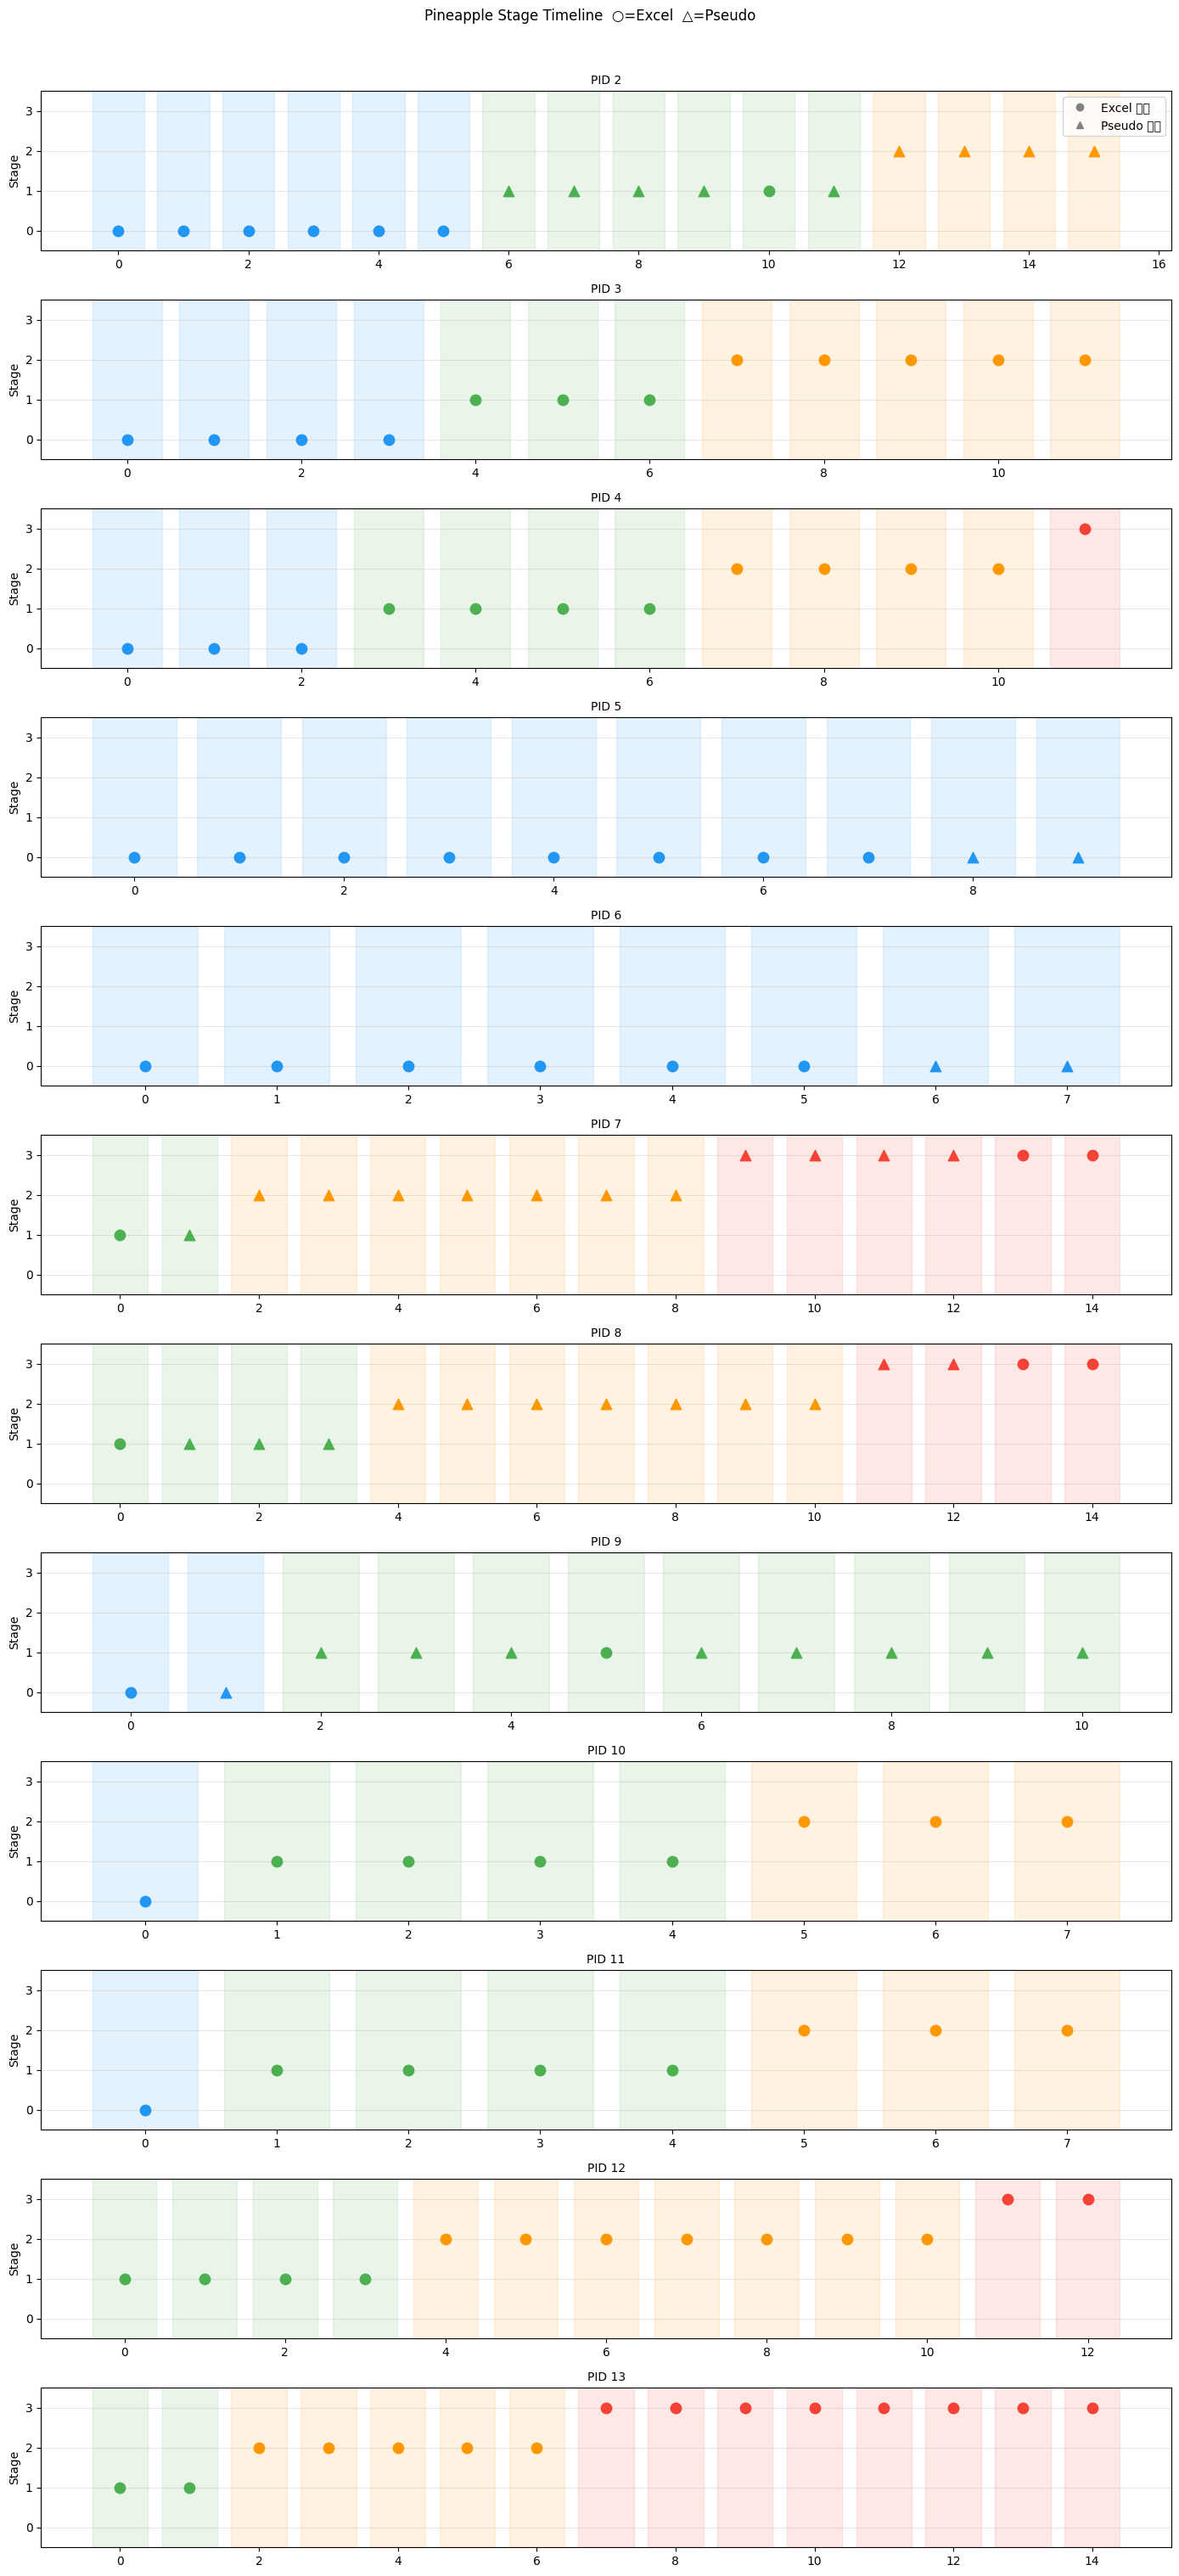

[Done] stage_timeline.png 已儲存


In [34]:
# ✅ 畫圖用的 df：所有 stage 強制單調（只影響圖，不影響 eval）
plot_df = all_df.copy().sort_values(["pid","date"]).reset_index(drop=True)
for pid, grp in plot_df.groupby("pid"):
    idx = grp.index
    plot_df.loc[idx, "stage"] = np.maximum.accumulate(
        plot_df.loc[idx, "stage"].values.astype(float))

all_pids = sorted(plot_df["pid"].unique())
fig, axes = plt.subplots(len(all_pids), 1,
                         figsize=(14, 2.5 * len(all_pids)), sharex=False)
if len(all_pids) == 1:
    axes = [axes]

colors = {0: "#2196F3", 1: "#4CAF50", 2: "#FF9800", 3: "#F44336"}

for ax, pid in zip(axes, all_pids):
    pid_data = plot_df[plot_df["pid"] == pid].sort_values("date").reset_index(drop=True)
    for i, row in pid_data.iterrows():
        s = int(row["stage"])
        c = colors.get(s, "gray")
        m = "o" if row["label_source"] == "excel" else "^"
        ax.scatter(i, s, color=c, marker=m, s=80, zorder=3)
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.12, color=c)
    ax.set_title(f"PID {pid}", fontsize=10)
    ax.set_ylabel("Stage")
    ax.set_yticks(range(N_STAGES))
    ax.set_ylim(-0.5, N_STAGES - 0.5)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(handles=[
    Line2D([0],[0], marker="o", color="gray", label="Excel 標記", linestyle="None"),
    Line2D([0],[0], marker="^", color="gray", label="Pseudo 推論", linestyle="None"),
], loc="upper right")

plt.suptitle("Pineapple Stage Timeline  ○=Excel  △=Pseudo", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("stage_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Done] stage_timeline.png 已儲存")



In [35]:
# ============================================================
# New Cell — Export deploy bundle for Raspberry Pi 3
# 放在 Cell 20.14 後面
# 目的：
#   1. 讀取 ORDINAL_V1_REVIEWED 的最佳設定
#   2. 用全部 reviewed train data 重訓最終部署模型
#   3. 匯出：
#        - 3 個 CatBoost ordinal models
#        - scaler.pkl
#        - feature_columns.json
#        - deploy_meta.json
# ============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

print("=" * 72)
print("📦 Export deploy bundle for Raspberry Pi 3")
print("=" * 72)

# ------------------------------------------------------------
# 0) 檢查前置變數
# ------------------------------------------------------------
assert "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals(), "請先跑 Cell 20.14"
assert "REVIEWED_ALL_DF" in globals(), "請先跑 reviewed data cell"
assert "feat_cols" in globals(), "請先跑前面的特徵工程 cell"
assert "POOL_CANDIDATES" in globals(), "請先跑 Cell 20.14"
assert "build_train_variant" in globals(), "請先跑 Cell 20.14"
assert "select_features_from_pool_train_only" in globals(), "請先跑 Cell 20.14"
assert "fit_ordinal_threshold_models" in globals(), "請先跑 Cell 20.14"

# ------------------------------------------------------------
# 1) 取最佳設定
# ------------------------------------------------------------
best_row = ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0].copy()

train_variant   = best_row["train_variant"]
pool_name       = best_row["pool_name"]
top_k           = int(best_row["top_k"])
model_name      = best_row["model_name"]
excel_w         = float(best_row["excel_w"])
pos_weight_base = float(best_row["pos_weight_base"])

print("最佳設定：")
print(best_row.to_dict())

# ------------------------------------------------------------
# 2) 依 model_name 找回對應 CatBoost 參數
# ------------------------------------------------------------
model_map = {m["model_name"]: m for m in MODEL_CANDIDATES}
assert model_name in model_map, f"找不到 model_name={model_name} 對應設定"

model_cfg = model_map[model_name]
model_params = model_cfg["params"].copy()
auto_class_weights = model_cfg["auto_class_weights"]

print("\n使用模型設定：")
print(model_cfg)

# ------------------------------------------------------------
# 3) 建立最終訓練資料
#    用全部 reviewed data，依最佳 train_variant 篩選
# ------------------------------------------------------------
train_df_final = build_train_variant(REVIEWED_ALL_DF.copy(), train_variant)

print("\ntrain_df_final shape =", train_df_final.shape)
print("stage 分布 =", train_df_final["stage"].value_counts().sort_index().to_dict())

# ------------------------------------------------------------
# 4) 依最佳 pool + top_k 重新選特徵
# ------------------------------------------------------------
assert pool_name in POOL_CANDIDATES, f"找不到 pool_name={pool_name}"

feat_pool = POOL_CANDIDATES[pool_name]
selected_feats, score_df = select_features_from_pool_train_only(
    train_d=train_df_final,
    feat_pool=feat_pool,
    top_k=top_k
)

assert len(selected_feats) > 0, "selected_feats 為空，無法部署"

print("\nselected_feats =", selected_feats)
print("特徵數 =", len(selected_feats))

# ------------------------------------------------------------
# 5) 建立 X / scaler
# ------------------------------------------------------------
X_final_raw = train_df_final[selected_feats].copy()
X_final = np.nan_to_num(X_final_raw.values, nan=0.0)

scaler = StandardScaler()
X_final_scaled = np.nan_to_num(
    scaler.fit_transform(X_final),
    nan=0.0
)

# ------------------------------------------------------------
# 6) 訓練 3 個 ordinal threshold CatBoost 模型
# ------------------------------------------------------------
final_models = fit_ordinal_threshold_models(
    Xtr=X_final_scaled,
    train_d=train_df_final,
    model_params=model_params,
    auto_class_weights=auto_class_weights,
    excel_w=excel_w,
    pos_weight_base=pos_weight_base
)

print("\n已完成 3 個 ordinal models 訓練：", list(final_models.keys()))

# ------------------------------------------------------------
# 7) 建立 deploy 資料夾
# ------------------------------------------------------------
DEPLOY_DIR = "./deploy_rpi_catboost"
os.makedirs(DEPLOY_DIR, exist_ok=True)

# ------------------------------------------------------------
# 8) 匯出模型
#    CatBoost 建議存原生 .cbm
# ------------------------------------------------------------
final_models[1].save_model(os.path.join(DEPLOY_DIR, "cb_ge1.cbm"))
final_models[2].save_model(os.path.join(DEPLOY_DIR, "cb_ge2.cbm"))
final_models[3].save_model(os.path.join(DEPLOY_DIR, "cb_ge3.cbm"))

# ------------------------------------------------------------
# 9) 匯出 scaler
# ------------------------------------------------------------
with open(os.path.join(DEPLOY_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

# ------------------------------------------------------------
# 10) 匯出 feature columns
# ------------------------------------------------------------
with open(os.path.join(DEPLOY_DIR, "feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(selected_feats, f, ensure_ascii=False, indent=2)

# ------------------------------------------------------------
# 11) 匯出 deploy metadata
# ------------------------------------------------------------
deploy_meta = {
    "model_type": "catboost_ordinal_threshold_v1",
    "n_stages": 4,
    "threshold_models": ["cb_ge1.cbm", "cb_ge2.cbm", "cb_ge3.cbm"],
    "feature_file": "feature_columns.json",
    "scaler_file": "scaler.pkl",
    "train_variant": train_variant,
    "pool_name": pool_name,
    "top_k": top_k,
    "model_name": model_name,
    "model_params": model_params,
    "auto_class_weights": auto_class_weights,
    "excel_w": excel_w,
    "pos_weight_base": pos_weight_base,
    "selected_features": selected_feats,
    "note": "Prediction on Raspberry Pi should follow ordinal threshold inference + optional cummax postprocess."
}

with open(os.path.join(DEPLOY_DIR, "deploy_meta.json"), "w", encoding="utf-8") as f:
    json.dump(deploy_meta, f, ensure_ascii=False, indent=2)

print("\n✅ 已匯出 Raspberry Pi 部署檔案到：", DEPLOY_DIR)
print("內容：")
for name in sorted(os.listdir(DEPLOY_DIR)):
    print(" -", name)

📦 Export deploy bundle for Raspberry Pi 3
最佳設定：
{'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12, 'model_name': 'CB_sqrt_bal', 'weight_mode': 'SqrtBalanced', 'excel_w': 1.7, 'pos_weight_base': 1.25, 'mean_acc': 0.8063736263736263, 'std_acc': 0.19338869034132478, 'per_pid_acc': [0.5714285714285714, 0.9166666666666666, 0.5833333333333334, 1.0, 1.0, 0.5, 1.0, 1.0, 0.6923076923076923, 0.8]}

使用模型設定：
{'model_name': 'CB_sqrt_bal', 'params': {'iterations': 240, 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'border_count': 64}, 'auto_class_weights': 'SqrtBalanced'}

train_df_final shape = (129, 134)
stage 分布 = {0: 20, 1: 42, 2: 47, 3: 20}

selected_feats = ['MQ9_slope', 'MQ9_delta_mean', 'MQ135_delta_max_abs', 'MQ2_slope', 'MQ2_delta_max_abs', 'MQ2_MQ135_ratio', 'MQ9_min_norm', 'TGS2602_std_norm', 'MQ2_MQ3_ratio', 'MQ2_mean_norm', 'MQ2_auc_norm', 'MQ3_MQ135_ratio', 'day_ratio', 'day_index']
特徵數 = 14

已完成 3 個 ordinal models 訓練： [1, 2, 3]

✅ 已匯出 Raspberry Pi

In [36]:
# ============================================================
# New Cell — Generate SCP command for Raspberry Pi upload
# 目的：
#   1. 幫你列出要上傳到 Raspberry Pi 的檔案
#   2. 產生可直接貼到 terminal 的 scp 指令
# ============================================================

RPI_USER = "linguanyu"
RPI_IP   = "192.168.0.152"   # 改成你的 Raspberry Pi IP
RPI_PATH = "/home/linguanyu/pineapple/"

deploy_files = [
    "cb_ge1.cbm",
    "cb_ge2.cbm",
    "cb_ge3.cbm",
    "scaler.pkl",
    "feature_columns.json",
    "deploy_meta.json",
]

print("=" * 72)
print("🚚 SCP upload command")
print("=" * 72)

for f in deploy_files:
    full_path = os.path.join("deploy_rpi_catboost", f)
    print(full_path)

scp_cmd = (
    "scp " +
    " ".join([os.path.join("deploy_rpi_catboost", f) for f in deploy_files]) +
    f" {RPI_USER}@{RPI_IP}:{RPI_PATH}"
)

print("\n請到你筆電 terminal / PowerShell 執行下面這行：\n")
print(scp_cmd)

🚚 SCP upload command
deploy_rpi_catboost\cb_ge1.cbm
deploy_rpi_catboost\cb_ge2.cbm
deploy_rpi_catboost\cb_ge3.cbm
deploy_rpi_catboost\scaler.pkl
deploy_rpi_catboost\feature_columns.json
deploy_rpi_catboost\deploy_meta.json

請到你筆電 terminal / PowerShell 執行下面這行：

scp deploy_rpi_catboost\cb_ge1.cbm deploy_rpi_catboost\cb_ge2.cbm deploy_rpi_catboost\cb_ge3.cbm deploy_rpi_catboost\scaler.pkl deploy_rpi_catboost\feature_columns.json deploy_rpi_catboost\deploy_meta.json linguanyu@192.168.0.152:/home/linguanyu/pineapple/


In [37]:
# ============================================================
# New Cell — Inference window test (5 / 10 / 15 / 30 / 60 / 120 sec)
# 建議放在 Cell 20.14 後面
# 目的：
#   1. 用目前最佳的 ORDINAL_V1_REVIEWED 設定
#   2. 將每日 raw Excel 截成前 N 秒，重建同一套特徵
#   3. 比較不同窗口長度下的 LOGO 準確率
# 注意：
#   - 這裡假設 raw Excel「1 列 ≈ 1 秒」
#   - 若你的實際取樣不是 1Hz，window_sec 請解讀成「前 N 筆」
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("=" * 72)
print("⏱️ Inference window test (5 / 10 / 15 / 30 / 60 / 120 sec)")
print("=" * 72)

# ------------------------------------------------------------
# 0) 前置檢查
# ------------------------------------------------------------
assert "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals(), "請先跑 Cell 20.14"
assert "REVIEWED_ALL_DF" in globals(), "請先跑 Cell 20.13"
assert "REVIEWED_EVAL_DF" in globals(), "請先跑 Cell 20.13"
assert "FILE_MANIFEST_DF" in globals(), "請先跑 Cell 5"
assert "read_raw_xlsx" in globals(), "請先跑 Cell 5"
assert "compute_features_one_day" in globals(), "請先跑 Cell 5"
assert "SENSORS" in globals(), "請先跑 Cell 5"
assert "RAW_COLS" in globals(), "請先跑 Cell 5"
assert "pid_fallback_baseline" in globals(), "請先跑 Cell 5"
assert "build_train_variant" in globals(), "請先跑 Cell 20.14"
assert "select_features_from_pool_train_only" in globals(), "請先跑 Cell 20.14"
assert "fit_ordinal_threshold_models" in globals(), "請先跑 Cell 20.14"
assert "predict_stage_from_ordinal_models" in globals(), "請先跑 Cell 20.14"
assert "apply_cummax" in globals(), "請先跑 Cell 20.14"
assert "MODEL_CANDIDATES" in globals(), "請先跑 Cell 20.14"
assert "POOL_CANDIDATES" in globals(), "請先跑 Cell 20.14"

WINDOW_SECONDS = [5, 10, 15, 30, 60, 120]
ROWS_PER_SECOND = 1
MIN_ROWS = 10  # compute_features_one_day 內部本來就要求至少 10 筆

print(f"時間假設：1 列 ≈ {ROWS_PER_SECOND} 秒；若非 1Hz，window_sec 代表前 N 筆。")
print(f"測試窗口：{WINDOW_SECONDS}\n")

# ------------------------------------------------------------
# 1) 讀最佳設定（直接沿用 Cell 20.14 最佳組合）
# ------------------------------------------------------------
best_row = ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0].copy()

train_variant   = best_row["train_variant"]
pool_name       = best_row["pool_name"]
top_k           = int(best_row["top_k"])
model_name      = best_row["model_name"]
excel_w         = float(best_row["excel_w"])
pos_weight_base = float(best_row["pos_weight_base"])

model_map = {m["model_name"]: m for m in MODEL_CANDIDATES}
assert model_name in model_map, f"找不到 model_name={model_name}"
model_cfg = model_map[model_name]

print("📌 使用最佳設定：")
print({
    "train_variant": train_variant,
    "pool_name": pool_name,
    "top_k": top_k,
    "model_name": model_name,
    "excel_w": excel_w,
    "pos_weight_base": pos_weight_base,
})

# ------------------------------------------------------------
# 2) helper：切前 N 筆 / 建 baseline / air contrast
# ------------------------------------------------------------
def head_n_valid(df, n_rows):
    if df is None or len(df) == 0:
        return None
    out = df.iloc[:max(int(n_rows), 1)].copy().reset_index(drop=True)
    return out

def build_baseline_from_air_or_fallback(pid, air_df_cut):
    baseline = {}
    if air_df_cut is not None and len(air_df_cut) > 0:
        for s in SENSORS:
            col = RAW_COLS[s]
            if col in air_df_cut.columns:
                val = pd.to_numeric(air_df_cut[col], errors="coerce").dropna()
                val = float(val.mean()) if len(val) > 0 else np.nan
            else:
                val = np.nan
            if pd.isna(val) or val == 0:
                val = float(pid_fallback_baseline.get(pid, {}).get(s, 1.0))
            baseline[s] = val
    else:
        baseline = {
            s: float(pid_fallback_baseline.get(pid, {}).get(s, 1.0))
            for s in SENSORS
        }
    return baseline

def compute_air_contrast_features(fruit_df_cut, air_df_cut):
    row = {}
    for s in SENSORS:
        col = RAW_COLS[s]

        row[f"{s}_air_mean_norm"] = np.nan
        row[f"{s}_air_std_norm"] = np.nan
        row[f"{s}_fruit_air_mean_gap_norm"] = np.nan
        row[f"{s}_fruit_air_auc_gap_norm"] = np.nan
        row[f"{s}_fruit_air_last_gap_norm"] = np.nan

        if fruit_df_cut is None or col not in fruit_df_cut.columns:
            continue

        x_fruit = pd.to_numeric(fruit_df_cut[col], errors="coerce").dropna().values.astype(float)
        if len(x_fruit) < MIN_ROWS:
            continue

        fruit_mean = float(np.mean(x_fruit))
        fruit_auc  = float(np.trapz(x_fruit) / max(len(x_fruit), 1))
        fruit_last = float(np.mean(x_fruit[-max(1, len(x_fruit)//10):]))

        if air_df_cut is not None and col in air_df_cut.columns:
            x_air = pd.to_numeric(air_df_cut[col], errors="coerce").dropna().values.astype(float)
            if len(x_air) >= MIN_ROWS:
                air_mean = float(np.mean(x_air))
                air_std  = float(np.std(x_air))
                air_auc  = float(np.trapz(x_air) / max(len(x_air), 1))
                air_last = float(np.mean(x_air[-max(1, len(x_air)//10):]))
            else:
                air_mean, air_std, air_auc, air_last = np.nan, np.nan, np.nan, np.nan
        else:
            air_mean, air_std, air_auc, air_last = np.nan, np.nan, np.nan, np.nan

        norm_base = air_mean if pd.notna(air_mean) and air_mean != 0 else max(abs(fruit_mean), 1.0)

        row[f"{s}_air_mean_norm"] = air_mean / norm_base if pd.notna(air_mean) else np.nan
        row[f"{s}_air_std_norm"] = air_std / norm_base if pd.notna(air_std) else np.nan
        row[f"{s}_fruit_air_mean_gap_norm"] = (fruit_mean - air_mean) / norm_base if pd.notna(air_mean) else np.nan
        row[f"{s}_fruit_air_auc_gap_norm"] = (fruit_auc - air_auc) / norm_base if pd.notna(air_auc) else np.nan
        row[f"{s}_fruit_air_last_gap_norm"] = (fruit_last - air_last) / norm_base if pd.notna(air_last) else np.nan

    return row

def add_cross_ratio_features(df):
    df = df.copy()
    base_sensors = ["MQ2", "MQ3", "MQ9", "MQ135", "TGS2602"]
    pairs = [(a, b) for i, a in enumerate(base_sensors) for b in base_sensors[i+1:]]

    for s1, s2 in pairs:
        col_a = f"{s1}_mean_norm"
        col_b = f"{s2}_mean_norm"
        new_col = f"{s1}_{s2}_ratio"
        if col_a in df.columns and col_b in df.columns:
            df[new_col] = pd.to_numeric(df[col_a], errors="coerce") / (pd.to_numeric(df[col_b], errors="coerce") + 1e-9)

    return df

# ------------------------------------------------------------
# 3) 建立某個窗口的 feature table
# ------------------------------------------------------------
def build_window_feature_table(window_sec):
    n_rows = max(int(window_sec * ROWS_PER_SECOND), 1)
    rows = []
    errors = []

    for _, r in FILE_MANIFEST_DF.iterrows():
        pid = int(r["pid"])
        date = str(r["date"])
        fruit_path = r["fruit_path"]
        air_path = r["air_path"] if pd.notna(r["air_path"]) else None
        air_source = r["air_source"]

        try:
            fruit_df = read_raw_xlsx(fruit_path)
            fruit_df_cut = head_n_valid(fruit_df, n_rows)

            try:
                air_df = read_raw_xlsx(air_path) if air_path is not None else None
            except Exception:
                air_df = None
            air_df_cut = head_n_valid(air_df, n_rows) if air_df is not None else None

            baseline = build_baseline_from_air_or_fallback(pid, air_df_cut)
            feat = compute_features_one_day(fruit_df_cut, baseline)
            feat.update(compute_air_contrast_features(fruit_df_cut, air_df_cut))

            feat["pid"] = pid
            feat["date"] = date
            feat["has_air"] = int(air_path is not None)
            feat["air_source"] = air_source
            feat["window_sec"] = int(window_sec)
            feat["window_rows"] = int(min(len(fruit_df_cut), n_rows)) if fruit_df_cut is not None else 0
            rows.append(feat)

        except Exception as e:
            errors.append({
                "pid": pid,
                "date": date,
                "window_sec": int(window_sec),
                "error": str(e),
            })

    df = pd.DataFrame(rows).sort_values(["pid", "date"]).reset_index(drop=True)
    df = add_cross_ratio_features(df)

    # 補 day_index / day_ratio（要跟主流程一致）
    df["day_index"] = df.groupby("pid").cumcount()
    df["day_total"] = df.groupby("pid")["day_index"].transform("max")
    df["day_ratio"] = df["day_index"] / df["day_total"].replace(0, 1)

    # 缺值補法跟主流程保持保守一致：numeric 用中位數，再補 0
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            med = df[c].median()
            if pd.isna(med):
                med = 0.0
            df[c] = df[c].fillna(med).fillna(0.0)

    err_df = pd.DataFrame(errors)
    return df, err_df

# ------------------------------------------------------------
# 4) 逐窗口重建 + 用最佳設定做 LOGO
# ------------------------------------------------------------
results = []
per_pid_tables = {}
window_feature_tables = {}
window_error_tables = {}

full_day_ref = float(ORDINAL_V1_REVIEWED_MEAN_ACC * 100) if "ORDINAL_V1_REVIEWED_MEAN_ACC" in globals() else np.nan

label_train_cols = [c for c in ["pid", "date", "stage", "label_source", "label_confidence"] if c in REVIEWED_ALL_DF.columns]
label_eval_cols  = [c for c in ["pid", "date", "stage"] if c in REVIEWED_EVAL_DF.columns]

train_label_map = REVIEWED_ALL_DF[label_train_cols].drop_duplicates(["pid", "date"]).copy()
eval_label_map  = REVIEWED_EVAL_DF[label_eval_cols].drop_duplicates(["pid", "date"]).copy()

for window_sec in WINDOW_SECONDS:
    print("\n" + "-" * 72)
    print(f"⏱ 窗口 = {window_sec} 秒")
    print("-" * 72)

    feat_df, err_df = build_window_feature_table(window_sec)
    window_feature_tables[window_sec] = feat_df.copy()
    window_error_tables[window_sec] = err_df.copy()

    if len(feat_df) == 0:
        print("❌ 該窗口沒有成功建出任何特徵")
        results.append({
            "window_sec": window_sec,
            "n_samples": 0,
            "n_valid_pids": 0,
            "mean_acc": np.nan,
            "std_acc": np.nan,
            "min_acc": np.nan,
            "max_acc": np.nan,
            "vs_full_day": np.nan,
        })
        continue

    window_all_df = feat_df.merge(train_label_map, on=["pid", "date"], how="left")
    window_all_df = window_all_df[window_all_df["stage"].notna()].copy()
    window_all_df["stage"] = window_all_df["stage"].astype(int)

    window_eval_df = feat_df.merge(eval_label_map, on=["pid", "date"], how="inner")
    window_eval_df["stage"] = window_eval_df["stage"].astype(int)

    valid_pids = [
        pid for pid in sorted(window_eval_df["pid"].unique())
        if window_eval_df.loc[window_eval_df["pid"] == pid, "stage"].nunique() >= 2
    ]

    feat_pool = [f for f in POOL_CANDIDATES[pool_name] if f in window_all_df.columns]

    print(f"樣本數: {len(window_all_df)} | eval樣本: {len(window_eval_df)} | valid_pids: {valid_pids}")
    print(f"可用 pool 特徵數: {len(feat_pool)}")
    if len(err_df) > 0:
        print(f"讀檔/建特徵錯誤數: {len(err_df)}")

    pid_accs = []
    pid_rows = []
    pred_tables = []

    for test_pid in valid_pids:
        train_variant_df = build_train_variant(window_all_df, train_variant)
        train_d = train_variant_df[train_variant_df["pid"] != test_pid].copy()
        test_d  = window_eval_df[window_eval_df["pid"] == test_pid].copy()

        if len(train_d) < 20 or train_d["stage"].nunique() < 2:
            continue
        if len(test_d) == 0 or test_d["stage"].nunique() < 2:
            continue

        selected_feats, _ = select_features_from_pool_train_only(
            train_d=train_d,
            feat_pool=feat_pool,
            top_k=top_k,
        )
        selected_feats = [f for f in selected_feats if f in train_d.columns and f in test_d.columns]

        if len(selected_feats) == 0:
            continue

        Xtr_raw = train_d[selected_feats].copy()
        Xte_raw = test_d[selected_feats].copy()

        scaler = StandardScaler()
        Xtr = np.nan_to_num(scaler.fit_transform(np.nan_to_num(Xtr_raw.values, nan=0.0)), nan=0.0)
        Xte = np.nan_to_num(scaler.transform(np.nan_to_num(Xte_raw.values, nan=0.0)), nan=0.0)
        yte = test_d["stage"].astype(int).values

        models = fit_ordinal_threshold_models(
            Xtr=Xtr,
            train_d=train_d,
            model_params=model_cfg["params"],
            auto_class_weights=model_cfg["auto_class_weights"],
            excel_w=excel_w,
            pos_weight_base=pos_weight_base,
        )

        pred, proba = predict_stage_from_ordinal_models(models, Xte)
        pred = apply_cummax(pred, test_d["date"].values)

        acc = accuracy_score(yte, pred)
        pid_accs.append(acc)
        pid_rows.append({
            "window_sec": int(window_sec),
            "pid": int(test_pid),
            "acc": float(acc),
            "n_test": int(len(test_d)),
        })

        tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
        tmp["pred"] = pred
        tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
        tmp["window_sec"] = int(window_sec)
        pred_tables.append(tmp)

    if len(pid_accs) == 0:
        print("❌ 沒有有效的 LOGO 結果")
        results.append({
            "window_sec": int(window_sec),
            "n_samples": int(len(window_all_df)),
            "n_valid_pids": int(len(valid_pids)),
            "mean_acc": np.nan,
            "std_acc": np.nan,
            "min_acc": np.nan,
            "max_acc": np.nan,
            "vs_full_day": np.nan,
        })
        continue

    mean_acc = float(np.mean(pid_accs) * 100)
    std_acc  = float(np.std(pid_accs) * 100)
    min_acc  = float(np.min(pid_accs) * 100)
    max_acc  = float(np.max(pid_accs) * 100)
    vs_full  = mean_acc - full_day_ref if pd.notna(full_day_ref) else np.nan

    print(f"📊 {mean_acc:.2f}% ± {std_acc:.2f}% | range {min_acc:.2f}~{max_acc:.2f}% | vs full-day {vs_full:+.2f}%")

    pid_df = pd.DataFrame(pid_rows).sort_values(["acc", "pid"]).reset_index(drop=True)
    pred_df = pd.concat(pred_tables, ignore_index=True) if len(pred_tables) > 0 else pd.DataFrame()

    if len(pid_df) > 0:
        print("Worst 3:")
        print(pid_df.head(3).to_string(index=False))

    per_pid_tables[window_sec] = pid_df

    results.append({
        "window_sec": int(window_sec),
        "n_samples": int(len(window_all_df)),
        "n_valid_pids": int(len(valid_pids)),
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "min_acc": min_acc,
        "max_acc": max_acc,
        "vs_full_day": vs_full,
    })

    globals()[f"WINDOW_{window_sec}S_PRED_DF"] = pred_df
    globals()[f"WINDOW_{window_sec}S_PID_DF"] = pid_df
    globals()[f"WINDOW_{window_sec}S_FEATURE_DF"] = feat_df
    globals()[f"WINDOW_{window_sec}S_ERROR_DF"] = err_df

# ------------------------------------------------------------
# 5) 統整結果
# ------------------------------------------------------------
WINDOW_TEST_RESULT_DF = pd.DataFrame(results).sort_values("window_sec").reset_index(drop=True)
WINDOW_TEST_PER_PID_TABLES = per_pid_tables
WINDOW_TEST_FEATURE_TABLES = window_feature_tables
WINDOW_TEST_ERROR_TABLES = window_error_tables

print("\n" + "=" * 72)
print("📘 Window test summary")
print("=" * 72)
if pd.notna(full_day_ref):
    print(f"Full-day reference (Cell 20.14): {full_day_ref:.2f}%\n")
print(WINDOW_TEST_RESULT_DF.to_string(index=False))

os.makedirs("data/processed", exist_ok=True)
out_csv = "data/processed/window_test_reviewed_ordinal_best.csv"
WINDOW_TEST_RESULT_DF.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: {out_csv}")

if len(WINDOW_TEST_RESULT_DF.dropna(subset=["mean_acc"])) > 0:
    best_window = WINDOW_TEST_RESULT_DF.dropna(subset=["mean_acc"]).sort_values(
        ["mean_acc", "window_sec"],
        ascending=[False, True]
    ).iloc[0]
    print("\n🏆 最佳窗口：")
    print(
        f"{int(best_window['window_sec'])} 秒 | "
        f"acc={best_window['mean_acc']:.2f}% ± {best_window['std_acc']:.2f}%"
    )

print("\n✅ 已保存變數：")
print("   WINDOW_TEST_RESULT_DF")
print("   WINDOW_TEST_PER_PID_TABLES")
print("   WINDOW_TEST_FEATURE_TABLES")
print("   WINDOW_TEST_ERROR_TABLES")
print("   WINDOW_5S_PRED_DF / WINDOW_10S_PRED_DF / ...")

⏱️ Inference window test (5 / 10 / 15 / 30 / 60 / 120 sec)
時間假設：1 列 ≈ 1 秒；若非 1Hz，window_sec 代表前 N 筆。
測試窗口：[5, 10, 15, 30, 60, 120]

📌 使用最佳設定：
{'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12, 'model_name': 'CB_sqrt_bal', 'excel_w': 1.7, 'pos_weight_base': 1.25}

------------------------------------------------------------------------
⏱ 窗口 = 5 秒
------------------------------------------------------------------------
樣本數: 143 | eval樣本: 97 | valid_pids: [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
可用 pool 特徵數: 14
📊 57.65% ± 17.85% | range 28.57~84.62% | vs full-day -22.99%
Worst 3:
 window_sec  pid      acc  n_test
          5    2 0.285714       7
          5   10 0.375000       8
          5   11 0.375000       8

------------------------------------------------------------------------
⏱ 窗口 = 10 秒
----------------------------------------------------------------------

In [38]:
# ============================================================
# New Cell — DEPLOY_STUDENT_V1 (Pi3 deploy candidate search)
# 放在 Cell 20.14 後面
# 目的：
#   1. 保留目前最佳 CatBoost teacher，不動研究結果
#   2. 用 teacher 的最佳設定，建立 Pi3 可部署學生模型
#   3. 比較：
#        - RandomForest / ExtraTrees
#        - 真實 label / teacher-guided
#        - 原始最佳特徵 / CatBoost-ranked top features
#   4. 用與 teacher 相同的 LOGO 評估方式做公平比較
#   5. 匯出最好的 deploy student model 給 Raspberry Pi 3
# ============================================================

import os
import io
import json
import time
import pickle
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print("=" * 72)
print("🚀 DEPLOY_STUDENT_V1 — Pi3 deploy candidate search")
print("=" * 72)

# ------------------------------------------------------------
# 0) 前置檢查
# ------------------------------------------------------------
assert "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals(), "請先跑 Cell 20.14"
assert "REVIEWED_ALL_DF" in globals(), "請先跑 Cell 20.13"
assert "REVIEWED_EVAL_DF" in globals(), "請先跑 Cell 20.13"

# 下面這些 helper / 變數都是 Cell 20.14 已經定義好的
required_names = [
    "build_train_variant",
    "get_test_df_by_pid",
    "select_features_from_pool_train_only",
    "fit_ordinal_threshold_models",
    "predict_stage_from_ordinal_models",
    "apply_cummax",
    "POOL_CANDIDATES",
    "MODEL_CANDIDATES",
]
for name in required_names:
    assert name in globals(), f"缺少 {name}，請先完整跑 Cell 20.14"

# ------------------------------------------------------------
# 1) 讀取 teacher 最佳設定
#    這裡直接用 Cell 20.14 搜到的第一名設定
# ------------------------------------------------------------
best_teacher_row = ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0].copy()

teacher_train_variant   = best_teacher_row["train_variant"]
teacher_pool_name       = best_teacher_row["pool_name"]
teacher_top_k           = int(best_teacher_row["top_k"])
teacher_model_name      = best_teacher_row["model_name"]
teacher_excel_w         = float(best_teacher_row["excel_w"])
teacher_pos_weight_base = float(best_teacher_row["pos_weight_base"])

print("📌 Teacher best config")
print(best_teacher_row.to_dict())

# 找回 teacher 對應的 CatBoost 參數
teacher_model_cfg = None
for cfg in MODEL_CANDIDATES:
    if cfg["model_name"] == teacher_model_name:
        teacher_model_cfg = cfg.copy()
        break

assert teacher_model_cfg is not None, f"找不到 teacher_model_name={teacher_model_name}"

teacher_model_params = teacher_model_cfg["params"].copy()
teacher_auto_class_weights = teacher_model_cfg["auto_class_weights"]

# ------------------------------------------------------------
# 2) 建立這次 deploy 評估的 train / eval 資料
# ------------------------------------------------------------
train_df_full = REVIEWED_ALL_DF.copy()
eval_df_full  = REVIEWED_EVAL_DF.copy()

valid_pids = [
    pid for pid in sorted(eval_df_full["pid"].unique())
    if eval_df_full.loc[eval_df_full["pid"] == pid, "stage"].nunique() >= 2
]

print("\nvalid_pids =", valid_pids)

# ------------------------------------------------------------
# 3) 小 helper：建立學生模型
#    這裡特別控制模型大小，不要做得太肥，才適合 Pi3
# ------------------------------------------------------------
def build_student_model(model_name):
    # RandomForest：穩定、好裝、Pi3 很友善
    if model_name == "RF":
        return RandomForestClassifier(
            n_estimators=220,
            max_depth=7,
            min_samples_leaf=2,
            min_samples_split=4,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        )

    # ExtraTrees：通常比 RF 更快，有時效果很接近 CatBoost
    elif model_name == "ET":
        return ExtraTreesClassifier(
            n_estimators=260,
            max_depth=7,
            min_samples_leaf=2,
            min_samples_split=4,
            max_features="sqrt",
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )

    else:
        raise ValueError(f"未知 student model_name={model_name}")

# ------------------------------------------------------------
# 4) 小 helper：用 teacher 在 train fold 上做 feature ranking
#    目的：
#      1. 不直接拿全部特徵給 deploy model
#      2. 先用 CatBoost importance 排出更乾淨的部署特徵
# ------------------------------------------------------------
def get_teacher_ranked_feature_subset(train_d, selected_feats, rank_top_non_time=8):
    selected_feats = [f for f in selected_feats if f in train_d.columns]
    if len(selected_feats) == 0:
        return []

    # 時間特徵固定保留到最後再 append
    time_feats = [f for f in ["day_ratio", "day_index"] if f in selected_feats]
    non_time_feats = [f for f in selected_feats if f not in time_feats]

    if len(non_time_feats) == 0:
        return time_feats.copy()

    # teacher 仍沿用 Cell 20.14 的 ordinal CatBoost 設計
    X_raw = train_d[selected_feats].copy()
    X = np.nan_to_num(X_raw.values, nan=0.0)

    scaler = StandardScaler()
    Xs = np.nan_to_num(scaler.fit_transform(X), nan=0.0)

    teacher_models = fit_ordinal_threshold_models(
        Xtr=Xs,
        train_d=train_d,
        model_params=teacher_model_params,
        auto_class_weights=teacher_auto_class_weights,
        excel_w=teacher_excel_w,
        pos_weight_base=teacher_pos_weight_base
    )

    # 3 個 threshold model 的 feature importance 做平均
    imp_mat = []
    for k in [1, 2, 3]:
        clf = teacher_models[k]
        try:
            imp = np.array(clf.get_feature_importance(), dtype=float)
        except Exception:
            imp = np.zeros(len(selected_feats), dtype=float)
        imp_mat.append(imp)

    imp_mean = np.mean(np.vstack(imp_mat), axis=0)

    imp_df = pd.DataFrame({
        "feature": selected_feats,
        "importance": imp_mean
    })

    imp_df = imp_df[~imp_df["feature"].isin(["day_ratio", "day_index"])].copy()
    imp_df = imp_df.sort_values(
        ["importance", "feature"],
        ascending=[False, True]
    ).reset_index(drop=True)

    rank_top_non_time = min(rank_top_non_time, len(imp_df))
    ranked_feats = imp_df["feature"].head(rank_top_non_time).tolist()

    for tf in time_feats:
        if tf not in ranked_feats:
            ranked_feats.append(tf)

    return ranked_feats

# ------------------------------------------------------------
# 5) 小 helper：建立 teacher-guided label
#    核心想法：
#      - Excel 真標籤：保留原始真實 stage
#      - 非 excel 補標：改用 teacher 預測當作較乾淨的學生學習目標
# ------------------------------------------------------------
def build_student_target(train_d, teacher_pred_train, label_mode):
    y_true = train_d["stage"].astype(int).values.copy()

    if label_mode == "true":
        return y_true

    elif label_mode == "teacher_guided":
        y_mix = y_true.copy()

        if "label_source" in train_d.columns:
            non_excel_mask = (train_d["label_source"].astype(str).values != "excel")
            y_mix[non_excel_mask] = teacher_pred_train[non_excel_mask]
        else:
            # 如果沒有 label_source，就全部維持真標籤
            pass

        return y_mix.astype(int)

    else:
        raise ValueError(f"未知 label_mode={label_mode}")

# ------------------------------------------------------------
# 6) 候選 deploy 設定
#    這裡先控制在 6 組，不要太爆量
# ------------------------------------------------------------
DEPLOY_CANDIDATES = [
    {"student_model": "RF", "feature_mode": "selected",     "label_mode": "true"},
    {"student_model": "ET", "feature_mode": "selected",     "label_mode": "true"},
    {"student_model": "RF", "feature_mode": "cb_rank_top8", "label_mode": "true"},
    {"student_model": "ET", "feature_mode": "cb_rank_top8", "label_mode": "true"},
    {"student_model": "RF", "feature_mode": "cb_rank_top8", "label_mode": "teacher_guided"},
    {"student_model": "ET", "feature_mode": "cb_rank_top8", "label_mode": "teacher_guided"},
]

search_rows = []
best_obj = None
best_mean_acc = -1.0

# ------------------------------------------------------------
# 7) LOGO 評估
#    評估邏輯盡量沿用 teacher：
#      - train variant 不變
#      - train-only feature selection
#      - outer test 只看 excel 真標籤
#      - 預測後仍做 cummax，貼近裝置實際使用情境
# ------------------------------------------------------------
for cand in DEPLOY_CANDIDATES:
    pid_accs = []
    pid_f1s  = []
    y_true_all = []
    y_pred_all = []
    pred_tables = []
    feature_log = {}
    pred_time_ms_per_sample = []

    print("\n" + "-" * 72)
    print(
        f"student={cand['student_model']:<2s} "
        f"feature_mode={cand['feature_mode']:<12s} "
        f"label_mode={cand['label_mode']}"
    )
    print("-" * 72)

    for test_pid in valid_pids:
        # --------------------------
        # 切出 outer train / test
        # --------------------------
        train_d = train_df_full[train_df_full["pid"] != test_pid].copy()
        train_d = build_train_variant(train_d, teacher_train_variant)

        test_d = get_test_df_by_pid(test_pid).copy()

        if len(train_d) == 0 or len(test_d) == 0:
            continue

        if train_d["stage"].nunique() < 2:
            continue

        # --------------------------
        # train-only 選特徵
        # --------------------------
        feat_pool = POOL_CANDIDATES[teacher_pool_name]
        selected_feats, score_df = select_features_from_pool_train_only(
            train_d=train_d,
            feat_pool=feat_pool,
            top_k=teacher_top_k
        )

        if len(selected_feats) == 0:
            continue

        # --------------------------
        # teacher 在 train fold 上重訓
        # 用來：
        #   1. 做 teacher-guided label
        #   2. 做 CatBoost feature ranking
        # --------------------------
        Xtr_teacher_raw = train_d[selected_feats].copy()
        Xtr_teacher = np.nan_to_num(Xtr_teacher_raw.values, nan=0.0)

        scaler_teacher = StandardScaler()
        Xtr_teacher_s = np.nan_to_num(
            scaler_teacher.fit_transform(Xtr_teacher),
            nan=0.0
        )

        teacher_models = fit_ordinal_threshold_models(
            Xtr=Xtr_teacher_s,
            train_d=train_d,
            model_params=teacher_model_params,
            auto_class_weights=teacher_auto_class_weights,
            excel_w=teacher_excel_w,
            pos_weight_base=teacher_pos_weight_base
        )

        teacher_pred_train, teacher_proba_train = predict_stage_from_ordinal_models(
            teacher_models,
            Xtr_teacher_s
        )
        teacher_pred_train = apply_cummax(
            teacher_pred_train,
            train_d["date"].values
        )

        # --------------------------
        # 決定 deploy feature subset
        # --------------------------
        if cand["feature_mode"] == "selected":
            deploy_feats = selected_feats.copy()

        elif cand["feature_mode"] == "cb_rank_top8":
            deploy_feats = get_teacher_ranked_feature_subset(
                train_d=train_d,
                selected_feats=selected_feats,
                rank_top_non_time=8
            )

            if len(deploy_feats) == 0:
                deploy_feats = selected_feats.copy()

        else:
            raise ValueError(f"未知 feature_mode={cand['feature_mode']}")

        # 防呆：test 端必須也有這些欄位
        deploy_feats = [f for f in deploy_feats if f in train_d.columns and f in test_d.columns]
        if len(deploy_feats) == 0:
            continue

        # --------------------------
        # 建立學生模型的訓練目標
        # --------------------------
        ytr_student = build_student_target(
            train_d=train_d,
            teacher_pred_train=teacher_pred_train,
            label_mode=cand["label_mode"]
        )

        # --------------------------
        # 學生模型訓練
        # --------------------------
        Xtr_student = np.nan_to_num(train_d[deploy_feats].values, nan=0.0)
        Xte_student = np.nan_to_num(test_d[deploy_feats].values, nan=0.0)
        yte = test_d["stage"].astype(int).values

        student_clf = build_student_model(cand["student_model"])
        student_clf.fit(Xtr_student, ytr_student)

        # --------------------------
        # 推論 + 計時
        # --------------------------
        t0 = time.perf_counter()
        pred = student_clf.predict(Xte_student).astype(int)
        t1 = time.perf_counter()

        pred = apply_cummax(pred, test_d["date"].values)

        dt_ms = (t1 - t0) * 1000.0 / max(len(Xte_student), 1)
        pred_time_ms_per_sample.append(dt_ms)

        # --------------------------
        # 評估
        # --------------------------
        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")

        pid_accs.append(acc)
        pid_f1s.append(f1m)

        y_true_all.extend(yte.tolist())
        y_pred_all.extend(pred.tolist())

        tmp = test_d[["pid", "date", "stage"]].copy().reset_index(drop=True)
        tmp["pred"] = pred
        tmp["correct"] = (tmp["stage"].values == tmp["pred"].values).astype(int)
        tmp["student_model"] = cand["student_model"]
        tmp["feature_mode"] = cand["feature_mode"]
        tmp["label_mode"] = cand["label_mode"]
        pred_tables.append(tmp)

        feature_log[test_pid] = deploy_feats

    # fold 全部跑完後彙整
    if len(pid_accs) == 0:
        continue

    mean_acc = float(np.mean(pid_accs))
    std_acc  = float(np.std(pid_accs))
    mean_f1  = float(np.mean(pid_f1s))
    mean_pred_ms = float(np.mean(pred_time_ms_per_sample)) if len(pred_time_ms_per_sample) > 0 else np.nan

    row = {
        "student_model": cand["student_model"],
        "feature_mode": cand["feature_mode"],
        "label_mode": cand["label_mode"],
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "mean_macro_f1": mean_f1,
        "mean_pred_ms_per_sample": mean_pred_ms,
        "per_pid_acc": pid_accs,
        "per_pid_macro_f1": pid_f1s,
    }
    search_rows.append(row)

    print(
        f"acc={mean_acc:.4f} ± {std_acc:.4f} | "
        f"macro_f1={mean_f1:.4f} | "
        f"pred_ms/sample={mean_pred_ms:.3f}"
    )

    # 以 mean_acc 為主，macro_f1 為輔，挑出最好 deploy candidate
    score_key = (mean_acc, mean_f1, -std_acc)
    best_score_key = (-1, -1, -999)

    if best_obj is not None:
        best_score_key = (
            best_obj["row"]["mean_acc"],
            best_obj["row"]["mean_macro_f1"],
            -best_obj["row"]["std_acc"]
        )

    if score_key > best_score_key:
        best_obj = {
            "row": row,
            "y_true_all": y_true_all,
            "y_pred_all": y_pred_all,
            "pred_df": pd.concat(pred_tables, ignore_index=True),
            "feature_log": feature_log
        }

# ------------------------------------------------------------
# 8) 彙整 deploy 搜尋結果
# ------------------------------------------------------------
if len(search_rows) == 0:
    raise RuntimeError("DEPLOY_STUDENT_V1 沒有找到任何可用結果。")

DEPLOY_STUDENT_V1_SEARCH_DF = pd.DataFrame(search_rows).sort_values(
    ["mean_acc", "mean_macro_f1", "std_acc"],
    ascending=[False, False, True]
).reset_index(drop=True)

DEPLOY_STUDENT_V1_MEAN_ACC = best_obj["row"]["mean_acc"]
DEPLOY_STUDENT_V1_STD_ACC  = best_obj["row"]["std_acc"]
DEPLOY_STUDENT_V1_MEAN_F1  = best_obj["row"]["mean_macro_f1"]
DEPLOY_STUDENT_V1_PRED_DF  = best_obj["pred_df"].copy()
DEPLOY_STUDENT_V1_CM       = confusion_matrix(best_obj["y_true_all"], best_obj["y_pred_all"])
DEPLOY_STUDENT_V1_FEATURE_LOG = best_obj["feature_log"]

print("\n" + "=" * 72)
print("🏆 DEPLOY_STUDENT_V1 Result")
print("=" * 72)
print(DEPLOY_STUDENT_V1_SEARCH_DF.to_string(index=False))

print("-" * 72)
print(f"DEPLOY_STUDENT_V1 mean acc   = {DEPLOY_STUDENT_V1_MEAN_ACC:.4f}")
print(f"DEPLOY_STUDENT_V1 std acc    = {DEPLOY_STUDENT_V1_STD_ACC:.4f}")
print(f"DEPLOY_STUDENT_V1 macro f1   = {DEPLOY_STUDENT_V1_MEAN_F1:.4f}")
print(f"DEPLOY_STUDENT_V1 sample acc = {DEPLOY_STUDENT_V1_PRED_DF['correct'].mean():.4f}")

print("\n📘 DEPLOY_STUDENT_V1 Classification Report")
print("-" * 72)
print(classification_report(best_obj["y_true_all"], best_obj["y_pred_all"], digits=4))

print("📘 DEPLOY_STUDENT_V1 Confusion Matrix")
print("-" * 72)
print(DEPLOY_STUDENT_V1_CM)

# ------------------------------------------------------------
# 9) 用全部 reviewed train data 重訓最終 deploy student
#    這個模型才是之後要丟去 Raspberry Pi 3 的
# ------------------------------------------------------------
best_deploy_row = DEPLOY_STUDENT_V1_SEARCH_DF.iloc[0].copy()

best_student_model = best_deploy_row["student_model"]
best_feature_mode  = best_deploy_row["feature_mode"]
best_label_mode    = best_deploy_row["label_mode"]

print("\n" + "=" * 72)
print("📦 Refit final deploy student on full reviewed training data")
print("=" * 72)
print(best_deploy_row.to_dict())

train_df_final = build_train_variant(REVIEWED_ALL_DF.copy(), teacher_train_variant)

# 先用 teacher 主線選出原始最佳特徵
feat_pool_final = POOL_CANDIDATES[teacher_pool_name]
selected_feats_final, score_df_final = select_features_from_pool_train_only(
    train_d=train_df_final,
    feat_pool=feat_pool_final,
    top_k=teacher_top_k
)

assert len(selected_feats_final) > 0, "selected_feats_final 為空，無法匯出 deploy model"

# 用 teacher 在 full train 上做 ranking / teacher-guided
X_final_teacher_raw = train_df_final[selected_feats_final].copy()
X_final_teacher = np.nan_to_num(X_final_teacher_raw.values, nan=0.0)

scaler_teacher_final = StandardScaler()
X_final_teacher_s = np.nan_to_num(
    scaler_teacher_final.fit_transform(X_final_teacher),
    nan=0.0
)

teacher_models_final = fit_ordinal_threshold_models(
    Xtr=X_final_teacher_s,
    train_d=train_df_final,
    model_params=teacher_model_params,
    auto_class_weights=teacher_auto_class_weights,
    excel_w=teacher_excel_w,
    pos_weight_base=teacher_pos_weight_base
)

teacher_pred_final, teacher_proba_final = predict_stage_from_ordinal_models(
    teacher_models_final,
    X_final_teacher_s
)
teacher_pred_final = apply_cummax(
    teacher_pred_final,
    train_df_final["date"].values
)

# 決定最終 deploy feature set
if best_feature_mode == "selected":
    deploy_feats_final = selected_feats_final.copy()

elif best_feature_mode == "cb_rank_top8":
    deploy_feats_final = get_teacher_ranked_feature_subset(
        train_d=train_df_final,
        selected_feats=selected_feats_final,
        rank_top_non_time=8
    )
    if len(deploy_feats_final) == 0:
        deploy_feats_final = selected_feats_final.copy()

else:
    raise ValueError(f"未知 best_feature_mode={best_feature_mode}")

deploy_feats_final = [f for f in deploy_feats_final if f in train_df_final.columns]
assert len(deploy_feats_final) > 0, "deploy_feats_final 為空，無法匯出 deploy model"

# 建立最終學生模型訓練目標
y_final_student = build_student_target(
    train_d=train_df_final,
    teacher_pred_train=teacher_pred_final,
    label_mode=best_label_mode
)

# 訓練最終 deploy student
X_final_student = np.nan_to_num(train_df_final[deploy_feats_final].values, nan=0.0)

deploy_student_clf = build_student_model(best_student_model)
deploy_student_clf.fit(X_final_student, y_final_student)

# ------------------------------------------------------------
# 10) 匯出 Raspberry Pi 3 部署檔案
# ------------------------------------------------------------
DEPLOY_DIR = "./deploy_rpi_student"
os.makedirs(DEPLOY_DIR, exist_ok=True)

# 存模型
with open(os.path.join(DEPLOY_DIR, "deploy_student.pkl"), "wb") as f:
    pickle.dump(deploy_student_clf, f)

# 存特徵欄位
with open(os.path.join(DEPLOY_DIR, "feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(deploy_feats_final, f, ensure_ascii=False, indent=2)

# 存 metadata
deploy_meta = {
    "model_type": "student_tree_model_for_rpi3",
    "teacher_model_type": "catboost_ordinal_threshold_v1_reviewed",
    "teacher_best_config": {
        "train_variant": teacher_train_variant,
        "pool_name": teacher_pool_name,
        "top_k": int(teacher_top_k),
        "model_name": teacher_model_name,
        "excel_w": float(teacher_excel_w),
        "pos_weight_base": float(teacher_pos_weight_base),
    },
    "student_best_config": {
        "student_model": best_student_model,
        "feature_mode": best_feature_mode,
        "label_mode": best_label_mode,
    },
    "selected_features_before_teacher_rank": selected_feats_final,
    "deploy_features_final": deploy_feats_final,
    "n_features_final": int(len(deploy_feats_final)),
    "logo_mean_acc": float(DEPLOY_STUDENT_V1_MEAN_ACC),
    "logo_std_acc": float(DEPLOY_STUDENT_V1_STD_ACC),
    "logo_mean_macro_f1": float(DEPLOY_STUDENT_V1_MEAN_F1),
    "note": "For Raspberry Pi 3 deployment. Prediction should still apply date-order cummax / smoothing in inference.py."
}

with open(os.path.join(DEPLOY_DIR, "deploy_meta.json"), "w", encoding="utf-8") as f:
    json.dump(deploy_meta, f, ensure_ascii=False, indent=2)

# 模型大小（方便你之後比較 Pi3 負擔）
buf = io.BytesIO()
pickle.dump(deploy_student_clf, buf)
model_size_kb = len(buf.getvalue()) / 1024.0

print("\n✅ 已匯出 deploy bundle 到：", DEPLOY_DIR)
print("內容：")
for name in sorted(os.listdir(DEPLOY_DIR)):
    print(" -", name)

print(f"\n📦 deploy_student.pkl size = {model_size_kb:.2f} KB")
print(f"📌 final deploy features = {len(deploy_feats_final)}")
print("   ", deploy_feats_final)

# ------------------------------------------------------------
# 11) 保存 notebook 變數，給後面摘要 / 匯出 / Pi3 inference 用
# ------------------------------------------------------------
DEPLOY_STUDENT_V1_BEST_ROW = best_deploy_row.copy()
DEPLOY_STUDENT_V1_FINAL_MODEL = deploy_student_clf
DEPLOY_STUDENT_V1_FINAL_FEATURES = deploy_feats_final.copy()
DEPLOY_STUDENT_V1_FINAL_TRAIN_DF = train_df_final.copy()

print("\n✅ 已保存變數：")
print("   DEPLOY_STUDENT_V1_SEARCH_DF")
print("   DEPLOY_STUDENT_V1_MEAN_ACC")
print("   DEPLOY_STUDENT_V1_STD_ACC")
print("   DEPLOY_STUDENT_V1_MEAN_F1")
print("   DEPLOY_STUDENT_V1_PRED_DF")
print("   DEPLOY_STUDENT_V1_CM")
print("   DEPLOY_STUDENT_V1_FEATURE_LOG")
print("   DEPLOY_STUDENT_V1_BEST_ROW")
print("   DEPLOY_STUDENT_V1_FINAL_MODEL")
print("   DEPLOY_STUDENT_V1_FINAL_FEATURES")
print("   DEPLOY_STUDENT_V1_FINAL_TRAIN_DF")

🚀 DEPLOY_STUDENT_V1 — Pi3 deploy candidate search
📌 Teacher best config
{'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12, 'model_name': 'CB_sqrt_bal', 'weight_mode': 'SqrtBalanced', 'excel_w': 1.7, 'pos_weight_base': 1.25, 'mean_acc': 0.8063736263736263, 'std_acc': 0.19338869034132478, 'per_pid_acc': [0.5714285714285714, 0.9166666666666666, 0.5833333333333334, 1.0, 1.0, 0.5, 1.0, 1.0, 0.6923076923076923, 0.8]}

valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

------------------------------------------------------------------------
student=RF feature_mode=selected     label_mode=true
------------------------------------------------------------------------
acc=0.7886 ± 0.1784 | macro_f1=0.6910 | pred_ms/sample=8.486

------------------------------------------------------------------------
student=ET feature_mode=selected     label_mode=true
------------------

In [39]:
# ============================================================
# ET_WINDOW_TEST_V2
# ExtraTrees window test (5 / 10 / 15 / 30 / 60 / 120 sec)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier

print("="*72)
print("🌲 ET WINDOW TEST")
print("="*72)

# ------------------------------------------------------------
# 0) 前置檢查
# ------------------------------------------------------------
assert "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals(), "請先跑搜尋最佳設定那格"
assert "REVIEWED_ALL_DF" in globals(), "請先跑 reviewed dataset 那格"
assert "REVIEWED_EVAL_DF" in globals(), "請先跑 reviewed dataset 那格"
assert "WINDOW_TEST_FEATURE_TABLES" in globals(), "請先跑 Inference window test 那格"
assert "build_train_variant" in globals(), "請先跑 build_train_variant 定義那格"
assert "select_features_from_pool_train_only" in globals(), "請先跑 feature selection 那格"
assert "POOL_CANDIDATES" in globals(), "請先跑 feature pool 那格"
assert "apply_cummax" in globals(), "請先跑 apply_cummax 定義那格"

WINDOW_SECONDS = [5, 10, 15, 30, 60, 120]

teacher_row = ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0]

train_variant = teacher_row["train_variant"]
pool_name = teacher_row["pool_name"]
top_k = int(teacher_row["top_k"])

print("Teacher config:")
print({
    "train_variant": train_variant,
    "pool_name": pool_name,
    "top_k": top_k
})

# 這裡要保留 build_train_variant 會用到的欄位
label_train_cols = [
    c for c in ["pid", "date", "stage", "label_source", "label_confidence"]
    if c in REVIEWED_ALL_DF.columns
]

label_eval_cols = [
    c for c in ["pid", "date", "stage", "label_source", "label_confidence"]
    if c in REVIEWED_EVAL_DF.columns
]

train_label_map = REVIEWED_ALL_DF[label_train_cols].drop_duplicates(["pid", "date"])
eval_label_map  = REVIEWED_EVAL_DF[label_eval_cols].drop_duplicates(["pid", "date"])

results = []

for window_sec in WINDOW_SECONDS:

    print("\n" + "-"*72)
    print(f"⏱ window = {window_sec} sec")
    print("-"*72)

    feat_df = WINDOW_TEST_FEATURE_TABLES[window_sec].copy()

    # 訓練資料：left join，保留所有 feature rows，再篩有 stage 的
    all_df = feat_df.merge(train_label_map, on=["pid", "date"], how="left")
    all_df = all_df[all_df["stage"].notna()].copy()
    all_df["stage"] = all_df["stage"].astype(int)

    # 評估資料：只拿 eval 裡有標籤的
    eval_df = feat_df.merge(eval_label_map, on=["pid", "date"], how="inner")
    eval_df = eval_df[eval_df["stage"].notna()].copy()
    eval_df["stage"] = eval_df["stage"].astype(int)

    valid_pids = [
        pid for pid in sorted(eval_df["pid"].unique())
        if eval_df.loc[eval_df["pid"] == pid, "stage"].nunique() >= 2
    ]

    print("valid_pids =", valid_pids)

    pid_accs = []

    for test_pid in valid_pids:

        # 注意：build_train_variant 需要 label_source / label_confidence
        train_variant_df = build_train_variant(all_df, train_variant)

        train_d = train_variant_df[train_variant_df["pid"] != test_pid].copy()
        test_d  = eval_df[eval_df["pid"] == test_pid].copy()

        if len(train_d) < 20:
            continue
        if len(test_d) == 0:
            continue
        if train_d["stage"].nunique() < 2:
            continue

        feat_pool = [f for f in POOL_CANDIDATES[pool_name] if f in train_d.columns]

        if len(feat_pool) == 0:
            continue

        selected_feats, _ = select_features_from_pool_train_only(
            train_d=train_d,
            feat_pool=feat_pool,
            top_k=top_k
        )

        selected_feats = [f for f in selected_feats if f in test_d.columns]

        if len(selected_feats) == 0:
            continue

        Xtr = np.nan_to_num(train_d[selected_feats].values)
        ytr = train_d["stage"].values

        Xte = np.nan_to_num(test_d[selected_feats].values)
        yte = test_d["stage"].values

        model = ExtraTreesClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        )

        model.fit(Xtr, ytr)

        pred = model.predict(Xte)
        pred = apply_cummax(pred, test_d["date"].values)

        acc = accuracy_score(yte, pred)
        pid_accs.append(acc)

    if len(pid_accs) == 0:
        mean_acc = np.nan
        std_acc = np.nan
        print("📊 no valid result")
    else:
        mean_acc = np.mean(pid_accs) * 100
        std_acc = np.std(pid_accs) * 100
        print(f"📊 {mean_acc:.2f}% ± {std_acc:.2f}%")

    results.append({
        "window_sec": window_sec,
        "mean_acc": mean_acc,
        "std_acc": std_acc
    })

RESULT_DF = pd.DataFrame(results)

print("\n" + "="*72)
print("📘 ET WINDOW SUMMARY")
print("="*72)
print(RESULT_DF)

valid_result_df = RESULT_DF.dropna(subset=["mean_acc"]).copy()

if len(valid_result_df) > 0:
    best_row = valid_result_df.sort_values("mean_acc", ascending=False).iloc[0]
    print("\n🏆 Best window:")
    print(best_row)
    ET_WINDOW_TEST_BEST = best_row
else:
    best_row = None
    print("\n🏆 Best window: no valid result")
    ET_WINDOW_TEST_BEST = None

ET_WINDOW_TEST_RESULT = RESULT_DF

🌲 ET WINDOW TEST
Teacher config:
{'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12}

------------------------------------------------------------------------
⏱ window = 5 sec
------------------------------------------------------------------------
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
📊 58.75% ± 24.91%

------------------------------------------------------------------------
⏱ window = 10 sec
------------------------------------------------------------------------
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
📊 76.85% ± 29.78%

------------------------------------------------------------------------
⏱ window = 15 sec
------------------------------------------------------------------------
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int6

In [40]:
# ============================================================
# FINAL DEPLOY PACK — Raspberry Pi 3 (ET / 30 sec / NO day features)
# 目的：
#   1. 固定使用 ExtraTrees + 30 秒窗口
#   2. 移除 day_ratio / day_index
#   3. 用全部 reviewed training data 重訓最終部署模型
#   4. 匯出 Raspberry Pi 3 需要的部署檔
# ============================================================

import os
import io
import json
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier

print("=" * 72)
print("📦 FINAL DEPLOY PACK — Raspberry Pi 3 (ET / 30 sec / NO day features)")
print("=" * 72)

# ------------------------------------------------------------
# 0) 前置檢查
# ------------------------------------------------------------
assert "WINDOW_TEST_FEATURE_TABLES" in globals(), "請先跑 Inference window test / ET window test"
assert "REVIEWED_ALL_DF" in globals(), "請先跑 Cell 20.13"
assert "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals(), "請先跑 Cell 20.14"
assert "build_train_variant" in globals(), "請先跑 Cell 20.14"
assert "select_features_from_pool_train_only" in globals(), "請先跑 Cell 20.14"
assert "POOL_CANDIDATES" in globals(), "請先跑 Cell 20.14"

TARGET_WINDOW_SEC = 30
DEPLOY_DIR = "./deploy_rpi_et_30s_nodeay"

teacher_row = ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0].copy()
train_variant = teacher_row["train_variant"]
pool_name = teacher_row["pool_name"]
top_k = int(teacher_row["top_k"])

print("🎯 Target window =", TARGET_WINDOW_SEC)
print("📌 Teacher config =", {
    "train_variant": train_variant,
    "pool_name": pool_name,
    "top_k": top_k
})

# ------------------------------------------------------------
# 1) 讀取指定 window 的 feature table
# ------------------------------------------------------------
assert TARGET_WINDOW_SEC in WINDOW_TEST_FEATURE_TABLES, (
    f"WINDOW_TEST_FEATURE_TABLES 找不到 {TARGET_WINDOW_SEC} sec，"
    f"目前可用 keys = {sorted(WINDOW_TEST_FEATURE_TABLES.keys())}"
)

feat_df = WINDOW_TEST_FEATURE_TABLES[TARGET_WINDOW_SEC].copy()

# ------------------------------------------------------------
# 2) 合併 reviewed label metadata
# build_train_variant 會用到 label_source / label_confidence
# ------------------------------------------------------------
label_train_cols = [
    c for c in ["pid", "date", "stage", "label_source", "label_confidence"]
    if c in REVIEWED_ALL_DF.columns
]

train_label_map = REVIEWED_ALL_DF[label_train_cols].drop_duplicates(["pid", "date"]).copy()

train_df_full = feat_df.merge(train_label_map, on=["pid", "date"], how="left")
train_df_full = train_df_full[train_df_full["stage"].notna()].copy()
train_df_full["stage"] = train_df_full["stage"].astype(int)

assert len(train_df_full) > 0, "train_df_full 為空，請檢查 feat_df 與 REVIEWED_ALL_DF 的 pid/date 是否對得上"

# ------------------------------------------------------------
# 3) 套用 teacher train_variant
# ------------------------------------------------------------
train_df_final = build_train_variant(train_df_full.copy(), train_variant)

assert len(train_df_final) > 0, (
    f"train_df_final 為空，代表 train_variant={train_variant} "
    "篩選後沒有資料，請檢查 label_source / label_confidence"
)

print("\ntrain_df_final shape =", train_df_final.shape)
print("stage 分布 =", train_df_final["stage"].value_counts().sort_index().to_dict())

# ------------------------------------------------------------
# 4) 建立 feature pool，明確排除 day features
# ------------------------------------------------------------
exclude_feats = ["day_ratio", "day_index"]

feat_pool = [
    f for f in POOL_CANDIDATES[pool_name]
    if f in train_df_final.columns and f not in exclude_feats
]

assert len(feat_pool) > 0, (
    f"feat_pool 為空，請檢查 pool_name={pool_name} 是否正確，"
    "或該 pool 特徵是否真的存在於 train_df_final"
)

selected_feats, score_df = select_features_from_pool_train_only(
    train_d=train_df_final,
    feat_pool=feat_pool,
    top_k=top_k
)

selected_feats = [f for f in selected_feats if f not in exclude_feats]

assert len(selected_feats) > 0, "selected_feats 為空，無法部署"

print("\n📌 Final deploy features (NO day features)")
print(selected_feats)
print("特徵數 =", len(selected_feats))

# ------------------------------------------------------------
# 5) 用全部 reviewed training data 重訓最終部署模型
# ------------------------------------------------------------
X_final = np.nan_to_num(train_df_final[selected_feats].values, nan=0.0)
y_final = train_df_final["stage"].astype(int).values

deploy_model = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

deploy_model.fit(X_final, y_final)

# ------------------------------------------------------------
# 6) 匯出部署檔
# ------------------------------------------------------------
os.makedirs(DEPLOY_DIR, exist_ok=True)

model_path = os.path.join(DEPLOY_DIR, "deploy_student.pkl")
feat_path  = os.path.join(DEPLOY_DIR, "feature_columns.json")
meta_path  = os.path.join(DEPLOY_DIR, "deploy_meta.json")

with open(model_path, "wb") as f:
    pickle.dump(deploy_model, f)

with open(feat_path, "w", encoding="utf-8") as f:
    json.dump(selected_feats, f, ensure_ascii=False, indent=2)

meta = {
    "deploy_name": "ET_30sec_for_RaspberryPi3_NO_DAY_FEATURES",
    "model_type": "ExtraTreesClassifier",
    "target_window_sec": int(TARGET_WINDOW_SEC),
    "train_variant": train_variant,
    "pool_name": pool_name,
    "top_k": int(top_k),
    "n_features": int(len(selected_feats)),
    "feature_columns": selected_feats,
    "exclude_features": exclude_feats,
    "note": "Single-shot portable inference. 30-sec version without day features."
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

buf = io.BytesIO()
pickle.dump(deploy_model, buf)
model_size_kb = len(buf.getvalue()) / 1024.0

print("\n✅ Deploy bundle exported")
print("model_path =", model_path)
print("feat_path  =", feat_path)
print("meta_path  =", meta_path)
print(f"model_size = {model_size_kb:.2f} KB")

print("\n📘 deploy folder content")
for name in sorted(os.listdir(DEPLOY_DIR)):
    print(" -", name)

# ------------------------------------------------------------
# 7) notebook 內保存
# ------------------------------------------------------------
FINAL_DEPLOY_ET_30S_NODEAY_MODEL = deploy_model
FINAL_DEPLOY_ET_30S_NODEAY_FEATURES = selected_feats.copy()
FINAL_DEPLOY_ET_30S_NODEAY_META = meta.copy()

print("\n✅ 已保存變數：")
print("   FINAL_DEPLOY_ET_30S_NODEAY_MODEL")
print("   FINAL_DEPLOY_ET_30S_NODEAY_FEATURES")
print("   FINAL_DEPLOY_ET_30S_NODEAY_META")

# ------------------------------------------------------------
# 8) SCP 指令
# ------------------------------------------------------------
RPI_USER = "linguanyu"
RPI_IP   = "192.168.0.152"
RPI_PATH = "/home/linguanyu/pineapple/"

scp_cmd = (
    "scp " +
    " ".join([
        os.path.join(DEPLOY_DIR, f).replace("\\", "/")
        for f in ["deploy_student.pkl", "feature_columns.json", "deploy_meta.json"]
    ]) +
    f" {RPI_USER}@{RPI_IP}:{RPI_PATH}"
)

print("\n🚚 SCP upload command")
print(scp_cmd)

📦 FINAL DEPLOY PACK — Raspberry Pi 3 (ET / 30 sec / NO day features)
🎯 Target window = 30
📌 Teacher config = {'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12}

train_df_final shape = (129, 113)
stage 分布 = {0: 20, 1: 42, 2: 47, 3: 20}

📌 Final deploy features (NO day features)
['MQ9_slope', 'MQ2_MQ3_ratio', 'MQ3_MQ135_ratio', 'MQ2_slope', 'TGS2602_std_norm', 'MQ2_mean_norm', 'MQ2_auc_norm', 'MQ2_delta_max_abs', 'MQ9_delta_mean', 'MQ2_MQ135_ratio', 'MQ9_min_norm', 'MQ135_delta_max_abs']
特徵數 = 12

✅ Deploy bundle exported
model_path = ./deploy_rpi_et_30s_nodeay\deploy_student.pkl
feat_path  = ./deploy_rpi_et_30s_nodeay\feature_columns.json
meta_path  = ./deploy_rpi_et_30s_nodeay\deploy_meta.json
model_size = 6006.69 KB

📘 deploy folder content
 - deploy_meta.json
 - deploy_student.pkl
 - feature_columns.json

✅ 已保存變數：
   FINAL_DEPLOY_ET_30S_NODEAY_MODEL
   FINAL_DEPLOY_ET_30S_NODEAY_FEATURES
   FINAL_DEPLOY_ET_30S_NODEAY_META

🚚 SCP upload command
scp ./depl

In [41]:
# ============================================================
# New Cell — BAD PID DETECTOR (who drags other pineapples down?)
# 目的：
#   1. 用「移除某一顆 pid 後再重跑 LOGO」的方法
#   2. 檢查哪一顆鳳梨會讓其他顆的表現變差
#   3. 同時檢查：
#        - CB teacher（Cell 20.14 最佳設定）
#        - ET final 30s（如果前面 deploy / window test 已跑過）
#   4. 直接告訴你：踢掉誰，平均準確率提升最多
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier

print("=" * 72)
print("🧪 BAD PID DETECTOR — leave-one-pid-out removal test")
print("=" * 72)

# ------------------------------------------------------------
# 0) 前置檢查
# ------------------------------------------------------------
assert "ORDINAL_V1_REVIEWED_SEARCH_DF" in globals(), "請先跑 Cell 20.14"
assert "REVIEWED_ALL_DF" in globals(), "請先跑 Cell 20.13"
assert "REVIEWED_EVAL_DF" in globals(), "請先跑 Cell 20.13"
assert "build_train_variant" in globals(), "缺少 build_train_variant"
assert "select_features_from_pool_train_only" in globals(), "缺少 select_features_from_pool_train_only"
assert "fit_ordinal_threshold_models" in globals(), "缺少 fit_ordinal_threshold_models"
assert "predict_stage_from_ordinal_models" in globals(), "缺少 predict_stage_from_ordinal_models"
assert "apply_cummax" in globals(), "缺少 apply_cummax"
assert "POOL_CANDIDATES" in globals(), "缺少 POOL_CANDIDATES"
assert "MODEL_CANDIDATES" in globals(), "缺少 MODEL_CANDIDATES"

# ------------------------------------------------------------
# 1) 基本資料
# ------------------------------------------------------------
teacher_row = ORDINAL_V1_REVIEWED_SEARCH_DF.iloc[0].copy()
train_variant = teacher_row["train_variant"]
pool_name = teacher_row["pool_name"]
top_k = int(teacher_row["top_k"])
teacher_model_name = teacher_row["model_name"]
excel_w = float(teacher_row["excel_w"])
pos_weight_base = float(teacher_row["pos_weight_base"])

teacher_cfg = None
for cfg in MODEL_CANDIDATES:
    if cfg["model_name"] == teacher_model_name:
        teacher_cfg = cfg.copy()
        break
assert teacher_cfg is not None, f"找不到 teacher model config: {teacher_model_name}"

teacher_model_params = teacher_cfg["params"].copy()
teacher_auto_class_weights = teacher_cfg["auto_class_weights"]

train_df_full = REVIEWED_ALL_DF.copy()
eval_df_full = REVIEWED_EVAL_DF.copy()

valid_pids = [
    pid for pid in sorted(eval_df_full["pid"].unique())
    if eval_df_full.loc[eval_df_full["pid"] == pid, "stage"].nunique() >= 2
]

print("Teacher config:")
print({
    "train_variant": train_variant,
    "pool_name": pool_name,
    "top_k": top_k,
    "model_name": teacher_model_name,
    "excel_w": excel_w,
    "pos_weight_base": pos_weight_base,
})
print("valid_pids =", valid_pids)

# ------------------------------------------------------------
# 2) CB teacher：移除某一顆 pid 後重跑 LOGO
# ------------------------------------------------------------
def run_cb_drop_test(drop_pid=None):
    pid_accs = []
    pid_rows = []

    for test_pid in valid_pids:
        if drop_pid is not None and test_pid == drop_pid:
            continue

        train_variant_df = build_train_variant(train_df_full, train_variant)
        train_d = train_variant_df.copy()
        train_d = train_d[train_d["pid"] != test_pid].copy()

        if drop_pid is not None:
            train_d = train_d[train_d["pid"] != drop_pid].copy()

        test_d = eval_df_full[eval_df_full["pid"] == test_pid].copy()

        if len(train_d) < 20:
            continue
        if len(test_d) == 0:
            continue
        if train_d["stage"].nunique() < 2 or test_d["stage"].nunique() < 2:
            continue

        feat_pool = [f for f in POOL_CANDIDATES[pool_name] if f in train_d.columns]
        if len(feat_pool) == 0:
            continue

        selected_feats, _ = select_features_from_pool_train_only(
            train_d=train_d,
            feat_pool=feat_pool,
            top_k=top_k
        )
        selected_feats = [f for f in selected_feats if f in test_d.columns]

        if len(selected_feats) == 0:
            continue

        Xtr_raw = np.nan_to_num(train_d[selected_feats].values, nan=0.0)
        Xte_raw = np.nan_to_num(test_d[selected_feats].values, nan=0.0)

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr_raw)
        Xte = scaler.transform(Xte_raw)

        models = fit_ordinal_threshold_models(
            Xtr=Xtr,
            train_d=train_d,
            model_params=teacher_model_params,
            auto_class_weights=teacher_auto_class_weights,
            excel_w=excel_w,
            pos_weight_base=pos_weight_base
        )

        pred, _ = predict_stage_from_ordinal_models(models, Xte)
        pred = apply_cummax(pred, test_d["date"].values)

        acc = accuracy_score(test_d["stage"].values, pred)
        pid_accs.append(acc)
        pid_rows.append({
            "drop_pid": "BASELINE" if drop_pid is None else int(drop_pid),
            "test_pid": int(test_pid),
            "acc": float(acc),
            "n": int(len(test_d))
        })

    mean_acc = np.mean(pid_accs) if len(pid_accs) else np.nan
    std_acc = np.std(pid_accs) if len(pid_accs) else np.nan
    return mean_acc, std_acc, pid_rows

cb_summary = []
cb_pid_detail_rows = []

base_mean_cb, base_std_cb, base_rows_cb = run_cb_drop_test(drop_pid=None)
cb_pid_detail_rows.extend(base_rows_cb)
cb_summary.append({
    "model": "CB_teacher",
    "drop_pid": "BASELINE",
    "mean_acc": float(base_mean_cb),
    "std_acc": float(base_std_cb),
    "delta_vs_base": 0.0,
    "n_test_pids": len(base_rows_cb)
})

for pid in valid_pids:
    mean_acc, std_acc, rows = run_cb_drop_test(drop_pid=pid)
    cb_pid_detail_rows.extend(rows)
    cb_summary.append({
        "model": "CB_teacher",
        "drop_pid": int(pid),
        "mean_acc": float(mean_acc),
        "std_acc": float(std_acc),
        "delta_vs_base": float(mean_acc - base_mean_cb) if pd.notna(mean_acc) else np.nan,
        "n_test_pids": len(rows)
    })

CB_BAD_PID_SUMMARY_DF = pd.DataFrame(cb_summary).sort_values(
    ["delta_vs_base", "mean_acc"], ascending=[False, False]
).reset_index(drop=True)
CB_BAD_PID_DETAIL_DF = pd.DataFrame(cb_pid_detail_rows)

print("\n" + "-" * 72)
print("📘 CB teacher — remove one PID and re-run LOGO")
print("-" * 72)
print(CB_BAD_PID_SUMMARY_DF.to_string(index=False))

cb_best_non_base = CB_BAD_PID_SUMMARY_DF[CB_BAD_PID_SUMMARY_DF["drop_pid"] != "BASELINE"].iloc[0]

print("\n🏆 CB teacher 建議優先踢掉：PID", cb_best_non_base["drop_pid"])
print("   baseline =", round(base_mean_cb, 4),
      "-> after drop =", round(float(cb_best_non_base["mean_acc"]), 4),
      "(delta =", round(float(cb_best_non_base["delta_vs_base"]), 4), ")")

# ------------------------------------------------------------
# 3) ET final 30s：如果前面相關 cell 已跑過，就一起檢查
# ------------------------------------------------------------
ET_BAD_PID_SUMMARY_DF = None
ET_BAD_PID_DETAIL_DF = None

et_ready = (
    "WINDOW_TEST_FEATURE_TABLES" in globals()
    and 30 in WINDOW_TEST_FEATURE_TABLES
)

if et_ready:
    print("\n" + "-" * 72)
    print("🌲 ET final 30s — remove one PID and re-run LOGO")
    print("-" * 72)

    feat_df_30 = WINDOW_TEST_FEATURE_TABLES[30].copy()

    label_train_cols = [
        c for c in ["pid", "date", "stage", "label_source", "label_confidence"]
        if c in REVIEWED_ALL_DF.columns
    ]
    label_eval_cols = [
        c for c in ["pid", "date", "stage", "label_source", "label_confidence"]
        if c in REVIEWED_EVAL_DF.columns
    ]

    train_label_map = REVIEWED_ALL_DF[label_train_cols].drop_duplicates(["pid", "date"])
    eval_label_map = REVIEWED_EVAL_DF[label_eval_cols].drop_duplicates(["pid", "date"])

    all_df_30 = feat_df_30.merge(train_label_map, on=["pid", "date"], how="left")
    all_df_30 = all_df_30[all_df_30["stage"].notna()].copy()
    all_df_30["stage"] = all_df_30["stage"].astype(int)

    eval_df_30 = feat_df_30.merge(eval_label_map, on=["pid", "date"], how="inner")
    eval_df_30 = eval_df_30[eval_df_30["stage"].notna()].copy()
    eval_df_30["stage"] = eval_df_30["stage"].astype(int)

    valid_pids_et = [
        pid for pid in sorted(eval_df_30["pid"].unique())
        if eval_df_30.loc[eval_df_30["pid"] == pid, "stage"].nunique() >= 2
    ]

    if "FINAL_DEPLOY_ET_30S_NODEAY_FEATURES" in globals():
        et_feats_fixed = [f for f in FINAL_DEPLOY_ET_30S_NODEAY_FEATURES if f in all_df_30.columns]
    else:
        et_feats_fixed = None

    def run_et_drop_test(drop_pid=None):
        pid_accs = []
        pid_rows = []

        for test_pid in valid_pids_et:
            if drop_pid is not None and test_pid == drop_pid:
                continue

            train_variant_df = build_train_variant(all_df_30, train_variant)
            train_d = train_variant_df[train_variant_df["pid"] != test_pid].copy()
            if drop_pid is not None:
                train_d = train_d[train_d["pid"] != drop_pid].copy()

            test_d = eval_df_30[eval_df_30["pid"] == test_pid].copy()

            if len(train_d) < 20:
                continue
            if len(test_d) == 0:
                continue
            if train_d["stage"].nunique() < 2 or test_d["stage"].nunique() < 2:
                continue

            if et_feats_fixed is not None and len(et_feats_fixed) > 0:
                selected_feats = [f for f in et_feats_fixed if f in train_d.columns and f in test_d.columns]
            else:
                feat_pool = [f for f in POOL_CANDIDATES[pool_name] if f in train_d.columns]
                if len(feat_pool) == 0:
                    continue
                selected_feats, _ = select_features_from_pool_train_only(
                    train_d=train_d,
                    feat_pool=feat_pool,
                    top_k=top_k
                )
                selected_feats = [f for f in selected_feats if f in test_d.columns and f not in ["day_ratio", "day_index"]]

            if len(selected_feats) == 0:
                continue

            Xtr = np.nan_to_num(train_d[selected_feats].values, nan=0.0)
            Xte = np.nan_to_num(test_d[selected_feats].values, nan=0.0)
            ytr = train_d["stage"].values
            yte = test_d["stage"].values

            model = ExtraTreesClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            )
            model.fit(Xtr, ytr)

            pred = model.predict(Xte)
            pred = apply_cummax(pred, test_d["date"].values)

            acc = accuracy_score(yte, pred)
            pid_accs.append(acc)
            pid_rows.append({
                "drop_pid": "BASELINE" if drop_pid is None else int(drop_pid),
                "test_pid": int(test_pid),
                "acc": float(acc),
                "n": int(len(test_d))
            })

        mean_acc = np.mean(pid_accs) if len(pid_accs) else np.nan
        std_acc = np.std(pid_accs) if len(pid_accs) else np.nan
        return mean_acc, std_acc, pid_rows

    et_summary = []
    et_pid_detail_rows = []

    base_mean_et, base_std_et, base_rows_et = run_et_drop_test(drop_pid=None)
    et_pid_detail_rows.extend(base_rows_et)
    et_summary.append({
        "model": "ET_30s",
        "drop_pid": "BASELINE",
        "mean_acc": float(base_mean_et),
        "std_acc": float(base_std_et),
        "delta_vs_base": 0.0,
        "n_test_pids": len(base_rows_et)
    })

    for pid in valid_pids_et:
        mean_acc, std_acc, rows = run_et_drop_test(drop_pid=pid)
        et_pid_detail_rows.extend(rows)
        et_summary.append({
            "model": "ET_30s",
            "drop_pid": int(pid),
            "mean_acc": float(mean_acc),
            "std_acc": float(std_acc),
            "delta_vs_base": float(mean_acc - base_mean_et) if pd.notna(mean_acc) else np.nan,
            "n_test_pids": len(rows)
        })

    ET_BAD_PID_SUMMARY_DF = pd.DataFrame(et_summary).sort_values(
        ["delta_vs_base", "mean_acc"], ascending=[False, False]
    ).reset_index(drop=True)
    ET_BAD_PID_DETAIL_DF = pd.DataFrame(et_pid_detail_rows)

    print(ET_BAD_PID_SUMMARY_DF.to_string(index=False))

    et_best_non_base = ET_BAD_PID_SUMMARY_DF[ET_BAD_PID_SUMMARY_DF["drop_pid"] != "BASELINE"].iloc[0]
    print("\n🏆 ET 30s 建議優先踢掉：PID", et_best_non_base["drop_pid"])
    print("   baseline =", round(base_mean_et, 4),
          "-> after drop =", round(float(et_best_non_base["mean_acc"]), 4),
          "(delta =", round(float(et_best_non_base["delta_vs_base"]), 4), ")")
else:
    print("\n⚠️ 沒有偵測到 WINDOW_TEST_FEATURE_TABLES[30]，所以 ET 30s 分析先略過。")

# ------------------------------------------------------------
# 4) 綜合結論
# ------------------------------------------------------------
final_rows = []

if len(CB_BAD_PID_SUMMARY_DF) > 0:
    tmp = CB_BAD_PID_SUMMARY_DF[CB_BAD_PID_SUMMARY_DF["drop_pid"] != "BASELINE"].copy()
    tmp = tmp[["model", "drop_pid", "mean_acc", "std_acc", "delta_vs_base"]]
    final_rows.append(tmp)

if isinstance(ET_BAD_PID_SUMMARY_DF, pd.DataFrame) and len(ET_BAD_PID_SUMMARY_DF) > 0:
    tmp = ET_BAD_PID_SUMMARY_DF[ET_BAD_PID_SUMMARY_DF["drop_pid"] != "BASELINE"].copy()
    tmp = tmp[["model", "drop_pid", "mean_acc", "std_acc", "delta_vs_base"]]
    final_rows.append(tmp)

if len(final_rows) > 0:
    BAD_PID_FINAL_RANK_DF = pd.concat(final_rows, axis=0, ignore_index=True)
    BAD_PID_FINAL_RANK_DF = BAD_PID_FINAL_RANK_DF.sort_values(
        ["delta_vs_base", "mean_acc"], ascending=[False, False]
    ).reset_index(drop=True)

    print("\n" + "=" * 72)
    print("📌 Final harmful PID ranking")
    print("=" * 72)
    print(BAD_PID_FINAL_RANK_DF.to_string(index=False))

    print("\n✅ 已保存變數：")
    print("   CB_BAD_PID_SUMMARY_DF")
    print("   CB_BAD_PID_DETAIL_DF")
    if isinstance(ET_BAD_PID_SUMMARY_DF, pd.DataFrame):
        print("   ET_BAD_PID_SUMMARY_DF")
        print("   ET_BAD_PID_DETAIL_DF")
    print("   BAD_PID_FINAL_RANK_DF")

🧪 BAD PID DETECTOR — leave-one-pid-out removal test
Teacher config:
{'train_variant': 'reviewed_excel_between', 'pool_name': 'stable5', 'top_k': 12, 'model_name': 'CB_sqrt_bal', 'excel_w': 1.7, 'pos_weight_base': 1.25}
valid_pids = [np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

------------------------------------------------------------------------
📘 CB teacher — remove one PID and re-run LOGO
------------------------------------------------------------------------
     model drop_pid  mean_acc  std_acc  delta_vs_base  n_test_pids
CB_teacher        9  0.852086 0.139716       0.045712            9
CB_teacher        2  0.810043 0.185399       0.003669            9
CB_teacher BASELINE  0.806374 0.193389       0.000000           10
CB_teacher        4  0.804599 0.201663      -0.001775            9
CB_teacher       12  0.788624 0.177017      -0.017749            9
CB_teacher        7  0.779864 0.165760

In [42]:
# ============================================================
# New Cell — Stage mismatch audit between raw xlsx and labeling.xlsx
# 放在整份 notebook 最後面
# 目的：
#   1. 列出 labeling.xlsx 中「stage 有疑慮對不上」的資料
#   2. 檢查：
#        - labeling 是否有對到 raw / feature
#        - 同一 PID 標籤是否回朔
#        - 是否一次跳太多 stage
#        - 是否和 proxy / model prediction 差太多
#   3. 最後輸出只保留 stage 對不上資訊，方便人工檢查 labeling
# ============================================================

import numpy as np
import pandas as pd

print("=" * 72)
print("🔎 STAGE MISMATCH AUDIT — raw xlsx vs labeling.xlsx")
print("=" * 72)

# ------------------------------------------------------------
# 0) 前置檢查
# ------------------------------------------------------------
assert "FILE_MANIFEST_DF" in globals(), "請先跑 Cell 5（raw xlsx manifest）"
assert "arduinofeatures_norm" in globals(), "請先跑 Cell 5~6.5（feature rebuild）"

if "original_label_df" in globals():
    base_label_df = original_label_df.copy()
elif "label_df" in globals():
    base_label_df = label_df.copy()
else:
    raise AssertionError("請先跑 Cell 7（labeling.xlsx 載入）")

# 統一格式
base_label_df = base_label_df.copy()
base_label_df["pid"] = pd.to_numeric(base_label_df["pid"], errors="coerce")
base_label_df["date"] = base_label_df["date"].astype(str).str.replace(r"[^0-9]", "", regex=True)
base_label_df["stage"] = pd.to_numeric(base_label_df["stage"], errors="coerce")

base_label_df = base_label_df.dropna(subset=["pid", "date", "stage"]).copy()
base_label_df["pid"] = base_label_df["pid"].astype(int)
base_label_df["stage"] = base_label_df["stage"].astype(int)
base_label_df = base_label_df.sort_values(["pid", "date"]).reset_index(drop=True)

print(f"labeling 筆數: {len(base_label_df)}")
print(f"labeling PID: {sorted(base_label_df['pid'].unique().tolist())}")
print(f"labeling stage 分布: {base_label_df['stage'].value_counts().sort_index().to_dict()}")

# ------------------------------------------------------------
# 1) 建立 xlsx / feature 覆蓋資訊
# ------------------------------------------------------------
manifest_df = FILE_MANIFEST_DF.copy()
manifest_df["pid"] = pd.to_numeric(manifest_df["pid"], errors="coerce")
manifest_df["date"] = manifest_df["date"].astype(str).str.replace(r"[^0-9]", "", regex=True)
manifest_df = manifest_df.dropna(subset=["pid", "date"]).copy()
manifest_df["pid"] = manifest_df["pid"].astype(int)

fruit_keys = (
    manifest_df[["pid", "date", "fruit_file", "fruit_path", "air_file", "air_path", "air_source"]]
    .drop_duplicates(["pid", "date"])
    .copy()
)
fruit_keys["has_raw_xlsx"] = 1

feature_keys = (
    arduinofeatures_norm[["pid", "date"]]
    .copy()
    .drop_duplicates(["pid", "date"])
)
feature_keys["pid"] = pd.to_numeric(feature_keys["pid"], errors="coerce")
feature_keys["date"] = feature_keys["date"].astype(str).str.replace(r"[^0-9]", "", regex=True)
feature_keys = feature_keys.dropna(subset=["pid", "date"]).copy()
feature_keys["pid"] = feature_keys["pid"].astype(int)
feature_keys["has_feature_row"] = 1

audit_df = base_label_df.merge(
    fruit_keys,
    on=["pid", "date"],
    how="left"
).merge(
    feature_keys,
    on=["pid", "date"],
    how="left"
)

audit_df["has_raw_xlsx"] = audit_df["has_raw_xlsx"].fillna(0).astype(int)
audit_df["has_feature_row"] = audit_df["has_feature_row"].fillna(0).astype(int)

# ------------------------------------------------------------
# 2) 同一 PID 的時間序列檢查
#    - stage 是否回朔
#    - 是否一次跳太大
# ------------------------------------------------------------
audit_df = audit_df.sort_values(["pid", "date"]).reset_index(drop=True)

audit_df["prev_stage"] = audit_df.groupby("pid")["stage"].shift(1)
audit_df["next_stage"] = audit_df.groupby("pid")["stage"].shift(-1)
audit_df["prev_date"]  = audit_df.groupby("pid")["date"].shift(1)
audit_df["next_date"]  = audit_df.groupby("pid")["date"].shift(-1)

audit_df["delta_from_prev"] = audit_df["stage"] - audit_df["prev_stage"]
audit_df["delta_to_next"]   = audit_df["next_stage"] - audit_df["stage"]

# 回朔：成熟度理論上不應該往回掉
audit_df["flag_backtrack"] = (
    audit_df["prev_stage"].notna() &
    (audit_df["stage"] < audit_df["prev_stage"])
).astype(int)

# 跳太大：相鄰日期一次跳超過 1 階，先視為可疑
audit_df["flag_big_jump_from_prev"] = (
    audit_df["prev_stage"].notna() &
    (audit_df["stage"] - audit_df["prev_stage"] > 1)
).astype(int)

audit_df["flag_big_jump_to_next"] = (
    audit_df["next_stage"].notna() &
    (audit_df["next_stage"] - audit_df["stage"] > 1)
).astype(int)

# ------------------------------------------------------------
# 3) 若有 proxy_rank_pid，建立 proxy 推估 stage
#    優先從 MANUAL_RELABEL_WORKSHEET_DF 取，沒有再從 labeled_df 取
# ------------------------------------------------------------
proxy_ref_df = None

if "MANUAL_RELABEL_WORKSHEET_DF" in globals():
    ws = MANUAL_RELABEL_WORKSHEET_DF.copy()
    if {"pid", "date", "stage", "proxy_rank_pid"}.issubset(ws.columns):
        proxy_ref_df = ws[["pid", "date", "stage", "proxy_rank_pid"]].copy()

if proxy_ref_df is None and "labeled_df" in globals():
    if {"pid", "date", "stage", "proxy_rank_pid"}.issubset(labeled_df.columns):
        proxy_ref_df = labeled_df[["pid", "date", "stage", "proxy_rank_pid"]].copy()

if proxy_ref_df is not None:
    proxy_ref_df["pid"] = pd.to_numeric(proxy_ref_df["pid"], errors="coerce")
    proxy_ref_df["date"] = proxy_ref_df["date"].astype(str).str.replace(r"[^0-9]", "", regex=True)
    proxy_ref_df["stage"] = pd.to_numeric(proxy_ref_df["stage"], errors="coerce")
    proxy_ref_df["proxy_rank_pid"] = pd.to_numeric(proxy_ref_df["proxy_rank_pid"], errors="coerce")
    proxy_ref_df = proxy_ref_df.dropna(subset=["pid", "date"]).copy()
    proxy_ref_df["pid"] = proxy_ref_df["pid"].astype(int)

    audit_df = audit_df.merge(
        proxy_ref_df[["pid", "date", "proxy_rank_pid"]].drop_duplicates(["pid", "date"]),
        on=["pid", "date"],
        how="left"
    )

    # 用已標記資料建立「各 stage 的 proxy 中位數參考」
    proxy_stage_base = proxy_ref_df.dropna(subset=["stage", "proxy_rank_pid"]).copy()
    if len(proxy_stage_base) > 0:
        proxy_stage_ref = (
            proxy_stage_base.groupby("stage")["proxy_rank_pid"]
            .median()
            .sort_index()
            .to_dict()
        )

        def nearest_stage_by_proxy(proxy_rank):
            if pd.isna(proxy_rank) or len(proxy_stage_ref) == 0:
                return np.nan
            best_stage = None
            best_dist = 1e18
            for s, med in proxy_stage_ref.items():
                d = abs(float(proxy_rank) - float(med))
                if d < best_dist:
                    best_dist = d
                    best_stage = int(s)
            return best_stage

        audit_df["proxy_stage_guess"] = audit_df["proxy_rank_pid"].apply(nearest_stage_by_proxy)
        audit_df["proxy_stage_gap"] = np.where(
            audit_df["proxy_stage_guess"].notna(),
            (audit_df["stage"] - audit_df["proxy_stage_guess"]).abs(),
            np.nan
        )
        audit_df["flag_proxy_gap_ge_2"] = (
            audit_df["proxy_stage_gap"].fillna(0) >= 2
        ).astype(int)
    else:
        audit_df["proxy_stage_guess"] = np.nan
        audit_df["proxy_stage_gap"] = np.nan
        audit_df["flag_proxy_gap_ge_2"] = 0
else:
    audit_df["proxy_rank_pid"] = np.nan
    audit_df["proxy_stage_guess"] = np.nan
    audit_df["proxy_stage_gap"] = np.nan
    audit_df["flag_proxy_gap_ge_2"] = 0

# ------------------------------------------------------------
# 4) 若有 reviewed model prediction，合併 prediction gap
# ------------------------------------------------------------
pred_ref_df = None

if "ORDINAL_V1_REVIEWED_PRED_DF" in globals():
    pred_ref_df = ORDINAL_V1_REVIEWED_PRED_DF.copy()
elif "ORDINAL_V1_CALIBRATED_PRED_DF" in globals():
    pred_ref_df = ORDINAL_V1_CALIBRATED_PRED_DF.copy()

if pred_ref_df is not None and {"pid", "date"}.issubset(pred_ref_df.columns):
    pred_ref_df["pid"] = pd.to_numeric(pred_ref_df["pid"], errors="coerce")
    pred_ref_df["date"] = pred_ref_df["date"].astype(str).str.replace(r"[^0-9]", "", regex=True)
    pred_ref_df = pred_ref_df.dropna(subset=["pid", "date"]).copy()
    pred_ref_df["pid"] = pred_ref_df["pid"].astype(int)

    pred_col = None
    for c in ["pred_calibrated", "pred"]:
        if c in pred_ref_df.columns:
            pred_col = c
            break

    if pred_col is not None:
        tmp_pred = pred_ref_df[["pid", "date", pred_col]].copy()
        tmp_pred = tmp_pred.rename(columns={pred_col: "model_pred_stage"})
        tmp_pred["model_pred_stage"] = pd.to_numeric(tmp_pred["model_pred_stage"], errors="coerce")

        audit_df = audit_df.merge(
            tmp_pred.drop_duplicates(["pid", "date"]),
            on=["pid", "date"],
            how="left"
        )

        audit_df["model_stage_gap"] = np.where(
            audit_df["model_pred_stage"].notna(),
            (audit_df["stage"] - audit_df["model_pred_stage"]).abs(),
            np.nan
        )
        audit_df["flag_model_gap_ge_2"] = (
            audit_df["model_stage_gap"].fillna(0) >= 2
        ).astype(int)
    else:
        audit_df["model_pred_stage"] = np.nan
        audit_df["model_stage_gap"] = np.nan
        audit_df["flag_model_gap_ge_2"] = 0
else:
    audit_df["model_pred_stage"] = np.nan
    audit_df["model_stage_gap"] = np.nan
    audit_df["flag_model_gap_ge_2"] = 0

# ------------------------------------------------------------
# 5) 建立疑慮原因
# ------------------------------------------------------------
def build_issue_reason(row):
    reasons = []

    if int(row["has_raw_xlsx"]) == 0:
        reasons.append("label有資料但找不到對應raw_xlsx")
    if int(row["has_feature_row"]) == 0:
        reasons.append("label有資料但沒進feature表")
    if int(row["flag_backtrack"]) == 1:
        reasons.append(f"同PID成熟度回朔: 前一天{int(row['prev_stage'])} -> 今天{int(row['stage'])}")
    if int(row["flag_big_jump_from_prev"]) == 1:
        reasons.append(f"同PID跳太大: 前一天{int(row['prev_stage'])} -> 今天{int(row['stage'])}")
    if int(row["flag_big_jump_to_next"]) == 1 and pd.notna(row["next_stage"]):
        reasons.append(f"同PID下一天跳太大: 今天{int(row['stage'])} -> 下一天{int(row['next_stage'])}")
    if int(row["flag_proxy_gap_ge_2"]) == 1 and pd.notna(row["proxy_stage_guess"]):
        reasons.append(f"和proxy推估差太多: label={int(row['stage'])}, proxy_guess={int(row['proxy_stage_guess'])}")
    if int(row["flag_model_gap_ge_2"]) == 1 and pd.notna(row["model_pred_stage"]):
        reasons.append(f"和model預測差太多: label={int(row['stage'])}, pred={int(row['model_pred_stage'])}")

    return " | ".join(reasons)

audit_df["issue_reason"] = audit_df.apply(build_issue_reason, axis=1)

# ------------------------------------------------------------
# 6) 只保留「stage 有疑慮對不上的列」
# ------------------------------------------------------------
flag_cols = [
    "has_raw_xlsx",
    "has_feature_row",
    "flag_backtrack",
    "flag_big_jump_from_prev",
    "flag_big_jump_to_next",
    "flag_proxy_gap_ge_2",
    "flag_model_gap_ge_2",
]

audit_df["issue_count"] = (
    (audit_df["has_raw_xlsx"] == 0).astype(int) +
    (audit_df["has_feature_row"] == 0).astype(int) +
    audit_df["flag_backtrack"].astype(int) +
    audit_df["flag_big_jump_from_prev"].astype(int) +
    audit_df["flag_big_jump_to_next"].astype(int) +
    audit_df["flag_proxy_gap_ge_2"].astype(int) +
    audit_df["flag_model_gap_ge_2"].astype(int)
)

mismatch_df = audit_df[audit_df["issue_count"] > 0].copy()

# 排序：先看最可疑，再看 pid/date
sort_cols = [
    "issue_count",
    "flag_model_gap_ge_2",
    "flag_proxy_gap_ge_2",
    "flag_backtrack",
    "flag_big_jump_from_prev",
    "flag_big_jump_to_next",
]
sort_cols = [c for c in sort_cols if c in mismatch_df.columns]

if len(mismatch_df) > 0:
    mismatch_df = mismatch_df.sort_values(
        sort_cols + ["pid", "date"],
        ascending=[False] * len(sort_cols) + [True, True]
    ).reset_index(drop=True)

# ------------------------------------------------------------
# 7) 只輸出你要看的 stage 對不上資訊
# ------------------------------------------------------------
show_cols = [
    "pid", "date", "stage",
    "prev_date", "prev_stage",
    "next_date", "next_stage",
    "proxy_stage_guess", "model_pred_stage",
    "proxy_stage_gap", "model_stage_gap",
    "fruit_file", "air_file", "air_source",
    "has_raw_xlsx", "has_feature_row",
    "issue_count", "issue_reason"
]
show_cols = [c for c in show_cols if c in mismatch_df.columns]

print("\n" + "=" * 72)
print("📘 Stage mismatch suspicious rows")
print("=" * 72)

if len(mismatch_df) == 0:
    print("目前沒有抓到明顯的 stage 對不上疑慮。")
else:
    print(f"疑慮筆數: {len(mismatch_df)}")
    print(mismatch_df[show_cols].to_string(index=False))

# ------------------------------------------------------------
# 8) 額外列出每個 PID 的可疑筆數統計
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("📊 Suspicious count by PID")
print("=" * 72)

if len(mismatch_df) == 0:
    pid_summary = pd.DataFrame(columns=["pid", "n_suspicious"])
    print("沒有可疑 PID")
else:
    pid_summary = (
        mismatch_df.groupby("pid")
        .size()
        .reset_index(name="n_suspicious")
        .sort_values(["n_suspicious", "pid"], ascending=[False, True])
        .reset_index(drop=True)
    )
    print(pid_summary.to_string(index=False))

# ------------------------------------------------------------
# 9) 保存變數，方便後面直接人工改 labeling 用
# ------------------------------------------------------------
STAGE_MISMATCH_AUDIT_DF = audit_df.copy()
STAGE_MISMATCH_ONLY_DF = mismatch_df.copy()
STAGE_MISMATCH_PID_SUMMARY_DF = pid_summary.copy()

print("\n✅ 已保存變數：")
print("   STAGE_MISMATCH_AUDIT_DF")
print("   STAGE_MISMATCH_ONLY_DF")
print("   STAGE_MISMATCH_PID_SUMMARY_DF")

🔎 STAGE MISMATCH AUDIT — raw xlsx vs labeling.xlsx
labeling 筆數: 107
labeling PID: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
labeling stage 分布: {0: 32, 1: 25, 2: 27, 3: 23}

📘 Stage mismatch suspicious rows
疑慮筆數: 23
 pid     date  stage prev_date  prev_stage next_date  next_stage  proxy_stage_guess  model_pred_stage  proxy_stage_gap  model_stage_gap                 fruit_file                       air_file     air_source  has_raw_xlsx  has_feature_row  issue_count                                 issue_reason
   6 20260207      0  20260206         0.0  20260208         0.0                NaN               NaN              NaN              NaN                        NaN                            NaN            NaN             0                0            2 label有資料但找不到對應raw_xlsx | label有資料但沒進feature表
   6 20260208      0  20260207         0.0  20260209         0.0                NaN               NaN              NaN              NaN                        NaN                            